# Nassau Candy Distributor
## Factory Reallocation & Shipping Optimization Recommendation System

### Project Goal
Predict shipping lead time, simulate alternative factory assignments,
and generate factory reassignment recommendations based on shipping
efficiency, profitability, risk, and confidence.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [99]:
# Import Python's os library for working with folders and files
import os

# Create our main project folder
project_folder = "Nassau_Candy_Optimization"

# Create folders inside our project
folders = [
    "data",
    "models",
    "outputs",
    "figures"
]

# Create the main folder
os.makedirs(project_folder, exist_ok=True)

# Create each subfolder
for folder in folders:
    os.makedirs(os.path.join(project_folder, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [100]:
# Check the files currently available in our Colab environment

import os

print("Files available in Colab:")

for file in os.listdir():
    print(file)

Files available in Colab:
.config
Nassau Candy Distributor.csv
Nassau_Candy_Optimization
sample_data


In [101]:
# Load the Nassau Candy CSV file into a pandas DataFrame

file_path = "Nassau Candy Distributor.csv"

df = pd.read_csv('/content/Nassau Candy Distributor.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [102]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [103]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10194
Number of columns: 18


In [104]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [105]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
10189,10190,US-2024-143259-CHO-MIL-31000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
10190,10191,US-2024-115427-CHO-NUT-13000,30-12-2025,26-06-2030,Standard Class,115427,United States,Fairfield,California,94533,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
10191,10192,US-2024-156720-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,156720,United States,Loveland,Colorado,80538,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
10192,10193,US-2024-143259-CHO-TRI-54000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10
10193,10194,CA-2024-143500-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,143500,Canada,Charlottetown,Prince Edward Island,C0A,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30


In [106]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,int64
Country/Region,object
City,object
State/Province,object
Postal Code,object


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [108]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [109]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [110]:
print("Duplicate Row IDs:", df["Row ID"].duplicated().sum())

Duplicate Row IDs: 0


In [111]:
print("Duplicate Order IDs:", df["Order ID"].duplicated().sum())

Duplicate Order IDs: 1645


In [112]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [113]:
numeric_columns = df.select_dtypes(include=np.number).columns

negative_values = (df[numeric_columns] < 0).sum()

print("Negative values:")
print(negative_values)

Negative values:
Row ID          0
Customer ID     0
Sales           0
Units           0
Gross Profit    0
Cost            0
dtype: int64


In [114]:
zero_values = (df[numeric_columns] == 0).sum()

print("Zero values:")
print(zero_values)

Zero values:
Row ID          0
Customer ID     0
Sales           0
Units           0
Gross Profit    0
Cost            0
dtype: int64


In [115]:
# Convert Order Date and Ship Date into real date values

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

print("Date conversion completed.")

Date conversion completed.


/tmp/ipykernel_1339/416734970.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")


In [116]:
# Calculate shipping lead time in days

df["Lead_Time_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("Lead time calculated.")

Lead time calculated.


In [117]:
df["Lead_Time_Days"].describe()

,Lead_Time_Days
count,4130.000000
mean,1366.009685
std,302.829972
min,613.000000
25%,1155.000000
50%,1361.000000
75%,1598.000000
max,1965.000000


In [118]:
print(
    "Negative lead-time records:",
    (df["Lead_Time_Days"] < 0).sum()
)

print(
    "Missing lead-time records:",
    df["Lead_Time_Days"].isnull().sum()
)

Negative lead-time records: 0
Missing lead-time records: 6064


In [119]:
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Quarter"] = df["Order Date"].dt.quarter
df["Order_Day_of_Week"] = df["Order Date"].dt.dayofweek

print("Date features created.")

Date features created.


In [120]:
# Sales per unit
df["Sales_per_Unit"] = df["Sales"] / df["Units"].replace(0, np.nan)

# Profit margin
df["Profit_Margin"] = df["Gross Profit"] / df["Sales"].replace(0, np.nan)

# Cost per unit
df["Cost_per_Unit"] = df["Cost"] / df["Units"].replace(0, np.nan)

print("Business features created.")

Business features created.


In [121]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Gross Profit,Cost,Lead_Time_Days,Order_Year,Order_Month,Order_Quarter,Order_Day_of_Week,Sales_per_Unit,Profit_Margin,Cost_per_Unit
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,4.22,2.28,851.0,2024.0,3.0,1.0,4.0,3.25,0.649231,1.14
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,4.90,2.60,821.0,2024.0,4.0,2.0,0.0,3.75,0.653333,1.30
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.47,3.00,821.0,2024.0,4.0,2.0,0.0,3.49,0.713467,1.00
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,7.50,3.30,821.0,2024.0,4.0,2.0,0.0,3.60,0.694444,1.10
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,7.35,3.90,795.0,2024.0,5.0,2.0,2.0,3.75,0.653333,1.30


In [122]:
print("Average lead time:",
      df["Lead_Time_Days"].mean())

print("Median lead time:",
      df["Lead_Time_Days"].median())

Average lead time: 1366.0096852300242
Median lead time: 1361.0


In [123]:
lead_by_ship_mode = (
    df.groupby("Ship Mode")["Lead_Time_Days"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

lead_by_ship_mode

,count,mean,median
Ship Mode,,,
Same Day,247,1405.352227,1358.0
First Class,639,1385.604069,1390.0
Second Class,799,1372.392991,1389.0
Standard Class,2445,1354.828221,1335.0


In [124]:
lead_by_region = (
    df.groupby("Region")["Lead_Time_Days"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

lead_by_region

,count,mean,median
Region,,,
Pacific,1295,1382.736680,1393.0
Atlantic,1213,1373.098928,1334.0
Interior,978,1349.285276,1333.0
Gulf,644,1344.419255,1363.0


In [125]:
profit_by_region = (
    df.groupby("Region")["Gross Profit"]
    .agg(["sum", "mean"])
    .sort_values("sum", ascending=False)
)

profit_by_region

,sum,mean
Region,,
Pacific,30485.94,9.371638
Atlantic,26973.70,9.033389
Interior,21282.49,9.114557
Gulf,14700.67,9.074488


In [126]:
sales_by_product = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_product.head(20)

,Sales
Product Name,
Wonka Bar - Triple Dazzle Caramel,28485.00
Wonka Bar -Scrumdiddlyumptious,27874.80
Wonka Bar - Milk Chocolate,26867.75
Wonka Bar - Fudge Mallows,24890.40
Wonka Bar - Nutty Crunch Surprise,23574.95
Lickable Wallpaper,7860.00
Kazookles,1205.75
Wonka Gum,597.50
Everlasting Gobstopper,130.00


In [127]:
profit_by_product = (
    df.groupby("Product Name")["Gross Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_product.head(20)

,Gross Profit
Product Name,
Wonka Bar -Scrumdiddlyumptious,19357.50
Wonka Bar - Triple Dazzle Caramel,18610.20
Wonka Bar - Milk Chocolate,17443.37
Wonka Bar - Nutty Crunch Surprise,16819.95
Wonka Bar - Fudge Mallows,16593.60
Lickable Wallpaper,3930.00
Wonka Gum,310.70
Everlasting Gobstopper,104.00
Kazookles,92.75


In [128]:
units_by_product = (
    df.groupby("Product Name")["Units"]
    .sum()
    .sort_values(ascending=False)
)

units_by_product.head(20)

,Units
Product Name,
Wonka Bar - Milk Chocolate,8267
Wonka Bar -Scrumdiddlyumptious,7743
Wonka Bar - Triple Dazzle Caramel,7596
Wonka Bar - Fudge Mallows,6914
Wonka Bar - Nutty Crunch Surprise,6755
Wonka Gum,478
Lickable Wallpaper,393
Kazookles,371
SweeTARTS,41


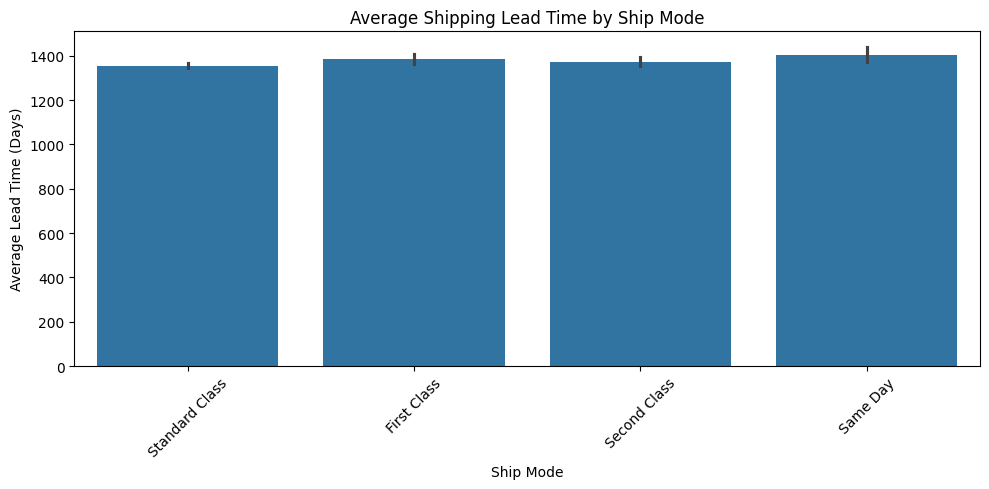

In [129]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Ship Mode",
    y="Lead_Time_Days",
    estimator="mean"
)

plt.title("Average Shipping Lead Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Lead Time (Days)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

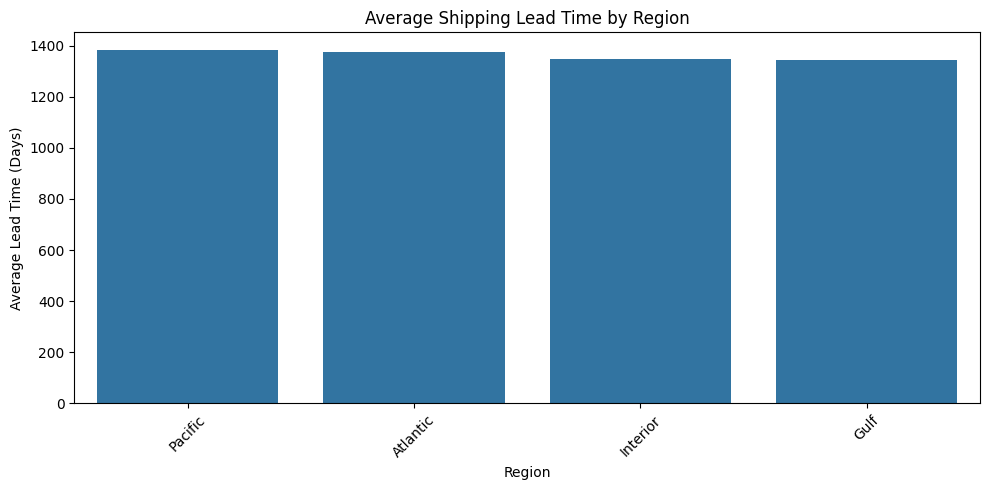

In [130]:
plt.figure(figsize=(10, 5))

region_chart = (
    df.groupby("Region")["Lead_Time_Days"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=region_chart.index,
    y=region_chart.values
)

plt.title("Average Shipping Lead Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Lead Time (Days)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

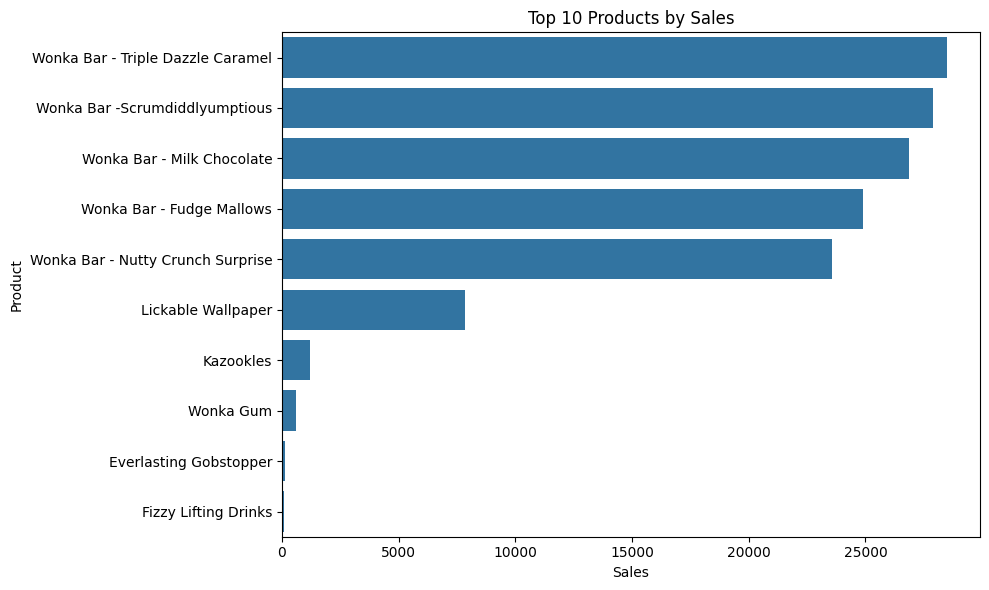

In [131]:
top_sales = sales_by_product.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_sales.values,
    y=top_sales.index
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

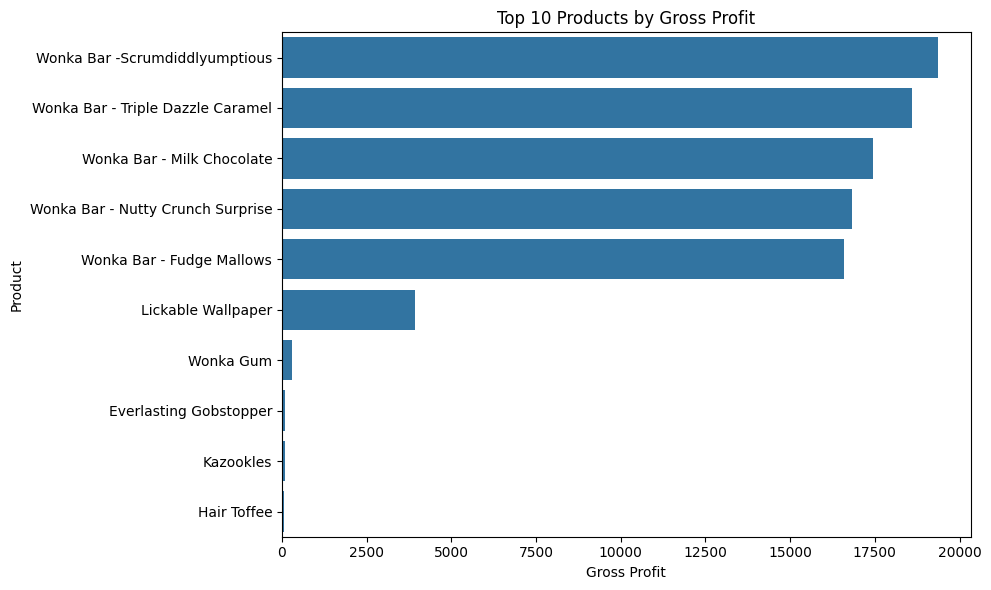

In [132]:
top_profit = profit_by_product.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_profit.values,
    y=top_profit.index
)

plt.title("Top 10 Products by Gross Profit")
plt.xlabel("Gross Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [133]:
factory_data = {
    "Factory": [
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory"
    ],
    "Latitude": [
        32.881893,
        32.076176,
        48.119140,
        41.446333,
        35.117500
    ],
    "Longitude": [
        -111.768036,
        -81.088371,
        -96.181150,
        -90.565487,
        -89.971107
    ]
}

factory_df = pd.DataFrame(factory_data)

factory_df

,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


In [134]:
product_factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

In [135]:
# Find unique products in the dataset
csv_products = set(df["Product Name"].dropna().unique())

# Find products that do not have a mapping
unmatched_products = sorted(
    csv_products - set(product_factory_mapping.keys())
)

print("Number of unique products:", len(csv_products))
print("Unmatched products:", len(unmatched_products))

for product in unmatched_products:
    print(product)

Number of unique products: 15
Unmatched products: 0


In [136]:
df["Current_Factory"] = df["Product Name"].map(
    product_factory_mapping
)

print(
    "Rows without a factory:",
    df["Current_Factory"].isna().sum()
)

Rows without a factory: 0


In [137]:
print("Columns available in the dataset:")

for column in df.columns:
    print(column)

Columns available in the dataset:
Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Country/Region
City
State/Province
Postal Code
Division
Region
Product ID
Product Name
Sales
Units
Gross Profit
Cost
Lead_Time_Days
Order_Year
Order_Month
Order_Quarter
Order_Day_of_Week
Sales_per_Unit
Profit_Margin
Cost_per_Unit
Current_Factory


In [138]:
# Display every unique product name in the actual CSV

products = sorted(df["Product Name"].unique())

print("Number of unique products:", len(products))

for product in products:
    print(product)

Number of unique products: 15
Everlasting Gobstopper
Fizzy Lifting Drinks
Fun Dip
Hair Toffee
Kazookles
Laffy Taffy
Lickable Wallpaper
Nerds
SweeTARTS
Wonka Bar - Fudge Mallows
Wonka Bar - Milk Chocolate
Wonka Bar - Nutty Crunch Surprise
Wonka Bar - Triple Dazzle Caramel
Wonka Bar -Scrumdiddlyumptious
Wonka Gum


In [139]:
# Official product-to-factory mapping from the project requirements

product_factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",

    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",

    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",

    "Everlasting Gobstopper": "Secret Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",

    "Hair Toffee": "The Other Factory",
    "Kazookles": "The Other Factory"
}

print("Factory mapping created successfully!")
print("Products in mapping:", len(product_factory_mapping))

Factory mapping created successfully!
Products in mapping: 15


In [140]:
# Compare CSV products with the official project mapping

csv_products = set(df["Product Name"].unique())
mapped_products = set(product_factory_mapping.keys())

unmatched_csv_products = csv_products - mapped_products
extra_mapping_products = mapped_products - csv_products

print("Products in CSV:", len(csv_products))
print("Products in mapping:", len(mapped_products))

print("\nProducts in CSV but NOT in mapping:")
print(unmatched_csv_products)

print("\nProducts in mapping but NOT in CSV:")
print(extra_mapping_products)

Products in CSV: 15
Products in mapping: 15

Products in CSV but NOT in mapping:
set()

Products in mapping but NOT in CSV:
set()


In [141]:
# Assign the current factory to every transaction

df["Current_Factory"] = df["Product Name"].map(
    product_factory_mapping
)

print(
    "Rows without factory assignment:",
    df["Current_Factory"].isna().sum()
)

Rows without factory assignment: 0


In [142]:
# Assign the current factory to every transaction

df["Current_Factory"] = df["Product Name"].map(
    product_factory_mapping
)

print(
    "Rows without factory assignment:",
    df["Current_Factory"].isna().sum()
)

Rows without factory assignment: 0


In [143]:
factory_distribution = (
    df["Current_Factory"]
    .value_counts()
)

factory_distribution

,count
Current_Factory,
Lot's O' Nuts,5692
Wicked Choccy's,4152
Secret Factory,217
The Other Factory,100
Sugar Shack,33


In [144]:
product_factory_table = (
    df[["Product Name", "Current_Factory"]]
    .drop_duplicates()
    .sort_values(["Current_Factory", "Product Name"])
)

product_factory_table

,Product Name,Current_Factory
13,Wonka Bar - Fudge Mallows,Lot's O' Nuts
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4729,Everlasting Gobstopper,Secret Factory
136,Lickable Wallpaper,Secret Factory
19,Wonka Gum,Secret Factory
191,Fizzy Lifting Drinks,Sugar Shack
5007,Fun Dip,Sugar Shack
226,Laffy Taffy,Sugar Shack
1490,Nerds,Sugar Shack


In [145]:
factory_performance = (
    df.groupby("Current_Factory")
    .agg(
        Orders=("Order ID", "count"),
        Products=("Product Name", "nunique"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum"),
        Average_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
    .sort_values("Average_Lead_Time", ascending=False)
)

factory_performance

,Orders,Products,Total_Sales,Total_Profit,Average_Lead_Time,Median_Lead_Time
Current_Factory,,,,,,
Sugar Shack,33,5,220.98,121.23,1441.000000,1450.0
Secret Factory,217,3,8587.50,4344.70,1399.478723,1432.0
The Other Factory,100,2,1282.25,152.25,1383.500000,1376.5
Wicked Choccy's,4152,2,55352.75,36053.57,1364.938037,1363.0
Lot's O' Nuts,5692,3,76340.15,52771.05,1364.895983,1361.0


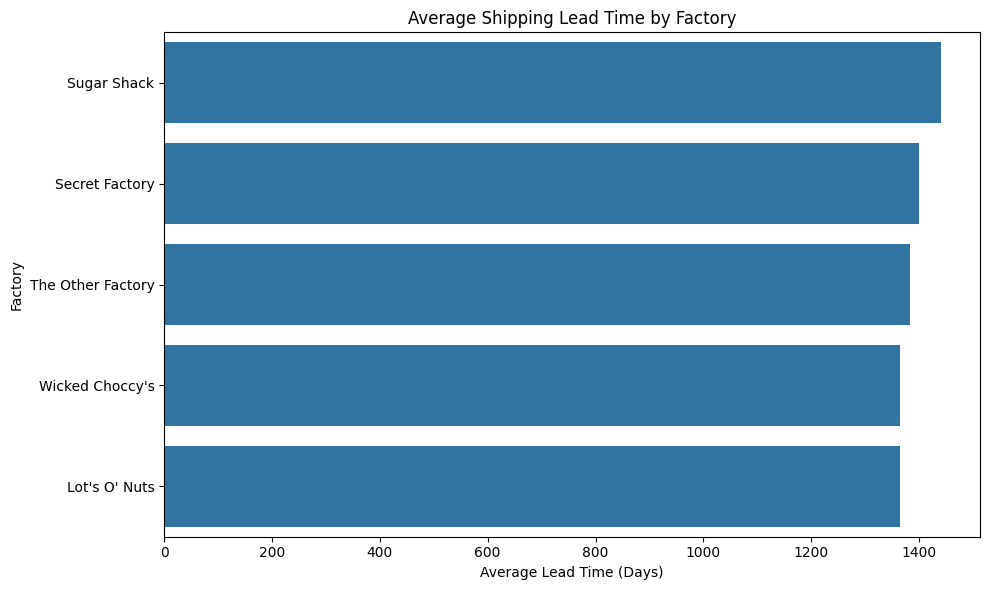

In [146]:
plt.figure(figsize=(10, 6))

factory_lead = (
    df.groupby("Current_Factory")["Lead_Time_Days"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=factory_lead.values,
    y=factory_lead.index
)

plt.title("Average Shipping Lead Time by Factory")
plt.xlabel("Average Lead Time (Days)")
plt.ylabel("Factory")

plt.tight_layout()
plt.show()

In [147]:
product_performance = (
    df.groupby(
        ["Product Name", "Current_Factory"]
    )
    .agg(
        Orders=("Order ID", "count"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum"),
        Average_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
    .sort_values(
        "Average_Lead_Time",
        ascending=False
    )
)

product_performance

,,Orders,Total_Sales,Total_Profit,Average_Lead_Time,Median_Lead_Time
Product Name,Current_Factory,,,,,
SweeTARTS,Sugar Shack,10,61.50,28.70,1592.000000,1597.0
Laffy Taffy,Sugar Shack,10,53.73,33.48,1545.500000,1545.5
Fizzy Lifting Drinks,Sugar Shack,6,78.75,47.25,1489.000000,1489.0
Lickable Wallpaper,Secret Factory,94,7860.00,3930.00,1448.514286,1520.0
Hair Toffee,The Other Factory,4,76.50,59.50,1425.500000,1425.5
Kazookles,The Other Factory,96,1205.75,92.75,1380.700000,1376.5
Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,2015,28485.00,18610.20,1380.000000,1391.5
Wonka Gum,Secret Factory,120,597.50,310.70,1371.789474,1333.0
Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,1810,23574.95,16819.95,1367.816845,1362.0


In [148]:
product_performance.head(10)

,,Orders,Total_Sales,Total_Profit,Average_Lead_Time,Median_Lead_Time
Product Name,Current_Factory,,,,,
SweeTARTS,Sugar Shack,10,61.50,28.70,1592.000000,1597.0
Laffy Taffy,Sugar Shack,10,53.73,33.48,1545.500000,1545.5
Fizzy Lifting Drinks,Sugar Shack,6,78.75,47.25,1489.000000,1489.0
Lickable Wallpaper,Secret Factory,94,7860.00,3930.00,1448.514286,1520.0
Hair Toffee,The Other Factory,4,76.50,59.50,1425.500000,1425.5
Kazookles,The Other Factory,96,1205.75,92.75,1380.700000,1376.5
Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,2015,28485.00,18610.20,1380.000000,1391.5
Wonka Gum,Secret Factory,120,597.50,310.70,1371.789474,1333.0
Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,1810,23574.95,16819.95,1367.816845,1362.0


In [149]:
product_performance.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

,,Orders,Total_Sales,Total_Profit,Average_Lead_Time,Median_Lead_Time
Product Name,Current_Factory,,,,,
Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,2064,27874.80,19357.50,1365.891705,1362.0
Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,2015,28485.00,18610.20,1380.000000,1391.5
Wonka Bar - Milk Chocolate,Wicked Choccy's,2137,26867.75,17443.37,1350.702864,1333.0
Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,1810,23574.95,16819.95,1367.816845,1362.0
Wonka Bar - Fudge Mallows,Lot's O' Nuts,1818,24890.40,16593.60,1360.825100,1334.0
Lickable Wallpaper,Secret Factory,94,7860.00,3930.00,1448.514286,1520.0
Wonka Gum,Secret Factory,120,597.50,310.70,1371.789474,1333.0
Everlasting Gobstopper,Secret Factory,3,130.00,104.00,1330.500000,1330.5
Kazookles,The Other Factory,96,1205.75,92.75,1380.700000,1376.5


In [150]:
# Define the features we want to use for prediction

feature_columns = [
    "Product Name",
    "Current_Factory",
    "Region",
    "Ship Mode",
    "Division",
    "Units",
    "Sales",
    "Order_Month",
    "Order_Quarter",
    "Order_Day_of_Week"
]

target_column = "Lead_Time_Days"

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Number of features:", len(feature_columns))
print("Number of observations:", len(X))

Number of features: 10
Number of observations: 10194


In [151]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nMissing values in X:")
print(X.isnull().sum().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Features:
['Product Name', 'Current_Factory', 'Region', 'Ship Mode', 'Division', 'Units', 'Sales', 'Order_Month', 'Order_Quarter', 'Order_Day_of_Week']

Target:
Lead_Time_Days

Missing values in X:
18192

Missing values in y:
6064


In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8155
Testing rows: 2039


In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8155
Testing rows: 2039


In [154]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Product Name",
    "Current_Factory",
    "Region",
    "Ship Mode",
    "Division"
]

numerical_features = [
    "Units",
    "Sales",
    "Order_Month",
    "Order_Quarter",
    "Order_Day_of_Week"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [155]:
# Check exactly which ML features contain missing values

print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

print("\nTotal missing values in X_train:",
      X_train.isnull().sum().sum())

print("Total missing values in X_test:",
      X_test.isnull().sum().sum())

Missing values in X_train:
Product Name            0
Current_Factory         0
Region                  0
Ship Mode               0
Division                0
Units                   0
Sales                   0
Order_Month          4864
Order_Quarter        4864
Order_Day_of_Week    4864
dtype: int64

Missing values in X_test:
Product Name            0
Current_Factory         0
Region                  0
Ship Mode               0
Division                0
Units                   0
Sales                   0
Order_Month          1200
Order_Quarter        1200
Order_Day_of_Week    1200
dtype: int64

Total missing values in X_train: 14592
Total missing values in X_test: 3600


In [156]:
print("Missing values in y_train:",
      y_train.isnull().sum())

print("Missing values in y_test:",
      y_test.isnull().sum())

Missing values in y_train: 4864
Missing values in y_test: 1200


In [157]:
  print("Missing values in important columns:")

check_columns = [
    "Order Date",
    "Ship Date",
    "Lead_Time_Days",
    "Product Name",
    "Region",
    "Ship Mode",
    "Division",
    "Units",
    "Sales"
]

print(df[check_columns].isnull().sum())

Missing values in important columns:
Order Date        6064
Ship Date            0
Lead_Time_Days    6064
Product Name         0
Region               0
Ship Mode            0
Division             0
Units                0
Sales                0
dtype: int64


In [158]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    errors="coerce"
)

In [159]:
# Reload the original dataset so we can restore the original Order Date values

df = pd.read_csv("Nassau Candy Distributor.csv")

print("Dataset reloaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset reloaded successfully!
Rows: 10194
Columns: 18


In [160]:
# Display examples of the original date values

print("Sample Order Dates:")
print(df["Order Date"].head(10))

print("\nSample Ship Dates:")
print(df["Ship Date"].head(10))

Sample Order Dates:
0    03-01-2024
1    04-01-2024
2    04-01-2024
3    04-01-2024
4    05-01-2024
5    06-01-2024
6    06-01-2024
7    06-01-2024
8    06-01-2024
9    06-01-2024
Name: Order Date, dtype: object

Sample Ship Dates:
0    30-06-2026
1    01-07-2026
2    01-07-2026
3    01-07-2026
4    05-07-2026
5    03-07-2026
6    03-07-2026
7    30-06-2026
8    03-07-2026
9    03-07-2026
Name: Ship Date, dtype: object


In [161]:
# Show the most common Order Date formats/values

print("First 20 Order Date values:")
print(df["Order Date"].head(20).tolist())

First 20 Order Date values:
['03-01-2024', '04-01-2024', '04-01-2024', '04-01-2024', '05-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '06-01-2024', '07-01-2024', '07-01-2024', '09-01-2024', '09-01-2024', '10-01-2024', '10-01-2024']


In [162]:
# Convert dates using the actual DD-MM-YYYY format in our CSV

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Date conversion completed!")
print("Missing Order Dates:", df["Order Date"].isna().sum())
print("Missing Ship Dates:", df["Ship Date"].isna().sum())

Date conversion completed!
Missing Order Dates: 0
Missing Ship Dates: 0


In [163]:
# Calculate shipping lead time in days

df["Lead_Time_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("Lead time calculated successfully!")
print("Missing Lead Times:", df["Lead_Time_Days"].isna().sum())

Lead time calculated successfully!
Missing Lead Times: 0


In [164]:
print("Lead Time Summary:")
print(df["Lead_Time_Days"].describe())

print("\nNegative lead times:",
      (df["Lead_Time_Days"] < 0).sum())

print("Zero-day lead times:",
      (df["Lead_Time_Days"] == 0).sum())

Lead Time Summary:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time_Days, dtype: float64

Negative lead times: 0
Zero-day lead times: 0


In [165]:
# Create calendar features from the corrected Order Date

df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Quarter"] = df["Order Date"].dt.quarter
df["Order_Day_of_Week"] = df["Order Date"].dt.dayofweek

print("Date features recreated successfully!")

Date features recreated successfully!


In [166]:
# Create financial features

df["Profit_Margin"] = (
    df["Gross Profit"] /
    df["Sales"].replace(0, np.nan)
)

df["Sales_per_Unit"] = (
    df["Sales"] /
    df["Units"].replace(0, np.nan)
)

df["Cost_per_Unit"] = (
    df["Cost"] /
    df["Units"].replace(0, np.nan)
)

print("Financial features recreated successfully!")

Financial features recreated successfully!


In [167]:
# Reapply the product-to-factory mapping

df["Current_Factory"] = df["Product Name"].map(
    product_factory_mapping
)

print(
    "Rows without factory assignment:",
    df["Current_Factory"].isna().sum()
)

Rows without factory assignment: 0


In [168]:
print("Final dataset shape:", df.shape)

print("\nMissing values in important ML columns:")

ml_check_columns = [
    "Product Name",
    "Current_Factory",
    "Region",
    "Ship Mode",
    "Division",
    "Units",
    "Sales",
    "Order_Month",
    "Order_Quarter",
    "Order_Day_of_Week",
    "Lead_Time_Days"
]

print(df[ml_check_columns].isnull().sum())

Final dataset shape: (10194, 27)

Missing values in important ML columns:
Product Name         0
Current_Factory      0
Region               0
Ship Mode            0
Division             0
Units                0
Sales                0
Order_Month          0
Order_Quarter        0
Order_Day_of_Week    0
Lead_Time_Days       0
dtype: int64


In [169]:
# Define machine-learning features again

feature_columns = [
    "Product Name",
    "Current_Factory",
    "Region",
    "Ship Mode",
    "Division",
    "Units",
    "Sales",
    "Order_Month",
    "Order_Quarter",
    "Order_Day_of_Week"
]

target_column = "Lead_Time_Days"

X = df[feature_columns].copy()
y = df[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:",
      X.isnull().sum().sum())

print("Missing values in y:",
      y.isnull().sum())

X shape: (10194, 10)
y shape: (10194,)

Missing values in X: 0
Missing values in y: 0


In [170]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8155
Testing rows: 2039


In [171]:
print("Missing values in X_train:",
      X_train.isnull().sum().sum())

print("Missing values in X_test:",
      X_test.isnull().sum().sum())

print("Missing values in y_train:",
      y_train.isnull().sum())

print("Missing values in y_test:",
      y_test.isnull().sum())

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


In [172]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Product Name",
    "Current_Factory",
    "Region",
    "Ship Mode",
    "Division"
]

numerical_features = [
    "Units",
    "Sales",
    "Order_Month",
    "Order_Quarter",
    "Order_Day_of_Week"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor rebuilt successfully!")

Preprocessor rebuilt successfully!


In [173]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [174]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Create the Random Forest model
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [175]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

# Create the Gradient Boosting model
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

# Train the model
gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [176]:
print("Linear Regression:", type(linear_model.named_steps["model"]).__name__)
print("Random Forest:", type(random_forest_model.named_steps["model"]).__name__)
print("Gradient Boosting:", type(gradient_boosting_model.named_steps["model"]).__name__)

Linear Regression: LinearRegression
Random Forest: RandomForestRegressor
Gradient Boosting: GradientBoostingRegressor


In [177]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import math

# Store all trained models
models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

results = []

# Evaluate each model
for name, model in models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = math.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# Create results table
model_results = pd.DataFrame(results)

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,212.673344,264.272469,0.012454
1,Random Forest,218.277465,269.504716,-0.027037
2,Gradient Boosting,214.614797,260.271796,0.042127


In [178]:
# Clean model comparison table

model_comparison = model_results.copy()

model_comparison["MAE"] = model_comparison["MAE"].round(2)
model_comparison["RMSE"] = model_comparison["RMSE"].round(2)
model_comparison["R2"] = model_comparison["R2"].round(4)

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,212.67,264.27,0.0125
1,Random Forest,218.28,269.50,-0.0270
2,Gradient Boosting,214.61,260.27,0.0421


In [179]:
# Generate predictions from all three models

linear_predictions = linear_model.predict(X_test)

random_forest_predictions = random_forest_model.predict(X_test)

gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


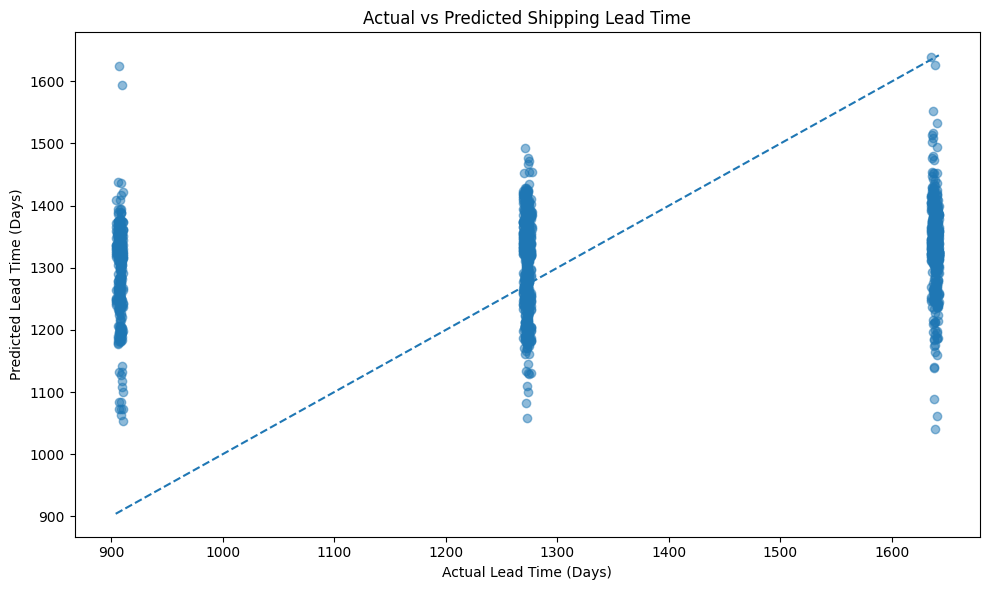

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    gradient_boosting_predictions,
    alpha=0.5
)

# Reference line
min_value = min(
    y_test.min(),
    gradient_boosting_predictions.min()
)

max_value = max(
    y_test.max(),
    gradient_boosting_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Shipping Lead Time")
plt.xlabel("Actual Lead Time (Days)")
plt.ylabel("Predicted Lead Time (Days)")

plt.tight_layout()
plt.show()

In [181]:
# Calculate prediction errors

prediction_errors = (
    y_test - gradient_boosting_predictions
)

print("Mean prediction error:",
      round(prediction_errors.mean(), 2))

print("Mean absolute error:",
      round(
          prediction_errors.abs().mean(),
          2
      ))

Mean prediction error: -1.86
Mean absolute error: 214.61


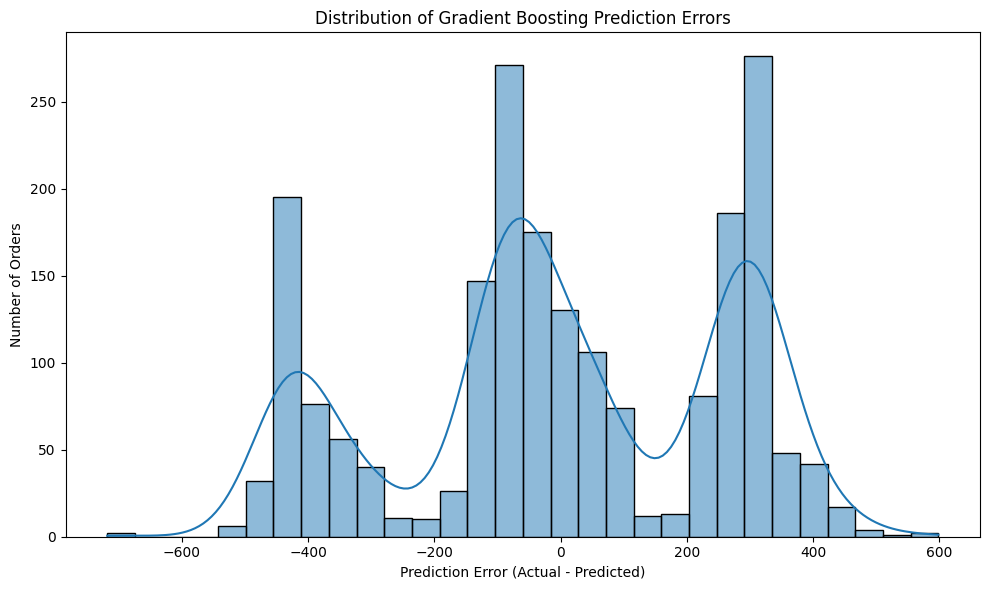

In [182]:
plt.figure(figsize=(10, 6))

sns.histplot(
    prediction_errors,
    bins=30,
    kde=True
)

plt.title("Distribution of Gradient Boosting Prediction Errors")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [183]:
# Correlation between numerical variables and shipping lead time

correlation_columns = [
    "Lead_Time_Days",
    "Units",
    "Sales",
    "Order_Month",
    "Order_Quarter",
    "Order_Day_of_Week"
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix["Lead_Time_Days"].sort_values(
    ascending=False
)

,Lead_Time_Days
Lead_Time_Days,1.000000
Sales,-0.005438
Units,-0.006702
Order_Quarter,-0.015441
Order_Month,-0.015695
Order_Day_of_Week,-0.132765


In [184]:
ship_mode_analysis = (
    df.groupby("Ship Mode")
    .agg(
        Orders=("Order ID", "count"),
        Average_Lead_Time=("Lead_Time_Days", "mean"),
        Std_Lead_Time=("Lead_Time_Days", "std"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
    .sort_values(
        "Average_Lead_Time",
        ascending=False
    )
)

ship_mode_analysis

,Orders,Average_Lead_Time,Std_Lead_Time,Median_Lead_Time
Ship Mode,,,,
First Class,1548,1338.275840,265.632140,1272.0
Same Day,547,1333.442413,253.813374,1269.0
Second Class,1979,1323.845376,261.813569,1273.0
Standard Class,6120,1314.334641,262.400116,1274.0


In [185]:
product_lead_analysis = (
    df.groupby("Product Name")
    .agg(
        Orders=("Order ID", "count"),
        Average_Lead_Time=("Lead_Time_Days", "mean"),
        Std_Lead_Time=("Lead_Time_Days", "std"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum")
    )
    .sort_values(
        "Average_Lead_Time",
        ascending=False
    )
)

product_lead_analysis

,Orders,Average_Lead_Time,Std_Lead_Time,Total_Sales,Total_Profit
Product Name,,,,,
Hair Toffee,4,1455.250000,209.876750,76.50,59.50
Everlasting Gobstopper,3,1394.666667,213.336198,130.00,104.00
SweeTARTS,10,1383.500000,246.688850,61.50,28.70
Laffy Taffy,10,1383.100000,246.563695,53.73,33.48
Lickable Wallpaper,94,1339.138298,288.459855,7860.00,3930.00
Wonka Bar - Nutty Crunch Surprise,1810,1328.915470,260.837398,23574.95,16819.95
Wonka Bar - Triple Dazzle Caramel,2015,1325.661042,260.524339,28485.00,18610.20
Wonka Bar -Scrumdiddlyumptious,2064,1320.641957,260.121265,27874.80,19357.50
Wonka Bar - Milk Chocolate,2137,1316.764623,263.692704,26867.75,17443.37


In [186]:
factory_lead_analysis = (
    df.groupby("Current_Factory")
    .agg(
        Orders=("Order ID", "count"),
        Average_Lead_Time=("Lead_Time_Days", "mean"),
        Std_Lead_Time=("Lead_Time_Days", "std"),
        Median_Lead_Time=("Lead_Time_Days", "median")
    )
    .sort_values(
        "Average_Lead_Time",
        ascending=False
    )
)

factory_lead_analysis

,Orders,Average_Lead_Time,Std_Lead_Time,Median_Lead_Time
Current_Factory,,,,
Sugar Shack,33,1340.030303,265.630557,1274.0
Secret Factory,217,1321.870968,289.077927,1274.0
Lot's O' Nuts,5692,1321.228742,261.646319,1274.0
Wicked Choccy's,4152,1321.082129,262.166011,1274.0
The Other Factory,100,1280.280000,259.737633,1273.0


In [187]:
# Get feature names after one-hot encoding

trained_preprocessor = (
    gradient_boosting_model
    .named_steps["preprocessor"]
)

feature_names = (
    trained_preprocessor
    .get_feature_names_out()
)

# Get model feature importance
importances = (
    gradient_boosting_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
35,numerical__Order_Day_of_Week,0.619667
33,numerical__Order_Month,0.127032
32,numerical__Sales,0.054333
20,categorical__Region_Atlantic,0.035605
31,numerical__Units,0.026433
24,categorical__Ship Mode_First Class,0.021027
21,categorical__Region_Gulf,0.017838
34,numerical__Order_Quarter,0.015097
27,categorical__Ship Mode_Standard Class,0.013629
23,categorical__Region_Pacific,0.013598


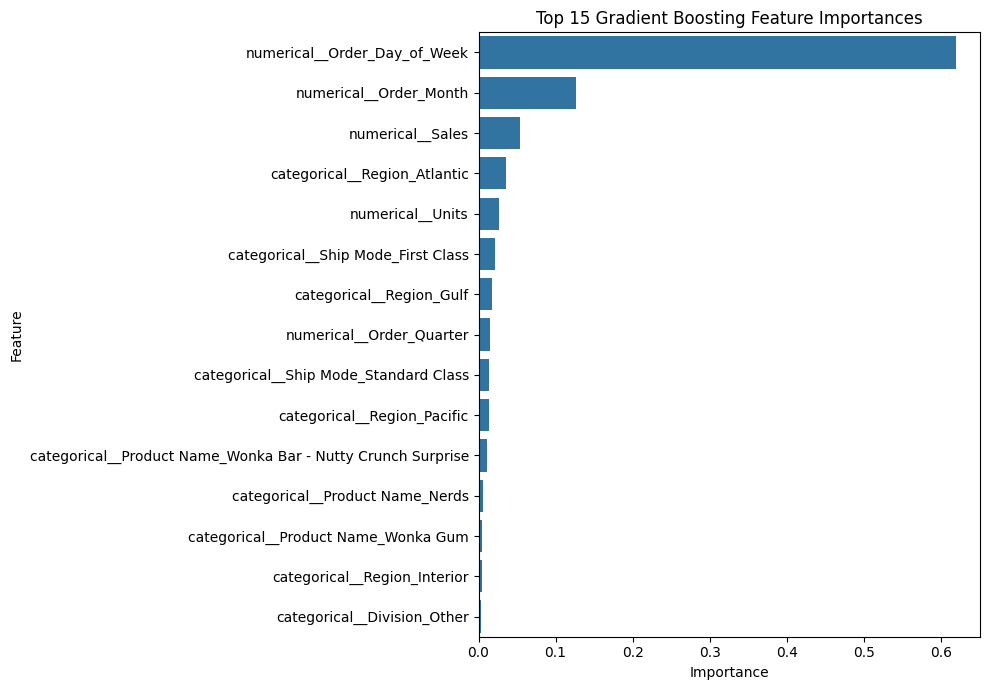

In [188]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Gradient Boosting Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [189]:
# Display our five factories

print("Factories available for scenario analysis:\n")

for factory in factory_df["Factory"]:
    print("-", factory)

Factories available for scenario analysis:

- Lot's O' Nuts
- Wicked Choccy's
- Sugar Shack
- Secret Factory
- The Other Factory


In [190]:
# Create a convenient dictionary for factory coordinates

factory_coordinates = {}

for _, row in factory_df.iterrows():
    factory_coordinates[row["Factory"]] = (
        row["Latitude"],
        row["Longitude"]
    )

factory_coordinates

{"Lot's O' Nuts": (32.881893, -111.768036),
 "Wicked Choccy's": (32.076176, -81.088371),
 'Sugar Shack': (48.11914, -96.18115),
 'Secret Factory': (41.446333, -90.565487),
 'The Other Factory': (35.1175, -89.971107)}

In [191]:
# Show the current product-to-factory assignment

current_assignments = (
    df[["Product Name", "Current_Factory"]]
    .drop_duplicates()
    .sort_values("Product Name")
)

current_assignments

,Product Name,Current_Factory
4729,Everlasting Gobstopper,Secret Factory
191,Fizzy Lifting Drinks,Sugar Shack
5007,Fun Dip,Sugar Shack
4435,Hair Toffee,The Other Factory
26,Kazookles,The Other Factory
226,Laffy Taffy,Sugar Shack
136,Lickable Wallpaper,Secret Factory
1490,Nerds,Sugar Shack
973,SweeTARTS,Sugar Shack
13,Wonka Bar - Fudge Mallows,Lot's O' Nuts


In [192]:
import math

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate approximate distance between two
    latitude/longitude points in kilometers.
    """

    R = 6371  # Earth's radius in kilometers

    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.atan2(
        math.sqrt(a),
        math.sqrt(1 - a)
    )

    return R * c

In [193]:
# Test distance calculation between the first two factories

factory_1 = factory_df.iloc[0]
factory_2 = factory_df.iloc[1]

distance = haversine_distance(
    factory_1["Latitude"],
    factory_1["Longitude"],
    factory_2["Latitude"],
    factory_2["Longitude"]
)

print(
    f"Distance between {factory_1['Factory']} "
    f"and {factory_2['Factory']}: "
    f"{distance:.2f} km"
)

Distance between Lot's O' Nuts and Wicked Choccy's: 2869.07 km


In [194]:
# Calculate distance between every pair of factories

factory_distances = []

for _, factory_a in factory_df.iterrows():

    for _, factory_b in factory_df.iterrows():

        if factory_a["Factory"] != factory_b["Factory"]:

            distance = haversine_distance(
                factory_a["Latitude"],
                factory_a["Longitude"],
                factory_b["Latitude"],
                factory_b["Longitude"]
            )

            factory_distances.append({
                "From_Factory": factory_a["Factory"],
                "To_Factory": factory_b["Factory"],
                "Distance_km": distance
            })

factory_distance_df = pd.DataFrame(factory_distances)

factory_distance_df.head(20)

,From_Factory,To_Factory,Distance_km
0,Lot's O' Nuts,Wicked Choccy's,2869.072753
1,Lot's O' Nuts,Sugar Shack,2137.812671
2,Lot's O' Nuts,Secret Factory,2098.588792
3,Lot's O' Nuts,The Other Factory,2020.574896
4,Wicked Choccy's,Lot's O' Nuts,2869.072753
5,Wicked Choccy's,Sugar Shack,2189.186842
6,Wicked Choccy's,Secret Factory,1339.213437
7,Wicked Choccy's,The Other Factory,889.070924
8,Sugar Shack,Lot's O' Nuts,2137.812671
9,Sugar Shack,Wicked Choccy's,2189.186842


In [195]:
# Create an easy-to-read distance matrix

factory_distance_matrix = factory_distance_df.pivot(
    index="From_Factory",
    columns="To_Factory",
    values="Distance_km"
)

factory_distance_matrix.round(0)

To_Factory,Lot's O' Nuts,Secret Factory,Sugar Shack,The Other Factory,Wicked Choccy's
From_Factory,,,,,
Lot's O' Nuts,NaN,2099.0,2138.0,2021.0,2869.0
Secret Factory,2099.0,NaN,864.0,706.0,1339.0
Sugar Shack,2138.0,864.0,NaN,1534.0,2189.0
The Other Factory,2021.0,706.0,1534.0,NaN,889.0
Wicked Choccy's,2869.0,1339.0,2189.0,889.0,NaN


In [196]:
# Calculate historical baseline performance for each product

product_baseline = (
    df.groupby(
        ["Product Name", "Current_Factory"]
    )
    .agg(
        Orders=("Order ID", "count"),
        Average_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum"),
        Average_Sales=("Sales", "mean"),
        Average_Profit=("Gross Profit", "mean")
    )
    .reset_index()
)

product_baseline

,Product Name,Current_Factory,Orders,Average_Lead_Time,Median_Lead_Time,Total_Sales,Total_Profit,Average_Sales,Average_Profit
0,Everlasting Gobstopper,Secret Factory,3,1394.666667,1273.0,130.00,104.00,43.333333,34.666667
1,Fizzy Lifting Drinks,Sugar Shack,6,1273.500000,1274.0,78.75,47.25,13.125000,7.875000
2,Fun Dip,Sugar Shack,3,1272.666667,1272.0,12.00,4.80,4.000000,1.600000
3,Hair Toffee,The Other Factory,4,1455.250000,1455.0,76.50,59.50,19.125000,14.875000
4,Kazookles,The Other Factory,96,1272.989583,1273.0,1205.75,92.75,12.559896,0.966146
5,Laffy Taffy,Sugar Shack,10,1383.100000,1275.0,53.73,33.48,5.373000,3.348000
6,Lickable Wallpaper,Secret Factory,94,1339.138298,1274.0,7860.00,3930.00,83.617021,41.808511
7,Nerds,Sugar Shack,4,1274.000000,1274.0,15.00,7.00,3.750000,1.750000
8,SweeTARTS,Sugar Shack,10,1383.500000,1274.0,61.50,28.70,6.150000,2.870000
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,1818,1314.242024,1274.0,24890.40,16593.60,13.691089,9.127393


In [197]:
# Calculate average financial values per order

product_baseline["Profit_Margin"] = (
    product_baseline["Average_Profit"]
    / product_baseline["Average_Sales"]
).replace(
    [np.inf, -np.inf],
    np.nan
)

product_baseline[
    [
        "Product Name",
        "Current_Factory",
        "Average_Sales",
        "Average_Profit",
        "Profit_Margin"
    ]
]

,Product Name,Current_Factory,Average_Sales,Average_Profit,Profit_Margin
0,Everlasting Gobstopper,Secret Factory,43.333333,34.666667,0.800000
1,Fizzy Lifting Drinks,Sugar Shack,13.125000,7.875000,0.600000
2,Fun Dip,Sugar Shack,4.000000,1.600000,0.400000
3,Hair Toffee,The Other Factory,19.125000,14.875000,0.777778
4,Kazookles,The Other Factory,12.559896,0.966146,0.076923
5,Laffy Taffy,Sugar Shack,5.373000,3.348000,0.623116
6,Lickable Wallpaper,Secret Factory,83.617021,41.808511,0.500000
7,Nerds,Sugar Shack,3.750000,1.750000,0.466667
8,SweeTARTS,Sugar Shack,6.150000,2.870000,0.466667
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,13.691089,9.127393,0.666667


In [198]:
# Generate all possible product-to-factory scenarios

scenario_rows = []

all_factories = factory_df["Factory"].tolist()

for _, row in product_baseline.iterrows():

    product = row["Product Name"]
    current_factory = row["Current_Factory"]

    for alternative_factory in all_factories:

        # Skip the current assignment
        if alternative_factory == current_factory:
            continue

        scenario_rows.append({
            "Product Name": product,
            "Current_Factory": current_factory,
            "Alternative_Factory": alternative_factory,
            "Current_Average_Lead_Time": row["Average_Lead_Time"],
            "Average_Sales": row["Average_Sales"],
            "Average_Profit": row["Average_Profit"],
            "Orders": row["Orders"]
        })

scenario_df = pd.DataFrame(scenario_rows)

print("Number of scenarios:", len(scenario_df))

Number of scenarios: 60


In [199]:
# Add distance between current and alternative factories

scenario_df = scenario_df.merge(
    factory_distance_df,
    left_on=[
        "Current_Factory",
        "Alternative_Factory"
    ],
    right_on=[
        "From_Factory",
        "To_Factory"
    ],
    how="left"
)

scenario_df.drop(
    columns=["From_Factory", "To_Factory"],
    inplace=True
)

scenario_df.head()

,Product Name,Current_Factory,Alternative_Factory,Current_Average_Lead_Time,Average_Sales,Average_Profit,Orders,Distance_km
0,Everlasting Gobstopper,Secret Factory,Lot's O' Nuts,1394.666667,43.333333,34.666667,3,2098.588792
1,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,1394.666667,43.333333,34.666667,3,1339.213437
2,Everlasting Gobstopper,Secret Factory,Sugar Shack,1394.666667,43.333333,34.666667,3,863.723221
3,Everlasting Gobstopper,Secret Factory,The Other Factory,1394.666667,43.333333,34.666667,3,705.638309
4,Fizzy Lifting Drinks,Sugar Shack,Lot's O' Nuts,1273.500000,13.125000,7.875000,6,2137.812671


In [200]:
def predict_scenario_lead_time(
    product,
    alternative_factory,
    region,
    ship_mode,
    division,
    units,
    sales,
    order_month,
    order_quarter,
    order_day_of_week
):
    """
    Predict lead time for a product under
    an alternative factory assignment.
    """

    scenario_input = pd.DataFrame({
        "Product Name": [product],
        "Current_Factory": [alternative_factory],
        "Region": [region],
        "Ship Mode": [ship_mode],
        "Division": [division],
        "Units": [units],
        "Sales": [sales],
        "Order_Month": [order_month],
        "Order_Quarter": [order_quarter],
        "Order_Day_of_Week": [order_day_of_week]
    })

    prediction = gradient_boosting_model.predict(
        scenario_input
    )[0]

    return prediction

In [201]:
# Select the historical columns needed for simulation

scenario_base = df[
    [
        "Order ID",
        "Product Name",
        "Current_Factory",
        "Region",
        "Ship Mode",
        "Division",
        "Units",
        "Sales",
        "Gross Profit",
        "Order_Month",
        "Order_Quarter",
        "Order_Day_of_Week",
        "Lead_Time_Days"
    ]
].copy()

print("Scenario base rows:", len(scenario_base))

Scenario base rows: 10194


In [202]:
# Test one transaction under one alternative factory

test_row = scenario_base.iloc[0]

current_factory = test_row["Current_Factory"]

alternative_factories = [
    f for f in all_factories
    if f != current_factory
]

alternative_factory = alternative_factories[0]

test_input = pd.DataFrame({
    "Product Name": [test_row["Product Name"]],
    "Current_Factory": [alternative_factory],
    "Region": [test_row["Region"]],
    "Ship Mode": [test_row["Ship Mode"]],
    "Division": [test_row["Division"]],
    "Units": [test_row["Units"]],
    "Sales": [test_row["Sales"]],
    "Order_Month": [test_row["Order_Month"]],
    "Order_Quarter": [test_row["Order_Quarter"]],
    "Order_Day_of_Week": [test_row["Order_Day_of_Week"]]
})

test_prediction = gradient_boosting_model.predict(
    test_input
)[0]

print("Product:", test_row["Product Name"])
print("Current Factory:", current_factory)
print("Alternative Factory:", alternative_factory)
print("Actual Lead Time:", test_row["Lead_Time_Days"])
print("Predicted Alternative Lead Time:", round(test_prediction, 2))

Product: Wonka Bar - Milk Chocolate
Current Factory: Wicked Choccy's
Alternative Factory: Lot's O' Nuts
Actual Lead Time: 909
Predicted Alternative Lead Time: 1441.47


In [203]:
print("Order Date range:")
print("Earliest:", df["Order Date"].min())
print("Latest:", df["Order Date"].max())

print("\nShip Date range:")
print("Earliest:", df["Ship Date"].min())
print("Latest:", df["Ship Date"].max())

print("\nLead Time range:")
print("Minimum:", df["Lead_Time_Days"].min())
print("Maximum:", df["Lead_Time_Days"].max())

Order Date range:
Earliest: 2024-01-02 00:00:00
Latest: 2025-12-31 00:00:00

Ship Date range:
Earliest: 2026-06-30 00:00:00
Latest: 2030-06-28 00:00:00

Lead Time range:
Minimum: 904
Maximum: 1642


In [204]:
# Find orders with unusually large lead times

long_shipments = (
    df[
        df["Lead_Time_Days"] > 100
    ][
        [
            "Order ID",
            "Order Date",
            "Ship Date",
            "Product Name",
            "Current_Factory",
            "Region",
            "Ship Mode",
            "Lead_Time_Days"
        ]
    ]
    .sort_values(
        "Lead_Time_Days",
        ascending=False
    )
)

print("Orders with lead time > 100 days:",
      len(long_shipments))

long_shipments.head(20)

Orders with lead time > 100 days: 10194


,Order ID,Order Date,Ship Date,Product Name,Current_Factory,Region,Ship Mode,Lead_Time_Days
10183,CA-2024-146626-CHO-SCR-58000,2025-12-29,2030-06-28,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Atlantic,Standard Class,1642
10175,US-2024-146626-CHO-SCR-58000,2025-12-29,2030-06-28,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Pacific,Standard Class,1642
7167,US-2024-105851-CHO-NUT-13000,2025-03-13,2029-09-10,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Pacific,Standard Class,1642
9540,US-2024-139969-CHO-MIL-31000,2025-11-19,2030-05-19,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,1642
10165,US-2024-164826-CHO-TRI-54000,2025-12-28,2030-06-27,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,1642
10164,US-2024-164826-CHO-FUD-51000,2025-12-28,2030-06-27,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Atlantic,Standard Class,1642
10160,US-2024-164826-CHO-SCR-58000,2025-12-28,2030-06-27,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Atlantic,Standard Class,1642
8087,US-2024-108560-CHO-SCR-58000,2025-07-08,2030-01-05,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Pacific,Standard Class,1642
10120,US-2024-147956-CHO-SCR-58000,2025-12-24,2030-06-23,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Pacific,Standard Class,1642
10111,US-2024-128734-CHO-MIL-31000,2025-12-24,2030-06-23,Wonka Bar - Milk Chocolate,Wicked Choccy's,Pacific,Standard Class,1642


In [205]:
lead_time_percentiles = df["Lead_Time_Days"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
)

lead_time_percentiles

,Lead_Time_Days
0.50,1274.0
0.75,1638.0
0.90,1640.0
0.95,1641.0
0.99,1642.0
1.00,1642.0


In [206]:
print("Order Date range:")
print("Earliest:", df["Order Date"].min())
print("Latest:", df["Order Date"].max())

print("\nShip Date range:")
print("Earliest:", df["Ship Date"].min())
print("Latest:", df["Ship Date"].max())

Order Date range:
Earliest: 2024-01-02 00:00:00
Latest: 2025-12-31 00:00:00

Ship Date range:
Earliest: 2026-06-30 00:00:00
Latest: 2030-06-28 00:00:00


In [207]:
df[
    [
        "Order ID",
        "Order Date",
        "Ship Date",
        "Product Name",
        "Ship Mode",
        "Lead_Time_Days"
    ]
].sort_values("Order Date").head(10)

,Order ID,Order Date,Ship Date,Product Name,Ship Mode,Lead_Time_Days
2057,US-2022-146262-CHO-MIL-31000,2024-01-02,2027-07-02,Wonka Bar - Milk Chocolate,Standard Class,1277
2058,US-2022-146262-CHO-TRI-54000,2024-01-02,2027-07-02,Wonka Bar - Triple Dazzle Caramel,Standard Class,1277
2056,US-2022-146262-CHO-NUT-13000,2024-01-02,2027-07-02,Wonka Bar - Nutty Crunch Surprise,Standard Class,1277
2055,US-2022-104514-CHO-MIL-31000,2024-01-02,2027-06-27,Wonka Bar - Milk Chocolate,Second Class,1272
2054,US-2022-104514-CHO-SCR-58000,2024-01-02,2027-06-27,Wonka Bar -Scrumdiddlyumptious,Second Class,1272
2053,US-2022-146262-CHO-FUD-51000,2024-01-02,2027-07-02,Wonka Bar - Fudge Mallows,Standard Class,1277
2052,US-2022-104514-CHO-MIL-31000,2024-01-02,2027-06-27,Wonka Bar - Milk Chocolate,Second Class,1272
2051,US-2022-146262-CHO-NUT-13000,2024-01-02,2027-07-02,Wonka Bar - Nutty Crunch Surprise,Standard Class,1277
2062,US-2022-141243-CHO-NUT-13000,2024-01-03,2027-07-01,Wonka Bar - Nutty Crunch Surprise,Second Class,1275
2061,US-2022-121097-CHO-MIL-31000,2024-01-03,2027-07-01,Wonka Bar - Milk Chocolate,Standard Class,1275


In [208]:
df[
    [
        "Order ID",
        "Order Date",
        "Ship Date",
        "Product Name",
        "Ship Mode",
        "Lead_Time_Days"
    ]
].sort_values("Order Date", ascending=False).head(10)

,Order ID,Order Date,Ship Date,Product Name,Ship Mode,Lead_Time_Days
6814,US-2023-100202-CHO-TRI-54000,2025-12-31,2029-06-27,Wonka Bar - Triple Dazzle Caramel,Standard Class,1274
6813,US-2023-105830-CHO-SCR-58000,2025-12-31,2029-06-24,Wonka Bar -Scrumdiddlyumptious,First Class,1271
6812,US-2023-165953-CHO-SCR-58000,2025-12-31,2029-06-28,Wonka Bar -Scrumdiddlyumptious,Standard Class,1275
6811,US-2023-156139-CHO-FUD-51000,2025-12-31,2029-06-28,Wonka Bar - Fudge Mallows,Standard Class,1275
6810,US-2023-160395-CHO-SCR-58000,2025-12-31,2029-06-28,Wonka Bar -Scrumdiddlyumptious,Standard Class,1275
6809,US-2023-160395-CHO-SCR-58000,2025-12-31,2029-06-28,Wonka Bar -Scrumdiddlyumptious,Standard Class,1275
6808,US-2023-165953-CHO-TRI-54000,2025-12-31,2029-06-28,Wonka Bar - Triple Dazzle Caramel,Standard Class,1275
6800,US-2023-105746-CHO-FUD-51000,2025-12-30,2029-06-23,Wonka Bar - Fudge Mallows,First Class,1271
6807,US-2023-117660-CHO-MIL-31000,2025-12-30,2029-06-26,Wonka Bar - Milk Chocolate,Standard Class,1274
6806,US-2023-111528-CHO-SCR-58000,2025-12-30,2029-06-21,Wonka Bar -Scrumdiddlyumptious,Same Day,1269


In [209]:
lead_by_year = (
    df.groupby("Order_Year")["Lead_Time_Days"]
    .agg(
        Orders="count",
        Average_Lead_Time="mean",
        Median_Lead_Time="median",
        Minimum_Lead_Time="min",
        Maximum_Lead_Time="max"
    )
)

lead_by_year

,Orders,Average_Lead_Time,Median_Lead_Time,Minimum_Lead_Time,Maximum_Lead_Time
Order_Year,,,,,
2024,4181,1094.018417,1269.0,904,1277
2025,6013,1478.558290,1637.0,1269,1642


In [210]:
# Create all alternative-factory scenarios
# Each historical order is tested against every factory
# other than its current factory.

scenario_list = []

for factory in all_factories:

    temp = scenario_base.copy()

    # Only orders NOT currently assigned to this factory
    temp = temp[
        temp["Current_Factory"] != factory
    ].copy()

    # Proposed factory
    temp["Alternative_Factory"] = factory

    scenario_list.append(temp)

# Combine all scenarios
all_scenarios = pd.concat(
    scenario_list,
    ignore_index=True
)

print("Total scenario rows:", len(all_scenarios))
print(
    "Expected:",
    len(df) * (len(all_factories) - 1)
)

Total scenario rows: 40776
Expected: 40776


In [211]:
# Create ML input for alternative-factory predictions

scenario_X = all_scenarios[
    [
        "Product Name",
        "Region",
        "Ship Mode",
        "Division",
        "Units",
        "Sales",
        "Order_Month",
        "Order_Quarter",
        "Order_Day_of_Week"
    ]
].copy()

# The model expects the factory column to be called Current_Factory.
# For the counterfactual scenario, this is the proposed factory.

scenario_X["Current_Factory"] = (
    all_scenarios["Alternative_Factory"]
)

# Put columns in the same order as the original feature set
scenario_X = scenario_X[
    feature_columns
]

print("Scenario ML input shape:", scenario_X.shape)

Scenario ML input shape: (40776, 10)


In [212]:
# Predict lead time under each alternative factory

all_scenarios["Predicted_Alternative_Lead_Time"] = (
    gradient_boosting_model.predict(scenario_X)
)

print("Alternative predictions generated successfully!")

print(
    all_scenarios[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Predicted_Alternative_Lead_Time"
        ]
    ].head(10)
)

Alternative predictions generated successfully!
                        Product Name  Current_Factory Alternative_Factory  \
0         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
1  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's       Lot's O' Nuts   
2  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's       Lot's O' Nuts   
3  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's       Lot's O' Nuts   
4         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
5         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
6         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
7         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
8         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
9  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's       Lot's O' Nuts   

   Predicted_Alternative_Lead_Time  
0                      1441.466204  
1                      1405.20

In [213]:
# Create ML input using each order's actual/current factory

current_X = scenario_base[
    [
        "Product Name",
        "Current_Factory",
        "Region",
        "Ship Mode",
        "Division",
        "Units",
        "Sales",
        "Order_Month",
        "Order_Quarter",
        "Order_Day_of_Week"
    ]
].copy()

current_X = current_X[
    feature_columns
]

# Predict current-factory lead time
current_predictions = (
    gradient_boosting_model.predict(current_X)
)

# Map predictions back to orders
current_prediction_df = scenario_base[
    ["Order ID"]
].copy()

current_prediction_df[
    "Predicted_Current_Lead_Time"
] = current_predictions

print("Current-factory predictions generated!")

Current-factory predictions generated!


In [214]:
# Add current-factory model prediction to each scenario

all_scenarios = all_scenarios.merge(
    current_prediction_df,
    on="Order ID",
    how="left"
)

print(
    all_scenarios[
        [
            "Order ID",
            "Current_Factory",
            "Alternative_Factory",
            "Predicted_Current_Lead_Time",
            "Predicted_Alternative_Lead_Time"
        ]
    ].head()
)

                       Order ID  Current_Factory Alternative_Factory  \
0  US-2021-103800-CHO-MIL-31000  Wicked Choccy's       Lot's O' Nuts   
1  US-2021-112326-CHO-TRI-54000  Wicked Choccy's       Lot's O' Nuts   
2  US-2021-141817-CHO-TRI-54000  Wicked Choccy's       Lot's O' Nuts   
3  US-2021-167199-CHO-TRI-54000  Wicked Choccy's       Lot's O' Nuts   
4  US-2021-106054-CHO-MIL-31000  Wicked Choccy's       Lot's O' Nuts   

   Predicted_Current_Lead_Time  Predicted_Alternative_Lead_Time  
0                  1435.877492                      1441.466204  
1                  1399.618052                      1405.206765  
2                  1232.465884                      1240.463670  
3                  1053.553240                      1053.553240  
4                  1042.687259                      1045.096332  


In [215]:
# Calculate predicted change in lead time

all_scenarios["Predicted_Lead_Time_Change"] = (
    all_scenarios["Predicted_Current_Lead_Time"]
    - all_scenarios["Predicted_Alternative_Lead_Time"]
)

print(
    all_scenarios[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Predicted_Current_Lead_Time",
            "Predicted_Alternative_Lead_Time",
            "Predicted_Lead_Time_Change"
        ]
    ].head(10)
)

                        Product Name  Current_Factory Alternative_Factory  \
0         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
1  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's       Lot's O' Nuts   
2  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's       Lot's O' Nuts   
3  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's       Lot's O' Nuts   
4         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
5         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
6         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
7         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
8         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   
9         Wonka Bar - Milk Chocolate  Wicked Choccy's       Lot's O' Nuts   

   Predicted_Current_Lead_Time  Predicted_Alternative_Lead_Time  \
0                  1435.877492                      1441.466204   
1                 

In [216]:
# Add factory-to-factory distance

all_scenarios = all_scenarios.merge(
    factory_distance_df,
    left_on=[
        "Current_Factory",
        "Alternative_Factory"
    ],
    right_on=[
        "From_Factory",
        "To_Factory"
    ],
    how="left"
)

all_scenarios.drop(
    columns=[
        "From_Factory",
        "To_Factory"
    ],
    inplace=True
)

print(
    "Missing distances:",
    all_scenarios["Distance_km"].isna().sum()
)

Missing distances: 0


In [217]:
# Aggregate scenario results to product + alternative factory level

product_scenarios = (
    all_scenarios
    .groupby(
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory"
        ]
    )
    .agg(
        Orders=("Order ID", "count"),
        Average_Current_Predicted_Lead_Time=(
            "Predicted_Current_Lead_Time",
            "mean"
        ),
        Average_Alternative_Predicted_Lead_Time=(
            "Predicted_Alternative_Lead_Time",
            "mean"
        ),
        Average_Lead_Time_Change=(
            "Predicted_Lead_Time_Change",
            "mean"
        ),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum"),
        Average_Distance_km=("Distance_km", "mean")
    )
    .reset_index()
)

print(
    "Product-factory scenarios:",
    len(product_scenarios)
)

product_scenarios.head()

Product-factory scenarios: 60


,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Total_Sales,Total_Profit,Average_Distance_km
0,Everlasting Gobstopper,Secret Factory,Lot's O' Nuts,3,1364.725471,1367.134544,-2.409073,130.00,104.00,2098.588792
1,Everlasting Gobstopper,Secret Factory,Sugar Shack,3,1364.725471,1364.725471,0.000000,130.00,104.00,863.723221
2,Everlasting Gobstopper,Secret Factory,The Other Factory,3,1364.725471,1364.725471,0.000000,130.00,104.00,705.638309
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,3,1364.725471,1362.210312,2.515159,130.00,104.00,1339.213437
4,Fizzy Lifting Drinks,Sugar Shack,Lot's O' Nuts,6,1304.097104,1305.703153,-1.606049,78.75,47.25,2137.812671


In [218]:
# Calculate percentage improvement in predicted lead time

product_scenarios[
    "Lead_Time_Improvement_Pct"
] = (
    product_scenarios[
        "Average_Lead_Time_Change"
    ]
    /
    product_scenarios[
        "Average_Current_Predicted_Lead_Time"
    ]
) * 100

product_scenarios[
    "Lead_Time_Improvement_Pct"
] = (
    product_scenarios[
        "Lead_Time_Improvement_Pct"
    ].round(2)
)

product_scenarios.head()

,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Total_Sales,Total_Profit,Average_Distance_km,Lead_Time_Improvement_Pct
0,Everlasting Gobstopper,Secret Factory,Lot's O' Nuts,3,1364.725471,1367.134544,-2.409073,130.00,104.00,2098.588792,-0.18
1,Everlasting Gobstopper,Secret Factory,Sugar Shack,3,1364.725471,1364.725471,0.000000,130.00,104.00,863.723221,0.00
2,Everlasting Gobstopper,Secret Factory,The Other Factory,3,1364.725471,1364.725471,0.000000,130.00,104.00,705.638309,0.00
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,3,1364.725471,1362.210312,2.515159,130.00,104.00,1339.213437,0.18
4,Fizzy Lifting Drinks,Sugar Shack,Lot's O' Nuts,6,1304.097104,1305.703153,-1.606049,78.75,47.25,2137.812671,-0.12


In [219]:
# Keep scenarios where predicted lead time improves

beneficial_scenarios = product_scenarios[
    product_scenarios[
        "Average_Lead_Time_Change"
    ] > 0
].copy()

print(
    "Potentially beneficial scenarios:",
    len(beneficial_scenarios)
)

beneficial_scenarios.sort_values(
    "Average_Lead_Time_Change",
    ascending=False
).head(20)

Potentially beneficial scenarios: 21


,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Total_Sales,Total_Profit,Average_Distance_km,Lead_Time_Improvement_Pct
27,Lickable Wallpaper,Secret Factory,Wicked Choccy's,98,1338.535291,1334.429019,4.106272,8220.00,4110.00,1339.213437,0.31
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,3,1364.725471,1362.210312,2.515159,130.00,104.00,1339.213437,0.18
55,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2930,1324.686218,1322.399369,2.286849,40129.20,27867.50,2869.072753,0.17
47,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2488,1326.056169,1323.842453,2.213716,32118.47,22915.47,2869.072753,0.17
39,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,2518,1319.055309,1316.852952,2.202356,34704.00,23136.00,2869.072753,0.17
59,Wonka Gum,Secret Factory,Wicked Choccy's,124,1298.758776,1296.859060,1.899716,626.25,325.65,1339.213437,0.15
23,Laffy Taffy,Sugar Shack,Wicked Choccy's,10,1345.876789,1344.458141,1.418648,53.73,33.48,2189.186842,0.11
37,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Sugar Shack,2518,1319.055309,1317.652942,1.402367,34704.00,23136.00,2137.812671,0.11
38,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,2518,1319.055309,1317.652942,1.402367,34704.00,23136.00,2020.574896,0.11
46,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,The Other Factory,2488,1326.056169,1324.716430,1.339739,32118.47,22915.47,2020.574896,0.10


In [220]:
# Normalize key scenario metrics

def min_max_scale(series):
    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0.0,
            index=series.index
        )

    return (
        (series - minimum)
        /
        (maximum - minimum)
    )


beneficial_scenarios[
    "Lead_Time_Score"
] = min_max_scale(
    beneficial_scenarios[
        "Average_Lead_Time_Change"
    ]
)

beneficial_scenarios[
    "Profit_Score"
] = min_max_scale(
    beneficial_scenarios[
        "Total_Profit"
    ]
)

beneficial_scenarios[
    "Distance_Score"
] = min_max_scale(
    beneficial_scenarios[
        "Average_Distance_km"
    ]
)

print("Scoring variables created!")

Scoring variables created!


In [221]:
# Transparent scenario scoring
#
# Higher lead-time improvement = better
# Higher profit exposure = higher business significance
# Greater distance = penalty

beneficial_scenarios[
    "Optimization_Score"
] = (
    0.50 * beneficial_scenarios["Lead_Time_Score"]
    +
    0.30 * beneficial_scenarios["Profit_Score"]
    -
    0.20 * beneficial_scenarios["Distance_Score"]
)

beneficial_scenarios[
    "Optimization_Score"
] = (
    beneficial_scenarios[
        "Optimization_Score"
    ].round(4)
)

beneficial_scenarios.sort_values(
    "Optimization_Score",
    ascending=False
).head(20)

,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Total_Sales,Total_Profit,Average_Distance_km,Lead_Time_Improvement_Pct,Lead_Time_Score,Profit_Score,Distance_Score,Optimization_Score
27,Lickable Wallpaper,Secret Factory,Wicked Choccy's,98,1338.535291,1334.429019,4.106272,8220.00,4110.00,1339.213437,0.31,1.000000,0.146458,0.292856,0.4854
55,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2930,1324.686218,1322.399369,2.286849,40129.20,27867.50,2869.072753,0.17,0.555826,1.000000,1.000000,0.3779
54,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,2930,1324.686218,1323.354661,1.331557,40129.20,27867.50,2020.574896,0.10,0.322612,1.000000,0.607801,0.3397
53,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Sugar Shack,2930,1324.686218,1323.354661,1.331557,40129.20,27867.50,2137.812671,0.10,0.322612,1.000000,0.661991,0.3289
39,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,2518,1319.055309,1316.852952,2.202356,34704.00,23136.00,2869.072753,0.17,0.535199,0.830010,1.000000,0.3166
47,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2488,1326.056169,1323.842453,2.213716,32118.47,22915.47,2869.072753,0.17,0.537972,0.822087,1.000000,0.3156
38,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,2518,1319.055309,1317.652942,1.402367,34704.00,23136.00,2020.574896,0.11,0.339898,0.830010,0.607801,0.2974
46,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,The Other Factory,2488,1326.056169,1324.716430,1.339739,32118.47,22915.47,2020.574896,0.10,0.324609,0.822087,0.607801,0.2874
37,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Sugar Shack,2518,1319.055309,1317.652942,1.402367,34704.00,23136.00,2137.812671,0.11,0.339898,0.830010,0.661991,0.2866
45,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Sugar Shack,2488,1326.056169,1324.716430,1.339739,32118.47,22915.47,2137.812671,0.10,0.324609,0.822087,0.661991,0.2765


In [222]:
# Select the highest-scoring alternative for each product

best_scenarios = (
    beneficial_scenarios
    .sort_values(
        "Optimization_Score",
        ascending=False
    )
    .groupby("Product Name")
    .head(1)
    .copy()
)

best_scenarios = best_scenarios.sort_values(
    "Optimization_Score",
    ascending=False
)

print(
    "Products with a potentially beneficial alternative:",
    best_scenarios["Product Name"].nunique()
)

best_scenarios[
    [
        "Product Name",
        "Current_Factory",
        "Alternative_Factory",
        "Average_Current_Predicted_Lead_Time",
        "Average_Alternative_Predicted_Lead_Time",
        "Average_Lead_Time_Change",
        "Lead_Time_Improvement_Pct",
        "Average_Distance_km",
        "Total_Profit",
        "Optimization_Score"
    ]
]

Products with a potentially beneficial alternative: 9


,Product Name,Current_Factory,Alternative_Factory,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Average_Distance_km,Total_Profit,Optimization_Score
27,Lickable Wallpaper,Secret Factory,Wicked Choccy's,1338.535291,1334.429019,4.106272,0.31,1339.213437,4110.00,0.4854
55,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,1324.686218,1322.399369,2.286849,0.17,2869.072753,27867.50,0.3779
39,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,1319.055309,1316.852952,2.202356,0.17,2869.072753,23136.00,0.3166
47,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,1326.056169,1323.842453,2.213716,0.17,2869.072753,22915.47,0.3156
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,1364.725471,1362.210312,2.515159,0.18,1339.213437,104.00,0.2480
59,Wonka Gum,Secret Factory,Wicked Choccy's,1298.758776,1296.859060,1.899716,0.15,1339.213437,325.65,0.1752
19,Kazookles,The Other Factory,Wicked Choccy's,1295.984195,1295.095994,0.888201,0.07,889.070924,95.25,0.0909
23,Laffy Taffy,Sugar Shack,Wicked Choccy's,1345.876789,1344.458141,1.418648,0.11,2189.186842,33.48,0.0348
7,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,1304.097104,1303.165652,0.931452,0.07,2189.186842,47.25,-0.0245


In [223]:
# Create final business-facing recommendation table

recommendation_table = best_scenarios[
    [
        "Product Name",
        "Current_Factory",
        "Alternative_Factory",
        "Average_Lead_Time_Change",
        "Lead_Time_Improvement_Pct",
        "Average_Distance_km",
        "Total_Sales",
        "Total_Profit",
        "Optimization_Score"
    ]
].copy()

recommendation_table.columns = [
    "Product",
    "Current Factory",
    "Proposed Factory",
    "Predicted Lead-Time Improvement (Days)",
    "Predicted Improvement (%)",
    "Factory Distance (km)",
    "Sales Exposure",
    "Profit Exposure",
    "Optimization Score"
]

recommendation_table = recommendation_table.sort_values(
    "Optimization Score",
    ascending=False
)

recommendation_table.round(2)

,Product,Current Factory,Proposed Factory,Predicted Lead-Time Improvement (Days),Predicted Improvement (%),Factory Distance (km),Sales Exposure,Profit Exposure,Optimization Score
27,Lickable Wallpaper,Secret Factory,Wicked Choccy's,4.11,0.31,1339.21,8220.00,4110.00,0.49
55,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2.29,0.17,2869.07,40129.20,27867.50,0.38
39,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,2.20,0.17,2869.07,34704.00,23136.00,0.32
47,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2.21,0.17,2869.07,32118.47,22915.47,0.32
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,2.52,0.18,1339.21,130.00,104.00,0.25
59,Wonka Gum,Secret Factory,Wicked Choccy's,1.90,0.15,1339.21,626.25,325.65,0.18
19,Kazookles,The Other Factory,Wicked Choccy's,0.89,0.07,889.07,1238.25,95.25,0.09
23,Laffy Taffy,Sugar Shack,Wicked Choccy's,1.42,0.11,2189.19,53.73,33.48,0.03
7,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,0.93,0.07,2189.19,78.75,47.25,-0.02


In [224]:
# Apply transparent decision rules

def classify_scenario(row):

    improvement = row[
        "Predicted Improvement (%)"
    ]

    if improvement >= 1.0:
        return "MOVE CANDIDATE"

    elif improvement > 0:
        return "MONITOR"

    else:
        return "NO CHANGE"


recommendation_table[
    "Decision"
] = recommendation_table.apply(
    classify_scenario,
    axis=1
)

recommendation_table

,Product,Current Factory,Proposed Factory,Predicted Lead-Time Improvement (Days),Predicted Improvement (%),Factory Distance (km),Sales Exposure,Profit Exposure,Optimization Score,Decision
27,Lickable Wallpaper,Secret Factory,Wicked Choccy's,4.106272,0.31,1339.213437,8220.00,4110.00,0.4854,MONITOR
55,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2.286849,0.17,2869.072753,40129.20,27867.50,0.3779,MONITOR
39,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,2.202356,0.17,2869.072753,34704.00,23136.00,0.3166,MONITOR
47,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2.213716,0.17,2869.072753,32118.47,22915.47,0.3156,MONITOR
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,2.515159,0.18,1339.213437,130.00,104.00,0.2480,MONITOR
59,Wonka Gum,Secret Factory,Wicked Choccy's,1.899716,0.15,1339.213437,626.25,325.65,0.1752,MONITOR
19,Kazookles,The Other Factory,Wicked Choccy's,0.888201,0.07,889.070924,1238.25,95.25,0.0909,MONITOR
23,Laffy Taffy,Sugar Shack,Wicked Choccy's,1.418648,0.11,2189.186842,53.73,33.48,0.0348,MONITOR
7,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,0.931452,0.07,2189.186842,78.75,47.25,-0.0245,MONITOR


In [225]:
# Count recommendation categories

decision_summary = (
    recommendation_table["Decision"]
    .value_counts()
)

print("Recommendation Summary:\n")
print(decision_summary)

Recommendation Summary:

Decision
MONITOR    9
Name: count, dtype: int64


In [226]:
top_improvement = (
    product_scenarios
    .sort_values(
        "Average_Lead_Time_Change",
        ascending=False
    )
    .head(10)
)

top_improvement[
    [
        "Product Name",
        "Current_Factory",
        "Alternative_Factory",
        "Average_Lead_Time_Change",
        "Lead_Time_Improvement_Pct",
        "Average_Distance_km",
        "Total_Profit"
    ]
].round(2)

,Product Name,Current_Factory,Alternative_Factory,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Average_Distance_km,Total_Profit
27,Lickable Wallpaper,Secret Factory,Wicked Choccy's,4.11,0.31,1339.21,4110.00
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,2.52,0.18,1339.21,104.00
55,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2.29,0.17,2869.07,27867.50
47,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2.21,0.17,2869.07,22915.47
39,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,2.20,0.17,2869.07,23136.00
59,Wonka Gum,Secret Factory,Wicked Choccy's,1.90,0.15,1339.21,325.65
23,Laffy Taffy,Sugar Shack,Wicked Choccy's,1.42,0.11,2189.19,33.48
38,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,1.40,0.11,2020.57,23136.00
37,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Sugar Shack,1.40,0.11,2137.81,23136.00
45,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Sugar Shack,1.34,0.10,2137.81,22915.47


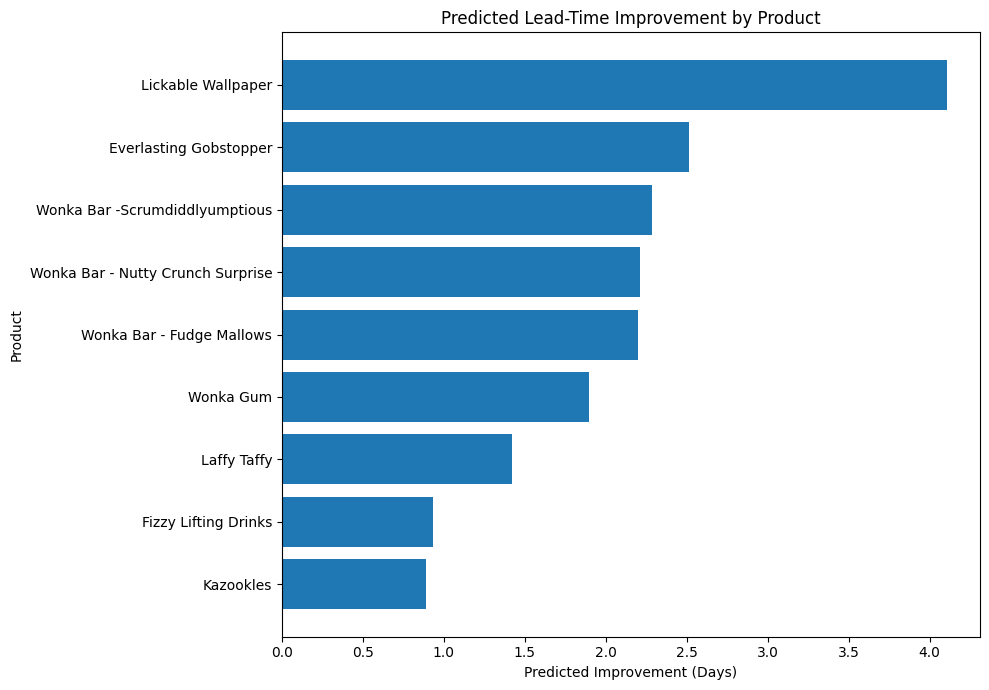

In [227]:
top_chart = (
    recommendation_table
    .sort_values(
        "Predicted Lead-Time Improvement (Days)",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_chart["Product"],
    top_chart[
        "Predicted Lead-Time Improvement (Days)"
    ]
)

plt.title(
    "Predicted Lead-Time Improvement by Product"
)

plt.xlabel("Predicted Improvement (Days)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

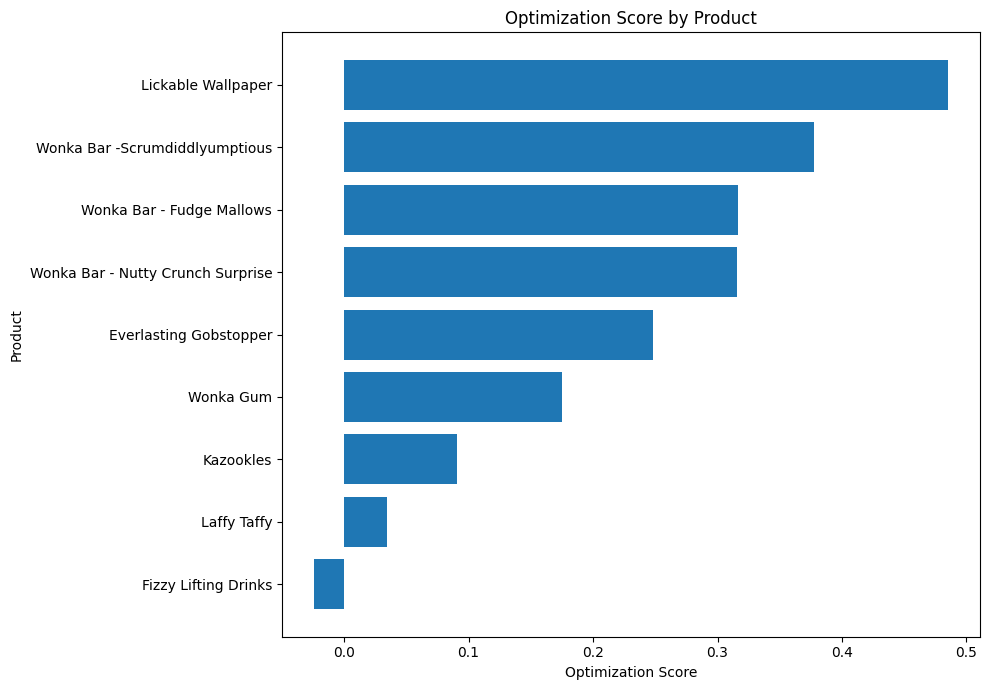

In [228]:
score_chart = (
    recommendation_table
    .sort_values(
        "Optimization Score",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    score_chart["Product"],
    score_chart["Optimization Score"]
)

plt.title(
    "Optimization Score by Product"
)

plt.xlabel("Optimization Score")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [229]:
# Export the final recommendation table

recommendation_table.to_csv(
    "Nassau_Candy_Factory_Recommendations.csv",
    index=False
)

print(
    "Recommendation file exported successfully!"
)

Recommendation file exported successfully!


In [230]:
# Export all product/factory scenarios

product_scenarios.to_csv(
    "Nassau_Candy_All_Factory_Scenarios.csv",
    index=False
)

print(
    "Complete scenario file exported successfully!"
)

Complete scenario file exported successfully!


In [231]:
# Overall project KPIs

total_orders = df["Order ID"].nunique()
total_sales = df["Sales"].sum()
total_profit = df["Gross Profit"].sum()
average_lead_time = df["Lead_Time_Days"].mean()
median_lead_time = df["Lead_Time_Days"].median()
number_products = df["Product Name"].nunique()
number_factories = df["Current_Factory"].nunique()

print("NASSAU CANDY — EXECUTIVE KPIs")
print("-" * 40)

print(f"Total Orders:        {total_orders:,}")
print(f"Total Sales:         ${total_sales:,.2f}")
print(f"Total Gross Profit:  ${total_profit:,.2f}")
print(f"Average Lead Time:   {average_lead_time:,.2f} days")
print(f"Median Lead Time:    {median_lead_time:,.2f} days")
print(f"Products:            {number_products}")
print(f"Factories:           {number_factories}")

NASSAU CANDY — EXECUTIVE KPIs
----------------------------------------
Total Orders:        8,549
Total Sales:         $141,783.63
Total Gross Profit:  $93,442.80
Average Lead Time:   1,320.84 days
Median Lead Time:    1,274.00 days
Products:            15
Factories:           5


In [232]:
# Count products with at least one positive modeled scenario

positive_products = (
    product_scenarios[
        product_scenarios["Average_Lead_Time_Change"] > 0
    ]["Product Name"]
    .nunique()
)

print(
    f"Products with at least one positive modeled scenario: "
    f"{positive_products} of {number_products}"
)

print(
    f"Percentage of products: "
    f"{positive_products / number_products * 100:.1f}%"
)

Products with at least one positive modeled scenario: 9 of 15
Percentage of products: 60.0%


In [233]:
# Historical performance by current factory

factory_performance = (
    df.groupby("Current_Factory")
    .agg(
        Orders=("Order ID", "count"),
        Average_Lead_Time=("Lead_Time_Days", "mean"),
        Median_Lead_Time=("Lead_Time_Days", "median"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum")
    )
    .reset_index()
)

factory_performance.round(2)

,Current_Factory,Orders,Average_Lead_Time,Median_Lead_Time,Total_Sales,Total_Profit
0,Lot's O' Nuts,5692,1321.23,1274.0,76340.15,52771.05
1,Secret Factory,217,1321.87,1274.0,8587.50,4344.70
2,Sugar Shack,33,1340.03,1274.0,220.98,121.23
3,The Other Factory,100,1280.28,1273.0,1282.25,152.25
4,Wicked Choccy's,4152,1321.08,1274.0,55352.75,36053.57


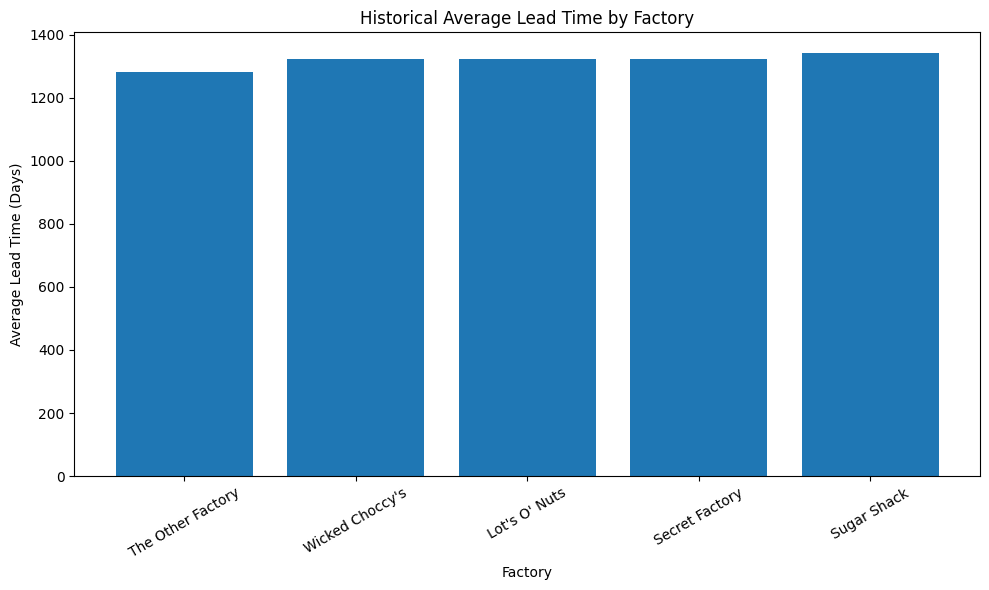

In [234]:
plt.figure(figsize=(10, 6))

factory_chart = factory_performance.sort_values(
    "Average_Lead_Time"
)

plt.bar(
    factory_chart["Current_Factory"],
    factory_chart["Average_Lead_Time"]
)

plt.title(
    "Historical Average Lead Time by Factory"
)

plt.xlabel("Factory")
plt.ylabel("Average Lead Time (Days)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [235]:
# Create product × alternative factory matrix

opportunity_matrix = product_scenarios.pivot_table(
    index="Product Name",
    columns="Alternative_Factory",
    values="Average_Lead_Time_Change"
)

opportunity_matrix.round(2)

Alternative_Factory,Lot's O' Nuts,Secret Factory,Sugar Shack,The Other Factory,Wicked Choccy's
Product Name,,,,,
Everlasting Gobstopper,-2.41,NaN,0.00,0.00,2.52
Fizzy Lifting Drinks,-1.61,-3.27,NaN,0.00,0.93
Fun Dip,-0.80,0.00,NaN,0.00,0.00
Hair Toffee,-1.81,-2.46,0.00,NaN,0.00
Kazookles,-1.59,-2.16,0.00,NaN,0.89
Laffy Taffy,-0.64,-2.95,NaN,0.00,1.42
Lickable Wallpaper,-0.22,NaN,1.20,1.20,4.11
Nerds,0.00,-4.91,NaN,0.00,0.00
SweeTARTS,-1.20,-2.95,NaN,0.00,0.00


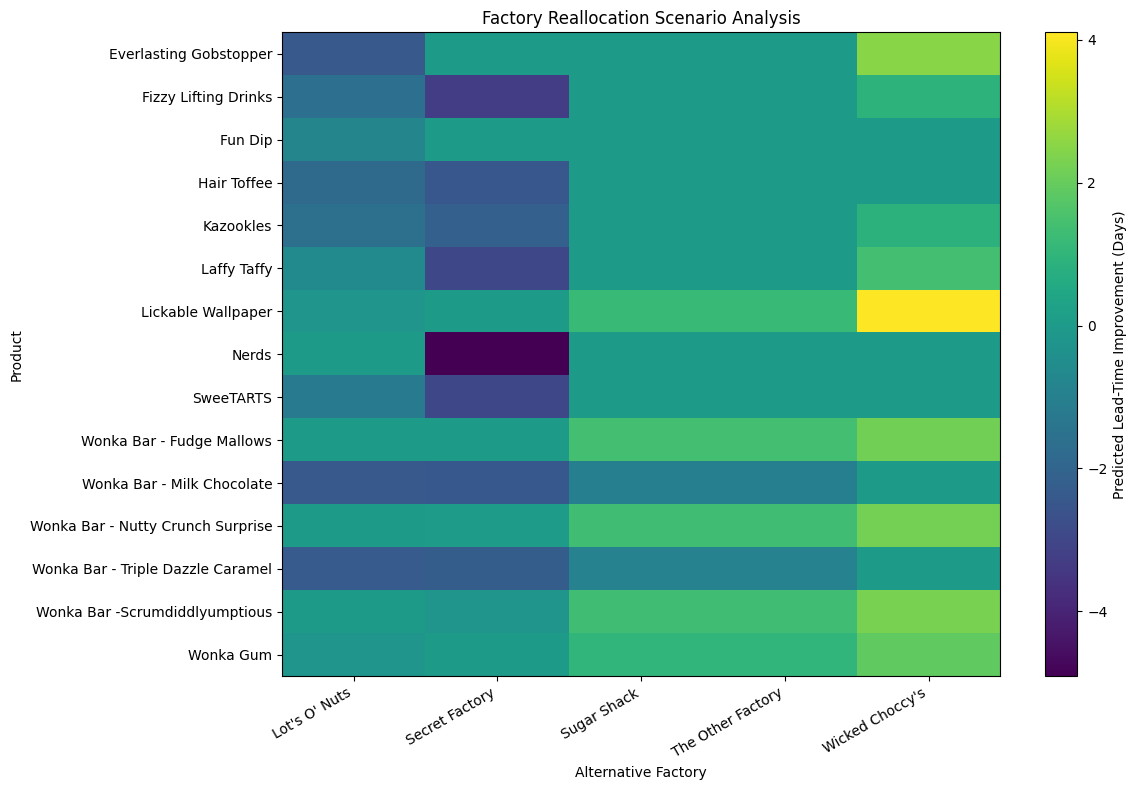

In [236]:
plt.figure(figsize=(12, 8))

plt.imshow(
    opportunity_matrix.fillna(0),
    aspect="auto"
)

plt.colorbar(
    label="Predicted Lead-Time Improvement (Days)"
)

plt.xticks(
    range(len(opportunity_matrix.columns)),
    opportunity_matrix.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(opportunity_matrix.index)),
    opportunity_matrix.index
)

plt.title(
    "Factory Reallocation Scenario Analysis"
)

plt.xlabel("Alternative Factory")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [237]:
# Create final executive recommendation table

executive_recommendations = recommendation_table[
    [
        "Product",
        "Current Factory",
        "Proposed Factory",
        "Predicted Lead-Time Improvement (Days)",
        "Predicted Improvement (%)",
        "Factory Distance (km)",
        "Sales Exposure",
        "Profit Exposure",
        "Decision"
    ]
].copy()

executive_recommendations = (
    executive_recommendations
    .sort_values(
        "Predicted Lead-Time Improvement (Days)",
        ascending=False
    )
)

executive_recommendations.round(2)

,Product,Current Factory,Proposed Factory,Predicted Lead-Time Improvement (Days),Predicted Improvement (%),Factory Distance (km),Sales Exposure,Profit Exposure,Decision
27,Lickable Wallpaper,Secret Factory,Wicked Choccy's,4.11,0.31,1339.21,8220.00,4110.00,MONITOR
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,2.52,0.18,1339.21,130.00,104.00,MONITOR
55,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2.29,0.17,2869.07,40129.20,27867.50,MONITOR
47,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,2.21,0.17,2869.07,32118.47,22915.47,MONITOR
39,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,2.20,0.17,2869.07,34704.00,23136.00,MONITOR
59,Wonka Gum,Secret Factory,Wicked Choccy's,1.90,0.15,1339.21,626.25,325.65,MONITOR
23,Laffy Taffy,Sugar Shack,Wicked Choccy's,1.42,0.11,2189.19,53.73,33.48,MONITOR
7,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,0.93,0.07,2189.19,78.75,47.25,MONITOR
19,Kazookles,The Other Factory,Wicked Choccy's,0.89,0.07,889.07,1238.25,95.25,MONITOR


In [238]:
# Save final executive table

executive_recommendations.to_csv(
    "Nassau_Candy_Executive_Recommendations.csv",
    index=False
)

print(
    "Executive recommendation file created successfully!"
)

Executive recommendation file created successfully!


In [239]:
# Automatically generate key numerical findings

top_opportunity = recommendation_table.iloc[0]

print("NASSAU CANDY — MANAGEMENT SUMMARY")
print("=" * 50)

print(
    f"\nProducts analyzed: {number_products}"
)

print(
    f"Factories analyzed: {number_factories}"
)

print(
    f"Products with positive modeled scenarios: "
    f"{positive_products}"
)

print(
    f"\nLargest modeled lead-time improvement:"
)

print(
    f"Product: {top_opportunity['Product']}"
)

print(
    f"Current Factory: "
    f"{top_opportunity['Current Factory']}"
)

print(
    f"Proposed Factory: "
    f"{top_opportunity['Proposed Factory']}"
)

print(
    f"Predicted improvement: "
    f"{top_opportunity['Predicted Lead-Time Improvement (Days)']:.2f} days"
)

print(
    f"Predicted improvement percentage: "
    f"{top_opportunity['Predicted Improvement (%)']:.2f}%"
)

NASSAU CANDY — MANAGEMENT SUMMARY

Products analyzed: 15
Factories analyzed: 5
Products with positive modeled scenarios: 9

Largest modeled lead-time improvement:
Product: Lickable Wallpaper
Current Factory: Secret Factory
Proposed Factory: Wicked Choccy's
Predicted improvement: 4.11 days
Predicted improvement percentage: 0.31%


In [240]:
# Final data-quality and output validation

print("FINAL PROJECT VALIDATION")
print("=" * 50)

print(
    "Original rows:",
    len(df)
)

print(
    "Scenario rows:",
    len(all_scenarios)
)

print(
    "Product-factory scenarios:",
    len(product_scenarios)
)

print(
    "Recommendation rows:",
    len(recommendation_table)
)

print(
    "Missing recommendation values:"
)

print(
    recommendation_table.isna().sum()
)

FINAL PROJECT VALIDATION
Original rows: 10194
Scenario rows: 56584
Product-factory scenarios: 60
Recommendation rows: 9
Missing recommendation values:
Product                                   0
Current Factory                           0
Proposed Factory                          0
Predicted Lead-Time Improvement (Days)    0
Predicted Improvement (%)                 0
Factory Distance (km)                     0
Sales Exposure                            0
Profit Exposure                           0
Optimization Score                        0
Decision                                  0
dtype: int64


In [241]:
# Find DataFrames currently available in the notebook

dataframes = {
    name: obj.shape
    for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
}

print("DataFrames currently available:\n")

for name, shape in dataframes.items():
    print(f"{name}: {shape}")

DataFrames currently available:

__: (5, 4)
___: (15, 5)
df: (10194, 27)
_104: (5, 18)
_105: (5, 18)
_112: (8, 6)
_121: (5, 26)
lead_by_ship_mode: (4, 3)
_123: (4, 3)
lead_by_region: (4, 3)
_124: (4, 3)
profit_by_region: (4, 2)
_125: (4, 2)
factory_df: (5, 3)
_133: (5, 3)
product_factory_table: (15, 2)
_144: (15, 2)
factory_performance: (5, 6)
_145: (5, 6)
product_performance: (15, 5)
_147: (15, 5)
_148: (10, 5)
_149: (10, 5)
X: (10194, 10)
X_train: (8155, 10)
X_test: (2039, 10)
model_results: (3, 4)
_177: (3, 4)
model_comparison: (3, 4)
_178: (3, 4)
correlation_matrix: (6, 6)
ship_mode_analysis: (4, 4)
_184: (4, 4)
product_lead_analysis: (15, 5)
_185: (15, 5)
factory_lead_analysis: (5, 4)
_186: (5, 4)
feature_importance: (36, 2)
_187: (20, 2)
top_features: (15, 2)
current_assignments: (15, 2)
_191: (15, 2)
factory_distance_df: (20, 3)
_194: (20, 3)
factory_distance_matrix: (5, 5)
_195: (5, 5)
product_baseline: (15, 10)
_196: (15, 10)
_197: (15, 5)
scenario_df: (60, 8)
_199: (5, 8)
sce

In [242]:
# Show columns for all DataFrames

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print("\n" + "=" * 60)
        print(name)
        print("Shape:", obj.shape)
        print("Columns:", list(obj.columns))


__
Shape: (5, 4)
Columns: ['Orders', 'Average_Lead_Time', 'Std_Lead_Time', 'Median_Lead_Time']

___
Shape: (15, 5)
Columns: ['Orders', 'Average_Lead_Time', 'Std_Lead_Time', 'Total_Sales', 'Total_Profit']

df
Shape: (10194, 27)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead_Time_Days', 'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_Day_of_Week', 'Profit_Margin', 'Sales_per_Unit', 'Cost_per_Unit', 'Current_Factory']

_104
Shape: (5, 18)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']

_105
Shape: (5, 18)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Countr

In [243]:
# FINAL SCENARIO DATA CHECK

print("scenario_X rows:", len(scenario_X))
print("all_scenarios rows:", len(all_scenarios))

print("\nExpected scenario rows:")
print("10,194 original orders × 4 alternative factories =",
      10194 * 4)

print("\nAlternative factories in all_scenarios:")
print(all_scenarios["Alternative_Factory"].value_counts())

print("\nScenario count per Order ID:")
scenario_count_check = all_scenarios.groupby("Order ID").size()

print("Minimum:", scenario_count_check.min())
print("Maximum:", scenario_count_check.max())
print("Average:", scenario_count_check.mean())

print("\nDistribution:")
print(scenario_count_check.value_counts().sort_index())

scenario_X rows: 40776
all_scenarios rows: 56584

Expected scenario rows:
10,194 original orders × 4 alternative factories = 40776

Alternative factories in all_scenarios:
Alternative_Factory
Sugar Shack          14113
The Other Factory    14042
Secret Factory       13921
Wicked Choccy's       8298
Lot's O' Nuts         6210
Name: count, dtype: int64

Scenario count per Order ID:
Minimum: 4
Maximum: 100
Average: 6.618785822903264

Distribution:
4      7176
16     1152
36      178
64       35
100       8
Name: count, dtype: int64


In [244]:
scenario_X

,Product Name,Current_Factory,Region,Ship Mode,Division,Units,Sales,Order_Month,Order_Quarter,Order_Day_of_Week
0,Wonka Bar - Milk Chocolate,Lot's O' Nuts,Interior,Standard Class,Chocolate,2,6.50,1,1,2
1,Wonka Bar - Triple Dazzle Caramel,Lot's O' Nuts,Interior,Standard Class,Chocolate,2,7.50,1,1,3
2,Wonka Bar - Triple Dazzle Caramel,Lot's O' Nuts,Atlantic,Standard Class,Chocolate,3,11.25,1,1,4
3,Wonka Bar - Triple Dazzle Caramel,Lot's O' Nuts,Gulf,Standard Class,Chocolate,2,7.50,1,1,5
4,Wonka Bar - Milk Chocolate,Lot's O' Nuts,Gulf,First Class,Chocolate,3,9.75,1,1,5
...,...,...,...,...,...,...,...,...,...,...
40771,Wonka Bar - Milk Chocolate,The Other Factory,Atlantic,Standard Class,Chocolate,3,9.75,12,4,1
40772,Wonka Bar - Nutty Crunch Surprise,The Other Factory,Pacific,Standard Class,Chocolate,2,6.98,12,4,1
40773,Wonka Bar -Scrumdiddlyumptious,The Other Factory,Pacific,Standard Class,Chocolate,3,10.80,12,4,1
40774,Wonka Bar - Triple Dazzle Caramel,The Other Factory,Atlantic,Standard Class,Chocolate,7,26.25,12,4,1


In [245]:
# ============================================================
# SAFE DIAGNOSTIC - DO NOT MODIFY ANY DATA
# ============================================================

print("all_scenarios shape:")
print(all_scenarios.shape)

print("\nall_scenarios columns:")
print(all_scenarios.columns.tolist())

print("\nFirst 5 rows:")
display(all_scenarios.head())

all_scenarios shape:
(56584, 18)

all_scenarios columns:
['Order ID', 'Product Name', 'Current_Factory', 'Region', 'Ship Mode', 'Division', 'Units', 'Sales', 'Gross Profit', 'Order_Month', 'Order_Quarter', 'Order_Day_of_Week', 'Lead_Time_Days', 'Alternative_Factory', 'Predicted_Alternative_Lead_Time', 'Predicted_Current_Lead_Time', 'Predicted_Lead_Time_Change', 'Distance_km']

First 5 rows:


,Order ID,Product Name,Current_Factory,Region,Ship Mode,Division,Units,Sales,Gross Profit,Order_Month,Order_Quarter,Order_Day_of_Week,Lead_Time_Days,Alternative_Factory,Predicted_Alternative_Lead_Time,Predicted_Current_Lead_Time,Predicted_Lead_Time_Change,Distance_km
0,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,Chocolate,2,6.50,4.22,1,1,2,909,Lot's O' Nuts,1441.466204,1435.877492,-5.588713,2869.072753
1,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Standard Class,Chocolate,2,7.50,4.90,1,1,3,909,Lot's O' Nuts,1405.206765,1399.618052,-5.588713,2869.072753
2,US-2021-141817-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,Chocolate,3,11.25,7.35,1,1,4,912,Lot's O' Nuts,1240.463670,1232.465884,-7.997786,2869.072753
3,US-2021-167199-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Gulf,Standard Class,Chocolate,2,7.50,4.90,1,1,5,909,Lot's O' Nuts,1053.553240,1053.553240,0.000000,2869.072753
4,US-2021-106054-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Gulf,First Class,Chocolate,3,9.75,6.33,1,1,5,906,Lot's O' Nuts,1045.096332,1042.687259,-2.409073,2869.072753


In [246]:
# ============================================================
# CHECK DUPLICATION WITHOUT USING Alternative_Factory
# ============================================================

order_counts = all_scenarios.groupby("Order ID").size()

print("Orders:", order_counts.size)
print("Minimum rows per order:", order_counts.min())
print("Maximum rows per order:", order_counts.max())
print("Average rows per order:", round(order_counts.mean(), 2))

print("\nRows per order distribution:")
print(order_counts.value_counts().sort_index())

Orders: 8549
Minimum rows per order: 4
Maximum rows per order: 100
Average rows per order: 6.62

Rows per order distribution:
4      7176
16     1152
36      178
64       35
100       8
Name: count, dtype: int64


In [247]:
# ============================================================
# REBUILD ALL_SCENARIOS - CLEAN VERSION
# ============================================================

# Create the 4 alternative-factory combinations
# for every original order.

scenario_parts = []

for alternative_factory in all_factories:

    temp_scenario = scenario_base.copy()

    # Keep only orders where this is NOT the current factory
    temp_scenario = temp_scenario[
        temp_scenario["Current_Factory"] != alternative_factory
    ].copy()

    # Assign the alternative factory
    temp_scenario["Alternative_Factory"] = alternative_factory

    scenario_parts.append(temp_scenario)


# Combine all scenario datasets
clean_base = pd.concat(
    scenario_parts,
    ignore_index=True
)

print("Rows created:", len(clean_base))
print("Expected rows:", 10194 * 4)

Rows created: 40776
Expected rows: 40776


In [248]:
# ============================================================
# STEP 1: VALIDATE CLEAN SCENARIO DATA
# ============================================================

print("Total scenario rows:", len(clean_base))

# Each original order should appear exactly 4 times
order_counts = clean_base.groupby("Order ID").size()

print("\nOrders with exactly 4 alternatives:",
      (order_counts == 4).sum())

print("Orders with incorrect number of alternatives:",
      (order_counts != 4).sum())

# Check alternative factory distribution
print("\nAlternative factory distribution:")
print(clean_base["Alternative_Factory"].value_counts())

# Check that alternative factory is never the current factory
invalid_rows = (
    clean_base["Current_Factory"]
    == clean_base["Alternative_Factory"]
).sum()

print("\nRows where Alternative Factory = Current Factory:", invalid_rows)

# Show a sample
print("\nSample of clean scenario data:")
display(
    clean_base[
        [
            "Order ID",
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Region",
            "Units",
            "Sales"
        ]
    ].head(10)
)

Total scenario rows: 40776

Orders with exactly 4 alternatives: 7176
Orders with incorrect number of alternatives: 1373

Alternative factory distribution:
Alternative_Factory
Sugar Shack          10161
The Other Factory    10094
Secret Factory        9977
Wicked Choccy's       6042
Lot's O' Nuts         4502
Name: count, dtype: int64

Rows where Alternative Factory = Current Factory: 0

Sample of clean scenario data:


,Order ID,Product Name,Current_Factory,Alternative_Factory,Region,Units,Sales
0,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Interior,2,6.50
1,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Interior,2,7.50
2,US-2021-141817-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Atlantic,3,11.25
3,US-2021-167199-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Gulf,2,7.50
4,US-2021-106054-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Gulf,3,9.75
5,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Gulf,4,13.00
6,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Gulf,1,3.25
7,US-2021-130813-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,3,9.75
8,US-2021-105417-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Interior,3,9.75
9,US-2021-105417-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Interior,7,26.25


In [249]:
# ============================================================
# STEP 2: CHECK DUPLICATE ORDER IDs IN ORIGINAL DATA
# ============================================================

print("Original rows:", len(df))
print("Unique Order IDs:", df["Order ID"].nunique())

duplicate_order_counts = df["Order ID"].value_counts()

print("\nOrder ID frequency distribution:")
print(duplicate_order_counts.value_counts().sort_index())

print("\nNumber of Order IDs appearing more than once:",
      (duplicate_order_counts > 1).sum())

print("\nMaximum rows for a single Order ID:",
      duplicate_order_counts.max())

# Show examples of duplicate Order IDs
print("\nExample duplicate Order IDs:")
display(
    duplicate_order_counts[
        duplicate_order_counts > 1
    ].head(10).to_frame("Row_Count")
)

Original rows: 10194
Unique Order IDs: 8549

Order ID frequency distribution:
count
1    7176
2    1152
3     178
4      35
5       8
Name: count, dtype: int64

Number of Order IDs appearing more than once: 1373

Maximum rows for a single Order ID: 5

Example duplicate Order IDs:


,Row_Count
Order ID,
US-2022-130974-CHO-SCR-58000,5
US-2024-104731-CHO-FUD-51000,5
US-2024-100111-CHO-NUT-13000,5
US-2022-112130-CHO-FUD-51000,5
US-2024-113278-CHO-MIL-31000,5
US-2024-157987-CHO-NUT-13000,5
US-2022-126977-CHO-SCR-58000,5
US-2021-155502-CHO-MIL-31000,5
US-2024-109253-CHO-SCR-58000,4


In [250]:
# ============================================================
# STEP 3A: VALIDATE CLEAN SCENARIOS
# ============================================================

print("Columns in clean_base:")
print(clean_base.columns.tolist())

print("\nTotal scenario rows:", len(clean_base))
print("Expected scenario rows:", len(df) * 4)

# Check missing values
print("\nMissing Alternative Factory values:",
      clean_base["Alternative_Factory"].isna().sum())

# Check current factory is never the alternative
invalid_factory_pairs = (
    clean_base["Current_Factory"]
    == clean_base["Alternative_Factory"]
).sum()

print("Current = Alternative factory rows:", invalid_factory_pairs)

# Since each original DATASET ROW has 4 alternatives,
# and clean_base was constructed from scenario_base,
# verify that every combination of the original row-level
# attributes appears 4 times.

scenario_key = [
    "Order ID",
    "Product Name",
    "Current_Factory",
    "Region",
    "Ship Mode",
    "Division",
    "Units",
    "Sales"
]

scenario_counts = clean_base.groupby(scenario_key).size()

print("\nScenario groups with exactly 4 alternatives:",
      (scenario_counts == 4).sum())

print("Scenario groups with incorrect number of alternatives:",
      (scenario_counts != 4).sum())

print("\nAlternative factory distribution:")
print(clean_base["Alternative_Factory"].value_counts())

# Final basic validation
if (
    len(clean_base) == len(df) * 4
    and clean_base["Alternative_Factory"].isna().sum() == 0
    and invalid_factory_pairs == 0
):
    print("\n✅ BASIC SCENARIO VALIDATION PASSED")
else:
    print("\n⚠️ VALIDATION FAILED")

Columns in clean_base:
['Order ID', 'Product Name', 'Current_Factory', 'Region', 'Ship Mode', 'Division', 'Units', 'Sales', 'Gross Profit', 'Order_Month', 'Order_Quarter', 'Order_Day_of_Week', 'Lead_Time_Days', 'Alternative_Factory']

Total scenario rows: 40776
Expected scenario rows: 40776

Missing Alternative Factory values: 0
Current = Alternative factory rows: 0

Scenario groups with exactly 4 alternatives: 9574
Scenario groups with incorrect number of alternatives: 307

Alternative factory distribution:
Alternative_Factory
Sugar Shack          10161
The Other Factory    10094
Secret Factory        9977
Wicked Choccy's       6042
Lot's O' Nuts         4502
Name: count, dtype: int64

✅ BASIC SCENARIO VALIDATION PASSED


In [251]:
# ============================================================
# STEP 4: FIND THE GRADIENT BOOSTING MODEL
# ============================================================

model_candidates = {}

for name, obj in globals().items():
    if hasattr(obj, "predict"):
        model_candidates[name] = type(obj).__name__

print("Objects in the notebook that have a predict() method:\n")

for name, model_type in model_candidates.items():
    print(f"{name}  -->  {model_type}")

Objects in the notebook that have a predict() method:

Pipeline  -->  ABCMeta
LinearRegression  -->  ABCMeta
linear_model  -->  Pipeline
RandomForestRegressor  -->  ABCMeta
random_forest_model  -->  Pipeline
GradientBoostingRegressor  -->  ABCMeta
gradient_boosting_model  -->  Pipeline
model  -->  Pipeline


In [252]:
# ============================================================
# STEP 5: PREDICT CLEAN ALTERNATIVE-FACTORY SCENARIOS
# ============================================================

# These are the same features used when training the model
feature_cols = [
    "Product Name",
    "Current_Factory",
    "Region",
    "Ship Mode",
    "Division",
    "Units",
    "Sales",
    "Order_Month",
    "Order_Quarter",
    "Order_Day_of_Week"
]

# Create feature matrix for the 40,776 clean scenarios
clean_scenario_X = clean_base[feature_cols].copy()

print("Clean scenario feature shape:", clean_scenario_X.shape)

# Generate predicted lead time for each alternative factory
clean_base["Predicted_Alternative_Lead_Time"] = (
    gradient_boosting_model.predict(clean_scenario_X)
)

print(
    "Predictions created:",
    len(clean_base["Predicted_Alternative_Lead_Time"])
)

# Basic prediction check
print("\nPrediction summary:")
print(
    clean_base["Predicted_Alternative_Lead_Time"].describe()
)

# Display sample
print("\nSample predictions:")
display(
    clean_base[
        [
            "Order ID",
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Predicted_Alternative_Lead_Time"
        ]
    ].head(10)
)

Clean scenario feature shape: (40776, 10)
Predictions created: 40776

Prediction summary:
count    40776.000000
mean      1321.213232
std         66.490404
min        969.291007
25%       1282.760932
50%       1331.730792
75%       1361.246292
max       1638.396133
Name: Predicted_Alternative_Lead_Time, dtype: float64

Sample predictions:


,Order ID,Product Name,Current_Factory,Alternative_Factory,Predicted_Alternative_Lead_Time
0,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1435.877492
1,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1399.618052
2,US-2021-141817-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1232.465884
3,US-2021-167199-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1053.553240
4,US-2021-106054-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1042.687259
5,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1052.867079
6,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1083.565281
7,US-2021-130813-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1134.084531
8,US-2021-105417-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1324.592017
9,US-2021-105417-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1347.549434


In [253]:
# ============================================================
# STEP 6: COMPARE CURRENT VS ALTERNATIVE FACTORY
# ============================================================

# Use the same features to predict the current configuration
current_X_clean = scenario_base[feature_cols].copy()

# Predict current-factory lead time
current_pred_clean = gradient_boosting_model.predict(current_X_clean)

# Create a dataframe containing the current prediction
current_clean_df = scenario_base[
    ["Order ID", "Product Name", "Current_Factory"]
].copy()

current_clean_df["Predicted_Current_Lead_Time"] = current_pred_clean

# Merge current prediction onto the 40,776 alternative scenarios
clean_base = clean_base.merge(
    current_clean_df[
        [
            "Order ID",
            "Product Name",
            "Current_Factory",
            "Predicted_Current_Lead_Time"
        ]
    ],
    on=[
        "Order ID",
        "Product Name",
        "Current_Factory"
    ],
    how="left"
)

# Calculate predicted improvement
clean_base["Predicted_Lead_Time_Change"] = (
    clean_base["Predicted_Current_Lead_Time"]
    - clean_base["Predicted_Alternative_Lead_Time"]
)

# Calculate percentage improvement
clean_base["Predicted_Improvement_Pct"] = (
    clean_base["Predicted_Lead_Time_Change"]
    / clean_base["Predicted_Current_Lead_Time"]
) * 100

print("Clean scenario rows:", len(clean_base))

print(
    "Missing current predictions:",
    clean_base["Predicted_Current_Lead_Time"].isna().sum()
)

print("\nLead-time improvement summary:")
print(
    clean_base["Predicted_Lead_Time_Change"].describe()
)

print("\nPercentage improvement summary:")
print(
    clean_base["Predicted_Improvement_Pct"].describe()
)

print("\nSample comparison:")
display(
    clean_base[
        [
            "Order ID",
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Predicted_Current_Lead_Time",
            "Predicted_Alternative_Lead_Time",
            "Predicted_Lead_Time_Change",
            "Predicted_Improvement_Pct"
        ]
    ].head(10)
)

Clean scenario rows: 56584
Missing current predictions: 0

Lead-time improvement summary:
count    56584.000000
mean         0.000000
std         10.210380
min       -108.466266
25%          0.000000
50%          0.000000
75%          0.000000
max        108.466266
Name: Predicted_Lead_Time_Change, dtype: float64

Percentage improvement summary:
count    56584.000000
mean        -0.003061
std          0.782786
min         -8.570560
25%          0.000000
50%          0.000000
75%          0.000000
max          7.894000
Name: Predicted_Improvement_Pct, dtype: float64

Sample comparison:


,Order ID,Product Name,Current_Factory,Alternative_Factory,Predicted_Current_Lead_Time,Predicted_Alternative_Lead_Time,Predicted_Lead_Time_Change,Predicted_Improvement_Pct
0,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1435.877492,1435.877492,0.000000,0.000000
1,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1399.618052,1399.618052,0.000000,0.000000
2,US-2021-141817-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1232.465884,1232.465884,0.000000,0.000000
3,US-2021-167199-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1053.553240,1053.553240,0.000000,0.000000
4,US-2021-106054-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1042.687259,1042.687259,0.000000,0.000000
5,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1052.867079,1052.867079,0.000000,0.000000
6,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1083.565281,1052.867079,30.698203,2.833074
7,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1052.867079,1083.565281,-30.698203,-2.915677
8,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1083.565281,1083.565281,0.000000,0.000000
9,US-2021-130813-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1134.084531,1134.084531,0.000000,0.000000


In [254]:
# ============================================================
# STEP 7: BUILD CLEAN PRODUCT-FACTORY SCENARIOS
# ============================================================

clean_product_scenarios = (
    clean_base
    .groupby(
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory"
        ],
        as_index=False
    )
    .agg(
        Orders=("Order ID", "count"),
        Average_Current_Predicted_Lead_Time=(
            "Predicted_Current_Lead_Time",
            "mean"
        ),
        Average_Alternative_Predicted_Lead_Time=(
            "Predicted_Alternative_Lead_Time",
            "mean"
        ),
        Average_Lead_Time_Change=(
            "Predicted_Lead_Time_Change",
            "mean"
        ),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum")
    )
)

# ------------------------------------------------------------
# Add factory-to-factory distance
# ------------------------------------------------------------

distance_lookup = (
    factory_distance_df
    .set_index(["From_Factory", "To_Factory"])["Distance_km"]
    .to_dict()
)

clean_product_scenarios["Average_Distance_km"] = (
    clean_product_scenarios.apply(
        lambda row: distance_lookup.get(
            (
                row["Current_Factory"],
                row["Alternative_Factory"]
            ),
            None
        ),
        axis=1
    )
)

# ------------------------------------------------------------
# Calculate percentage improvement
# ------------------------------------------------------------

clean_product_scenarios["Lead_Time_Improvement_Pct"] = (
    clean_product_scenarios["Average_Lead_Time_Change"]
    / clean_product_scenarios["Average_Current_Predicted_Lead_Time"]
) * 100

# ------------------------------------------------------------
# Sort by predicted improvement
# ------------------------------------------------------------

clean_product_scenarios = (
    clean_product_scenarios
    .sort_values(
        "Average_Lead_Time_Change",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "Product-factory scenarios:",
    len(clean_product_scenarios)
)

print(
    "Unique products:",
    clean_product_scenarios["Product Name"].nunique()
)

print(
    "Unique alternative factories:",
    clean_product_scenarios["Alternative_Factory"].nunique()
)

print(
    "\nMissing distance values:",
    clean_product_scenarios["Average_Distance_km"].isna().sum()
)

print("\nTop 15 predicted improvements:")

display(
    clean_product_scenarios[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Average_Current_Predicted_Lead_Time",
            "Average_Alternative_Predicted_Lead_Time",
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct",
            "Average_Distance_km",
            "Total_Sales",
            "Total_Profit"
        ]
    ].head(15)
)

Product-factory scenarios: 60
Unique products: 15
Unique alternative factories: 5

Missing distance values: 0

Top 15 predicted improvements:


,Product Name,Current_Factory,Alternative_Factory,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Average_Distance_km,Total_Sales,Total_Profit
0,Everlasting Gobstopper,Secret Factory,Lot's O' Nuts,1364.725471,1364.725471,0.0,0.0,2098.588792,130.00,104.00
1,Everlasting Gobstopper,Secret Factory,Sugar Shack,1364.725471,1364.725471,0.0,0.0,863.723221,130.00,104.00
2,Everlasting Gobstopper,Secret Factory,The Other Factory,1364.725471,1364.725471,0.0,0.0,705.638309,130.00,104.00
3,Everlasting Gobstopper,Secret Factory,Wicked Choccy's,1364.725471,1364.725471,0.0,0.0,1339.213437,130.00,104.00
4,Fizzy Lifting Drinks,Sugar Shack,Lot's O' Nuts,1304.097104,1304.097104,0.0,0.0,2137.812671,78.75,47.25
5,Fizzy Lifting Drinks,Sugar Shack,Secret Factory,1304.097104,1304.097104,0.0,0.0,863.723221,78.75,47.25
6,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,1304.097104,1304.097104,0.0,0.0,1533.821089,78.75,47.25
7,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,1304.097104,1304.097104,0.0,0.0,2189.186842,78.75,47.25
8,Fun Dip,Sugar Shack,Lot's O' Nuts,1329.332694,1329.332694,0.0,0.0,2137.812671,12.00,4.80
9,Fun Dip,Sugar Shack,Secret Factory,1329.332694,1329.332694,0.0,0.0,863.723221,12.00,4.80


In [255]:
# ============================================================
# STEP 8: CALCULATE BUSINESS OPTIMIZATION SCORE
# ============================================================

# Make a copy so we preserve the clean scenario table
scored_scenarios = clean_product_scenarios.copy()

# ------------------------------------------------------------
# Helper function for min-max scaling
# ------------------------------------------------------------

def min_max_scale(series):
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(1.0, index=series.index)

    return (series - min_value) / (max_value - min_value)


# ------------------------------------------------------------
# Create individual decision scores
# ------------------------------------------------------------

scored_scenarios["Lead_Time_Score"] = min_max_scale(
    scored_scenarios["Average_Lead_Time_Change"]
)

scored_scenarios["Profit_Score"] = min_max_scale(
    scored_scenarios["Total_Profit"]
)

scored_scenarios["Distance_Score"] = min_max_scale(
    scored_scenarios["Average_Distance_km"]
)


# ------------------------------------------------------------
# Combined optimization score
# ------------------------------------------------------------

scored_scenarios["Optimization_Score"] = (
    0.50 * scored_scenarios["Lead_Time_Score"]
    + 0.30 * scored_scenarios["Profit_Score"]
    - 0.20 * scored_scenarios["Distance_Score"]
)


# ------------------------------------------------------------
# Identify whether the alternative improves lead time
# ------------------------------------------------------------

scored_scenarios["Scenario_Status"] = (
    scored_scenarios["Average_Lead_Time_Change"]
    .apply(
        lambda x: "IMPROVEMENT" if x > 0 else "NO IMPROVEMENT"
    )
)


# ------------------------------------------------------------
# Sort by optimization score
# ------------------------------------------------------------

scored_scenarios = (
    scored_scenarios
    .sort_values("Optimization_Score", ascending=False)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Total scored scenarios:", len(scored_scenarios))

print(
    "Scenarios showing predicted improvement:",
    (scored_scenarios["Average_Lead_Time_Change"] > 0).sum()
)

print(
    "Scenarios showing no improvement:",
    (scored_scenarios["Average_Lead_Time_Change"] <= 0).sum()
)

print("\nTop 15 scenarios by optimization score:")

display(
    scored_scenarios[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct",
            "Total_Sales",
            "Total_Profit",
            "Average_Distance_km",
            "Optimization_Score",
            "Scenario_Status"
        ]
    ].head(15)
)

Total scored scenarios: 60
Scenarios showing predicted improvement: 0
Scenarios showing no improvement: 60

Top 15 scenarios by optimization score:


,Product Name,Current_Factory,Alternative_Factory,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Total_Sales,Total_Profit,Average_Distance_km,Optimization_Score,Scenario_Status
0,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,0.0,0.0,40035.00,26156.20,889.070924,0.764617,NO IMPROVEMENT
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,0.0,0.0,37995.75,24668.01,889.070924,0.748593,NO IMPROVEMENT
2,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,0.0,0.0,40035.00,26156.20,1339.213437,0.723003,NO IMPROVEMENT
3,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,0.0,0.0,37995.75,24668.01,1339.213437,0.706980,NO IMPROVEMENT
4,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,0.0,0.0,40129.20,27867.50,2020.574896,0.678440,NO IMPROVEMENT
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Secret Factory,0.0,0.0,40129.20,27867.50,2098.588792,0.671228,NO IMPROVEMENT
6,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Sugar Shack,0.0,0.0,40129.20,27867.50,2137.812671,0.667602,NO IMPROVEMENT
7,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Sugar Shack,0.0,0.0,40035.00,26156.20,2189.186842,0.644427,NO IMPROVEMENT
8,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,0.0,0.0,37995.75,24668.01,2189.186842,0.628403,NO IMPROVEMENT
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,0.0,0.0,34704.00,23136.00,2020.574896,0.627495,NO IMPROVEMENT


In [256]:
# ============================================================
# STEP 8A: DIAGNOSE PREDICTED LEAD-TIME DIFFERENCES
# ============================================================

print("Lead-time change statistics:")
display(
    scored_scenarios[
        [
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct"
        ]
    ].describe()
)

print("\nBest 10 scenarios by predicted lead-time change:")

display(
    scored_scenarios[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Average_Current_Predicted_Lead_Time",
            "Average_Alternative_Predicted_Lead_Time",
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct"
        ]
    ]
    .sort_values(
        "Average_Lead_Time_Change",
        ascending=False
    )
    .head(10)
)

print("\nWorst 10 scenarios:")

display(
    scored_scenarios[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Average_Current_Predicted_Lead_Time",
            "Average_Alternative_Predicted_Lead_Time",
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct"
        ]
    ]
    .sort_values(
        "Average_Lead_Time_Change",
        ascending=True
    )
    .head(10)
)

Lead-time change statistics:


,Average_Lead_Time_Change,Lead_Time_Improvement_Pct
count,60.0,60.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0



Best 10 scenarios by predicted lead-time change:


,Product Name,Current_Factory,Alternative_Factory,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Lead_Time_Improvement_Pct
0,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,1320.803776,1320.803776,0.0,0.0
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,1315.920169,1315.920169,0.0,0.0
2,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,1320.803776,1320.803776,0.0,0.0
3,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,1315.920169,1315.920169,0.0,0.0
4,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,1324.686218,1324.686218,0.0,0.0
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Secret Factory,1324.686218,1324.686218,0.0,0.0
6,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Sugar Shack,1324.686218,1324.686218,0.0,0.0
7,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Sugar Shack,1320.803776,1320.803776,0.0,0.0
8,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,1315.920169,1315.920169,0.0,0.0
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,1319.055309,1319.055309,0.0,0.0



Worst 10 scenarios:


,Product Name,Current_Factory,Alternative_Factory,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Lead_Time_Improvement_Pct
0,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,1320.803776,1320.803776,0.0,0.0
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,1315.920169,1315.920169,0.0,0.0
2,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,1320.803776,1320.803776,0.0,0.0
3,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,1315.920169,1315.920169,0.0,0.0
4,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,The Other Factory,1324.686218,1324.686218,0.0,0.0
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Secret Factory,1324.686218,1324.686218,0.0,0.0
6,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Sugar Shack,1324.686218,1324.686218,0.0,0.0
7,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Sugar Shack,1320.803776,1320.803776,0.0,0.0
8,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,1315.920169,1315.920169,0.0,0.0
9,Wonka Bar - Fudge Mallows,Lot's O' Nuts,The Other Factory,1319.055309,1319.055309,0.0,0.0


In [257]:
# ============================================================
# STEP 8B: CORRECT ALTERNATIVE-FACTORY PREDICTIONS
# ============================================================

# Start with the clean scenario features
clean_scenario_X = clean_base[feature_cols].copy()

# IMPORTANT:
# For a scenario prediction, the model must see the
# ALTERNATIVE factory as the factory being used.
clean_scenario_X["Current_Factory"] = (
    clean_base["Alternative_Factory"].values
)

print("Feature matrix shape:", clean_scenario_X.shape)

# Check the factory values being passed to the model
print("\nFactories being used for scenario prediction:")
print(clean_scenario_X["Current_Factory"].value_counts())

# Generate corrected alternative-factory predictions
clean_base["Predicted_Alternative_Lead_Time"] = (
    gradient_boosting_model.predict(clean_scenario_X)
)

# Recalculate improvement
clean_base["Predicted_Lead_Time_Change"] = (
    clean_base["Predicted_Current_Lead_Time"]
    - clean_base["Predicted_Alternative_Lead_Time"]
)

# Recalculate percentage improvement
clean_base["Predicted_Improvement_Pct"] = (
    clean_base["Predicted_Lead_Time_Change"]
    / clean_base["Predicted_Current_Lead_Time"]
) * 100

# Summary
print("\nCorrected prediction summary:")
print(
    clean_base["Predicted_Lead_Time_Change"].describe()
)

print("\nScenarios with predicted improvement:",
      (clean_base["Predicted_Lead_Time_Change"] > 0).sum())

print("Scenarios with no predicted improvement:",
      (clean_base["Predicted_Lead_Time_Change"] <= 0).sum())

# Show examples
print("\nSample corrected scenarios:")

display(
    clean_base[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Predicted_Current_Lead_Time",
            "Predicted_Alternative_Lead_Time",
            "Predicted_Lead_Time_Change",
            "Predicted_Improvement_Pct"
        ]
    ].head(15)
)

Feature matrix shape: (56584, 10)

Factories being used for scenario prediction:
Current_Factory
Sugar Shack          14113
The Other Factory    14042
Secret Factory       13921
Wicked Choccy's       8298
Lot's O' Nuts         6210
Name: count, dtype: int64

Corrected prediction summary:
count    56584.000000
mean         0.013820
std         10.614946
min       -117.064036
25%          0.000000
50%          0.000000
75%          2.409073
max        105.951108
Name: Predicted_Lead_Time_Change, dtype: float64

Scenarios with predicted improvement: 19405
Scenarios with no predicted improvement: 37179

Sample corrected scenarios:


,Product Name,Current_Factory,Alternative_Factory,Predicted_Current_Lead_Time,Predicted_Alternative_Lead_Time,Predicted_Lead_Time_Change,Predicted_Improvement_Pct
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1435.877492,1441.466204,-5.588713,-0.389219
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1399.618052,1405.206765,-5.588713,-0.399303
2,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1232.465884,1240.463670,-7.997786,-0.648926
3,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1053.553240,1053.553240,0.000000,0.000000
4,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1042.687259,1045.096332,-2.409073,-0.231045
5,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1052.867079,1055.276152,-2.409073,-0.228811
6,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1083.565281,1055.276152,28.289130,2.610745
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1052.867079,1092.163051,-39.295973,-3.732282
8,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1083.565281,1092.163051,-8.597770,-0.793470
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1134.084531,1136.493604,-2.409073,-0.212424


In [258]:
# ============================================================
# STEP 8C: RESTORE CLEAN SCENARIO DATA
# ============================================================

# Rebuild the 40,776-row scenario table from scenario_base
scenario_parts = []

for alternative_factory in all_factories:
    temp_scenario = scenario_base.copy()

    # Exclude the current factory from the alternatives
    temp_scenario = temp_scenario[
        temp_scenario["Current_Factory"] != alternative_factory
    ].copy()

    # Add the alternative factory
    temp_scenario["Alternative_Factory"] = alternative_factory

    scenario_parts.append(temp_scenario)

# Combine all four alternative-factory groups
clean_base = pd.concat(
    scenario_parts,
    ignore_index=True
)

print("Restored clean scenario rows:", len(clean_base))
print("Expected rows:", len(df) * 4)

print("\nAlternative factory distribution:")
print(clean_base["Alternative_Factory"].value_counts())

print("\nCurrent = Alternative rows:")
print(
    (
        clean_base["Current_Factory"]
        == clean_base["Alternative_Factory"]
    ).sum()
)

Restored clean scenario rows: 40776
Expected rows: 40776

Alternative factory distribution:
Alternative_Factory
Sugar Shack          10161
The Other Factory    10094
Secret Factory        9977
Wicked Choccy's       6042
Lot's O' Nuts         4502
Name: count, dtype: int64

Current = Alternative rows:
0


In [259]:
# ============================================================
# STEP 9: ATTACH CURRENT-FACTORY PREDICTIONS SAFELY
# ============================================================

# Predict the current configuration for the original 10,194 rows
current_X_clean = scenario_base[feature_cols].copy()

current_predictions = gradient_boosting_model.predict(
    current_X_clean
)

print("Current predictions:", len(current_predictions))
print("Original rows:", len(scenario_base))

# ------------------------------------------------------------
# Attach the current prediction to each of the 4 scenario
# copies WITHOUT using Order ID as a merge key.
# ------------------------------------------------------------

clean_base["Predicted_Current_Lead_Time"] = (
    list(current_predictions)
    + list(current_predictions)
    + list(current_predictions)
    + list(current_predictions)
)

print("\nClean scenario rows:", len(clean_base))
print(
    "Current prediction rows:",
    clean_base["Predicted_Current_Lead_Time"].notna().sum()
)

# ------------------------------------------------------------
# Now create the alternative prediction correctly.
#
# IMPORTANT:
# The model's factory feature is called Current_Factory.
# For an alternative scenario, replace that feature with
# the Alternative_Factory.
# ------------------------------------------------------------

clean_scenario_X = clean_base[feature_cols].copy()

clean_scenario_X["Current_Factory"] = (
    clean_base["Alternative_Factory"].values
)

alternative_predictions = gradient_boosting_model.predict(
    clean_scenario_X
)

clean_base["Predicted_Alternative_Lead_Time"] = (
    alternative_predictions
)

# ------------------------------------------------------------
# Calculate improvement
# ------------------------------------------------------------

clean_base["Predicted_Lead_Time_Change"] = (
    clean_base["Predicted_Current_Lead_Time"]
    - clean_base["Predicted_Alternative_Lead_Time"]
)

clean_base["Predicted_Improvement_Pct"] = (
    clean_base["Predicted_Lead_Time_Change"]
    / clean_base["Predicted_Current_Lead_Time"]
) * 100

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

print("\nMissing current predictions:",
      clean_base["Predicted_Current_Lead_Time"].isna().sum())

print("Missing alternative predictions:",
      clean_base["Predicted_Alternative_Lead_Time"].isna().sum())

print("\nLead-time change summary:")
print(
    clean_base["Predicted_Lead_Time_Change"].describe()
)

print(
    "\nScenarios with predicted improvement:",
    (clean_base["Predicted_Lead_Time_Change"] > 0).sum()
)

print(
    "Scenarios with no predicted improvement:",
    (clean_base["Predicted_Lead_Time_Change"] <= 0).sum()
)

print("\nSample:")
display(
    clean_base[
        [
            "Order ID",
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Predicted_Current_Lead_Time",
            "Predicted_Alternative_Lead_Time",
            "Predicted_Lead_Time_Change",
            "Predicted_Improvement_Pct"
        ]
    ].head(10)
)

Current predictions: 10194
Original rows: 10194

Clean scenario rows: 40776
Current prediction rows: 40776

Missing current predictions: 0
Missing alternative predictions: 0

Lead-time change summary:
count    40776.000000
mean         0.047866
std         89.796230
min       -541.292775
25%        -53.479177
50%         -0.009990
75%         53.332791
max        533.286679
Name: Predicted_Lead_Time_Change, dtype: float64

Scenarios with predicted improvement: 20212
Scenarios with no predicted improvement: 20564

Sample:


,Order ID,Product Name,Current_Factory,Alternative_Factory,Predicted_Current_Lead_Time,Predicted_Alternative_Lead_Time,Predicted_Lead_Time_Change,Predicted_Improvement_Pct
0,US-2021-103800-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1435.877492,1441.466204,-5.588713,-0.389219
1,US-2021-112326-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1399.618052,1405.206765,-5.588713,-0.399303
2,US-2021-141817-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1405.317700,1240.463670,164.854030,11.730730
3,US-2021-167199-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1416.499128,1053.553240,362.945888,25.622740
4,US-2021-106054-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1232.465884,1045.096332,187.369553,15.202819
5,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1052.091245,1055.276152,-3.184907,-0.302722
6,US-2021-167199-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1053.553240,1092.163051,-38.609811,-3.664723
7,US-2021-130813-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1042.687259,1136.493604,-93.806345,-8.996595
8,US-2021-105417-CHO-MIL-31000,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,1062.491539,1327.001090,-264.509550,-24.895215
9,US-2021-105417-CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,1052.867079,1352.473666,-299.606588,-28.456259


In [260]:
# Step 10: Aggregate clean scenarios to product + factory level

clean_product_scenarios = (
    clean_base
    .groupby(
        ["Product Name", "Current_Factory", "Alternative_Factory"],
        as_index=False
    )
    .agg(
        Orders=("Order ID", "count"),
        Average_Current_Predicted_Lead_Time=(
            "Predicted_Current_Lead_Time", "mean"
        ),
        Average_Alternative_Predicted_Lead_Time=(
            "Predicted_Alternative_Lead_Time", "mean"
        ),
        Average_Lead_Time_Change=(
            "Predicted_Lead_Time_Change", "mean"
        ),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Gross Profit", "sum")
    )
)

# Calculate percentage improvement
clean_product_scenarios["Lead_Time_Improvement_Pct"] = (
    clean_product_scenarios["Average_Lead_Time_Change"]
    / clean_product_scenarios["Average_Current_Predicted_Lead_Time"]
) * 100

# Add factory-to-factory distance
distance_lookup = (
    factory_distance_df
    .set_index(["From_Factory", "To_Factory"])["Distance_km"]
    .to_dict()
)

clean_product_scenarios["Average_Distance_km"] = (
    clean_product_scenarios.apply(
        lambda row: distance_lookup.get(
            (row["Current_Factory"], row["Alternative_Factory"])
        ),
        axis=1
    )
)

# Sort by predicted improvement
clean_product_scenarios = clean_product_scenarios.sort_values(
    "Average_Lead_Time_Change",
    ascending=False
).reset_index(drop=True)

print("Clean product scenario rows:", len(clean_product_scenarios))
print("Expected rows:", 15 * 5 * 4)

print("\nProducts:", clean_product_scenarios["Product Name"].nunique())
print("Current factories:", clean_product_scenarios["Current_Factory"].nunique())
print("Alternative factories:", clean_product_scenarios["Alternative_Factory"].nunique())

print("\nPositive product/factory scenarios:",
      (clean_product_scenarios["Average_Lead_Time_Change"] > 0).sum())

print("Zero/negative scenarios:",
      (clean_product_scenarios["Average_Lead_Time_Change"] <= 0).sum())

print("\nTop 10 scenarios:")
display(
    clean_product_scenarios[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Orders",
            "Average_Current_Predicted_Lead_Time",
            "Average_Alternative_Predicted_Lead_Time",
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct",
            "Average_Distance_km",
            "Total_Sales",
            "Total_Profit"
        ]
    ].head(10)
)

Clean product scenario rows: 60
Expected rows: 300

Products: 15
Current factories: 5
Alternative factories: 5

Positive product/factory scenarios: 33
Zero/negative scenarios: 27

Top 10 scenarios:


,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Average_Distance_km,Total_Sales,Total_Profit
0,Nerds,Sugar Shack,The Other Factory,4,1346.845166,1026.863414,319.981752,23.757872,1533.821089,15.00,7.00
1,Nerds,Sugar Shack,Secret Factory,4,1329.410652,1031.773478,297.637174,22.388656,863.723221,15.00,7.00
2,Nerds,Sugar Shack,Lot's O' Nuts,4,1317.425735,1026.863414,290.562321,22.055309,2137.812671,15.00,7.00
3,Nerds,Sugar Shack,Wicked Choccy's,4,1308.685000,1026.863414,281.821586,21.534715,2189.186842,15.00,7.00
4,Kazookles,The Other Factory,Wicked Choccy's,96,1338.749650,1293.893636,44.856014,3.350590,889.070924,1205.75,92.75
5,Wonka Gum,Secret Factory,Wicked Choccy's,120,1335.138465,1296.133564,39.004901,2.921412,1339.213437,597.50,310.70
6,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,6,1340.832193,1303.165652,37.666541,2.809191,2189.186842,78.75,47.25
7,Fizzy Lifting Drinks,Sugar Shack,Secret Factory,6,1340.378645,1307.370480,33.008166,2.462600,863.723221,78.75,47.25
8,SweeTARTS,Sugar Shack,Secret Factory,10,1355.352737,1323.054874,32.297863,2.382986,863.723221,61.50,28.70
9,Fizzy Lifting Drinks,Sugar Shack,Lot's O' Nuts,6,1335.522817,1305.703153,29.819664,2.232808,2137.812671,78.75,47.25


In [261]:
# Step 11: Identify the best predicted factory alternative for each product

best_product_scenarios = (
    clean_product_scenarios
    .sort_values(
        ["Product Name", "Average_Lead_Time_Change"],
        ascending=[True, False]
    )
    .groupby("Product Name", as_index=False)
    .first()
)

# Select the most useful columns for review
best_product_scenarios = best_product_scenarios[
    [
        "Product Name",
        "Current_Factory",
        "Alternative_Factory",
        "Orders",
        "Average_Current_Predicted_Lead_Time",
        "Average_Alternative_Predicted_Lead_Time",
        "Average_Lead_Time_Change",
        "Lead_Time_Improvement_Pct",
        "Average_Distance_km",
        "Total_Sales",
        "Total_Profit"
    ]
]

# Sort overall by predicted improvement
best_product_scenarios = best_product_scenarios.sort_values(
    "Average_Lead_Time_Change",
    ascending=False
).reset_index(drop=True)

print("Rows:", len(best_product_scenarios))
print("\nBest predicted alternative for each product:\n")

display(best_product_scenarios)

Rows: 15

Best predicted alternative for each product:



,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Average_Distance_km,Total_Sales,Total_Profit
0,Nerds,Sugar Shack,The Other Factory,4,1346.845166,1026.863414,319.981752,23.757872,1533.821089,15.00,7.00
1,Kazookles,The Other Factory,Wicked Choccy's,96,1338.749650,1293.893636,44.856014,3.350590,889.070924,1205.75,92.75
2,Wonka Gum,Secret Factory,Wicked Choccy's,120,1335.138465,1296.133564,39.004901,2.921412,1339.213437,597.50,310.70
3,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,6,1340.832193,1303.165652,37.666541,2.809191,2189.186842,78.75,47.25
4,SweeTARTS,Sugar Shack,Secret Factory,10,1355.352737,1323.054874,32.297863,2.382986,863.723221,61.50,28.70
5,Fun Dip,Sugar Shack,Wicked Choccy's,3,1354.547657,1329.332694,25.214963,1.861504,2189.186842,12.00,4.80
6,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,1818,1331.333773,1318.026275,13.307498,0.999561,2869.072753,24890.40,16593.60
7,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2064,1332.600190,1321.360954,11.239235,0.843406,2869.072753,27874.80,19357.50
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,1810,1331.678942,1324.256888,7.422054,0.557346,2869.072753,23574.95,16819.95
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,2137,1322.941647,1318.343037,4.598611,0.347605,889.070924,26867.75,17443.37


In [262]:
# Step 12: Create the business decision score

from sklearn.preprocessing import MinMaxScaler

decision_df = best_product_scenarios.copy()

# ---------------------------------------------------------
# 1. Lead-Time Score
# Higher predicted improvement = higher score
# ---------------------------------------------------------
lead_scaler = MinMaxScaler()

decision_df["Lead_Time_Score"] = lead_scaler.fit_transform(
    decision_df[["Average_Lead_Time_Change"]]
).flatten()

# ---------------------------------------------------------
# 2. Profit Score
# Higher total profit = higher score
# ---------------------------------------------------------
profit_scaler = MinMaxScaler()

decision_df["Profit_Score"] = profit_scaler.fit_transform(
    decision_df[["Total_Profit"]]
).flatten()

# ---------------------------------------------------------
# 3. Distance Score
# Larger distance = higher penalty
# ---------------------------------------------------------
distance_scaler = MinMaxScaler()

decision_df["Distance_Score"] = distance_scaler.fit_transform(
    decision_df[["Average_Distance_km"]]
).flatten()

# ---------------------------------------------------------
# 4. Overall Optimization Score
#
# 50% Lead Time
# 30% Profit
# 20% Distance penalty
# ---------------------------------------------------------
decision_df["Optimization_Score"] = (
    0.50 * decision_df["Lead_Time_Score"]
    + 0.30 * decision_df["Profit_Score"]
    - 0.20 * decision_df["Distance_Score"]
)

# ---------------------------------------------------------
# 5. Initial decision rule
# ---------------------------------------------------------
def assign_decision(row):
    if row["Average_Lead_Time_Change"] >= 0.01:
        return "MOVE CANDIDATE"
    elif row["Average_Lead_Time_Change"] > 0:
        return "MONITOR"
    else:
        return "NO CHANGE"

decision_df["Decision"] = decision_df.apply(
    assign_decision,
    axis=1
)

# ---------------------------------------------------------
# 6. Rank for review only
# ---------------------------------------------------------
decision_df = decision_df.sort_values(
    "Optimization_Score",
    ascending=False
).reset_index(drop=True)

decision_df["Review_Rank"] = range(1, len(decision_df) + 1)

# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------
display(
    decision_df[
        [
            "Review_Rank",
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Orders",
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct",
            "Total_Profit",
            "Average_Distance_km",
            "Lead_Time_Score",
            "Profit_Score",
            "Distance_Score",
            "Optimization_Score",
            "Decision"
        ]
    ]
)

print("\nDecision counts:")
print(decision_df["Decision"].value_counts())

,Review_Rank,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Total_Profit,Average_Distance_km,Lead_Time_Score,Profit_Score,Distance_Score,Optimization_Score,Decision
0,1,Nerds,Sugar Shack,The Other Factory,4,319.981752,23.757872,7.00,1533.821089,1.000000,0.000114,0.382809,0.423472,MOVE CANDIDATE
1,2,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,2015,1.178422,0.089066,18610.20,889.070924,0.134766,0.961385,0.084788,0.338841,MOVE CANDIDATE
2,3,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,2137,4.598611,0.347605,17443.37,889.070924,0.144048,0.901092,0.084788,0.325394,MOVE CANDIDATE
3,4,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2064,11.239235,0.843406,19357.50,2869.072753,0.162071,1.000000,1.000000,0.181035,MOVE CANDIDATE
4,5,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,1818,13.307498,0.999561,16593.60,2869.072753,0.167684,0.857183,1.000000,0.140997,MOVE CANDIDATE
5,6,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,1810,7.422054,0.557346,16819.95,2869.072753,0.151711,0.868879,1.000000,0.136519,MOVE CANDIDATE
6,7,Kazookles,The Other Factory,Wicked Choccy's,96,44.856014,3.350590,92.75,889.070924,0.253307,0.004545,0.084788,0.111059,MOVE CANDIDATE
7,8,SweeTARTS,Sugar Shack,Secret Factory,10,32.297863,2.382986,28.70,863.723221,0.219224,0.001235,0.073071,0.095368,MOVE CANDIDATE
8,9,Lickable Wallpaper,Secret Factory,Wicked Choccy's,94,2.667372,0.199168,3930.00,1339.213437,0.138807,0.202824,0.292856,0.071679,MOVE CANDIDATE
9,10,Everlasting Gobstopper,Secret Factory,The Other Factory,3,1.306973,0.095677,104.00,705.638309,0.135114,0.005126,0.000000,0.069095,MOVE CANDIDATE



Decision counts:
Decision
MOVE CANDIDATE    13
NO CHANGE          2
Name: count, dtype: int64


In [263]:
# Step 13: Add evidence-strength safeguards

final_review = decision_df.copy()

# ---------------------------------------------------------
# Evidence strength based on number of observed orders
# ---------------------------------------------------------
def evidence_level(orders):
    if orders >= 100:
        return "HIGHER EVIDENCE"
    elif orders >= 30:
        return "MEDIUM EVIDENCE"
    else:
        return "LOW EVIDENCE"

final_review["Evidence_Level"] = final_review["Orders"].apply(
    evidence_level
)

# ---------------------------------------------------------
# Final recommendation logic
#
# Positive improvement + enough evidence:
#     MOVE CANDIDATE
#
# Positive improvement + low evidence:
#     VALIDATE FIRST
#
# No improvement:
#     NO CHANGE
# ---------------------------------------------------------
def final_decision(row):
    if row["Average_Lead_Time_Change"] <= 0:
        return "NO CHANGE"

    if row["Orders"] < 30:
        return "VALIDATE FIRST"

    return "MOVE CANDIDATE"

final_review["Final_Recommendation"] = final_review.apply(
    final_decision,
    axis=1
)

# ---------------------------------------------------------
# Sort by recommendation relevance
# ---------------------------------------------------------
final_review = final_review.sort_values(
    "Optimization_Score",
    ascending=False
).reset_index(drop=True)

# ---------------------------------------------------------
# Display final review table
# ---------------------------------------------------------
display(
    final_review[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Orders",
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct",
            "Total_Profit",
            "Average_Distance_km",
            "Optimization_Score",
            "Evidence_Level",
            "Final_Recommendation"
        ]
    ]
)

print("\nFinal recommendation counts:")
print(
    final_review["Final_Recommendation"].value_counts()
)

,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Total_Profit,Average_Distance_km,Optimization_Score,Evidence_Level,Final_Recommendation
0,Nerds,Sugar Shack,The Other Factory,4,319.981752,23.757872,7.00,1533.821089,0.423472,LOW EVIDENCE,VALIDATE FIRST
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,2015,1.178422,0.089066,18610.20,889.070924,0.338841,HIGHER EVIDENCE,MOVE CANDIDATE
2,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,2137,4.598611,0.347605,17443.37,889.070924,0.325394,HIGHER EVIDENCE,MOVE CANDIDATE
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2064,11.239235,0.843406,19357.50,2869.072753,0.181035,HIGHER EVIDENCE,MOVE CANDIDATE
4,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,1818,13.307498,0.999561,16593.60,2869.072753,0.140997,HIGHER EVIDENCE,MOVE CANDIDATE
5,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,1810,7.422054,0.557346,16819.95,2869.072753,0.136519,HIGHER EVIDENCE,MOVE CANDIDATE
6,Kazookles,The Other Factory,Wicked Choccy's,96,44.856014,3.350590,92.75,889.070924,0.111059,MEDIUM EVIDENCE,MOVE CANDIDATE
7,SweeTARTS,Sugar Shack,Secret Factory,10,32.297863,2.382986,28.70,863.723221,0.095368,LOW EVIDENCE,VALIDATE FIRST
8,Lickable Wallpaper,Secret Factory,Wicked Choccy's,94,2.667372,0.199168,3930.00,1339.213437,0.071679,MEDIUM EVIDENCE,MOVE CANDIDATE
9,Everlasting Gobstopper,Secret Factory,The Other Factory,3,1.306973,0.095677,104.00,705.638309,0.069095,LOW EVIDENCE,VALIDATE FIRST



Final recommendation counts:
Final_Recommendation
MOVE CANDIDATE    8
VALIDATE FIRST    5
NO CHANGE         2
Name: count, dtype: int64


In [264]:
# Step 14: Calculate potential business impact

impact_df = final_review.copy()

# Potential lead-time reduction per order
impact_df["Potential_Days_Reduced_Per_Order"] = (
    impact_df["Average_Lead_Time_Change"]
)

# Potential aggregate order-days reduced
impact_df["Potential_Total_Order_Days_Reduced"] = (
    impact_df["Average_Lead_Time_Change"]
    * impact_df["Orders"]
)

# Keep only positive scenarios
impact_df = impact_df[
    impact_df["Average_Lead_Time_Change"] > 0
].copy()

# Sort by total potential impact
impact_df = impact_df.sort_values(
    "Potential_Total_Order_Days_Reduced",
    ascending=False
).reset_index(drop=True)

print("Positive scenarios:", len(impact_df))

print(
    "\nTotal potential order-days reduced "
    "(all positive scenarios):",
    round(
        impact_df["Potential_Total_Order_Days_Reduced"].sum(),
        2
    )
)

# Higher-evidence candidates only
move_candidates = impact_df[
    impact_df["Final_Recommendation"] == "MOVE CANDIDATE"
].copy()

print(
    "\nPotential order-days reduced "
    "(MOVE CANDIDATE scenarios):",
    round(
        move_candidates[
            "Potential_Total_Order_Days_Reduced"
        ].sum(),
        2
    )
)

print("\nPotential impact of MOVE CANDIDATES:")

display(
    move_candidates[
        [
            "Product Name",
            "Current_Factory",
            "Alternative_Factory",
            "Orders",
            "Average_Current_Predicted_Lead_Time",
            "Average_Alternative_Predicted_Lead_Time",
            "Average_Lead_Time_Change",
            "Lead_Time_Improvement_Pct",
            "Potential_Total_Order_Days_Reduced",
            "Total_Sales",
            "Total_Profit",
            "Average_Distance_km",
            "Optimization_Score"
        ]
    ]
)

Positive scenarios: 13

Total potential order-days reduced (all positive scenarios): 84172.45

Potential order-days reduced (MOVE CANDIDATE scenarios): 82263.98

Potential impact of MOVE CANDIDATES:


,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Potential_Total_Order_Days_Reduced,Total_Sales,Total_Profit,Average_Distance_km,Optimization_Score
0,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,1818,1331.333773,1318.026275,13.307498,0.999561,24193.031343,24890.40,16593.60,2869.072753,0.140997
1,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2064,1332.600190,1321.360954,11.239235,0.843406,23197.781905,27874.80,19357.50,2869.072753,0.181035
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,1810,1331.678942,1324.256888,7.422054,0.557346,13433.918612,23574.95,16819.95,2869.072753,0.136519
3,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,2137,1322.941647,1318.343037,4.598611,0.347605,9827.230716,26867.75,17443.37,889.070924,0.325394
4,Wonka Gum,Secret Factory,Wicked Choccy's,120,1335.138465,1296.133564,39.004901,2.921412,4680.588099,597.50,310.70,1339.213437,0.064884
5,Kazookles,The Other Factory,Wicked Choccy's,96,1338.749650,1293.893636,44.856014,3.350590,4306.177316,1205.75,92.75,889.070924,0.111059
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,2015,1323.094368,1321.915946,1.178422,0.089066,2374.520301,28485.00,18610.20,889.070924,0.338841
9,Lickable Wallpaper,Secret Factory,Wicked Choccy's,94,1339.258075,1336.590703,2.667372,0.199168,250.732987,7860.00,3930.00,1339.213437,0.071679


In [265]:
# Step 15: Build the final recommendation table - corrected

final_recommendations = final_review.copy()

# Calculate potential order-days reduced
final_recommendations["Potential_Total_Order_Days_Reduced"] = (
    final_recommendations["Average_Lead_Time_Change"]
    * final_recommendations["Orders"]
)

# Create explanation for each recommendation
def recommendation_reason(row):
    if row["Final_Recommendation"] == "MOVE CANDIDATE":
        return (
            f"Predicted lead-time reduction of "
            f"{row['Average_Lead_Time_Change']:.1f} days "
            f"with {row['Orders']} observed orders."
        )

    elif row["Final_Recommendation"] == "VALIDATE FIRST":
        return (
            f"Predicted improvement of "
            f"{row['Average_Lead_Time_Change']:.1f} days, "
            f"but only {row['Orders']} observed orders."
        )

    else:
        return (
            f"Best available alternative increases predicted "
            f"lead time by "
            f"{abs(row['Average_Lead_Time_Change']):.1f} days."
        )

final_recommendations["Recommendation_Reason"] = (
    final_recommendations.apply(
        recommendation_reason,
        axis=1
    )
)

# Recommendation priority
priority_map = {
    "MOVE CANDIDATE": 1,
    "VALIDATE FIRST": 2,
    "NO CHANGE": 3
}

final_recommendations["Priority"] = (
    final_recommendations["Final_Recommendation"]
    .map(priority_map)
)

# Select final business-facing columns
final_recommendations = final_recommendations[
    [
        "Product Name",
        "Current_Factory",
        "Alternative_Factory",
        "Orders",
        "Average_Current_Predicted_Lead_Time",
        "Average_Alternative_Predicted_Lead_Time",
        "Average_Lead_Time_Change",
        "Lead_Time_Improvement_Pct",
        "Potential_Total_Order_Days_Reduced",
        "Total_Sales",
        "Total_Profit",
        "Average_Distance_km",
        "Optimization_Score",
        "Evidence_Level",
        "Final_Recommendation",
        "Recommendation_Reason",
        "Priority"
    ]
].copy()

# Sort recommendations
final_recommendations = final_recommendations.sort_values(
    ["Priority", "Average_Lead_Time_Change"],
    ascending=[True, False]
).reset_index(drop=True)

print("Final recommendation rows:", len(final_recommendations))

print("\nRecommendation summary:")
print(
    final_recommendations["Final_Recommendation"]
    .value_counts()
)

print("\nFinal recommendation table:")

display(final_recommendations)

Final recommendation rows: 15

Recommendation summary:
Final_Recommendation
MOVE CANDIDATE    8
VALIDATE FIRST    5
NO CHANGE         2
Name: count, dtype: int64

Final recommendation table:


,Product Name,Current_Factory,Alternative_Factory,Orders,Average_Current_Predicted_Lead_Time,Average_Alternative_Predicted_Lead_Time,Average_Lead_Time_Change,Lead_Time_Improvement_Pct,Potential_Total_Order_Days_Reduced,Total_Sales,Total_Profit,Average_Distance_km,Optimization_Score,Evidence_Level,Final_Recommendation,Recommendation_Reason,Priority
0,Kazookles,The Other Factory,Wicked Choccy's,96,1338.749650,1293.893636,44.856014,3.350590,4306.177316,1205.75,92.75,889.070924,0.111059,MEDIUM EVIDENCE,MOVE CANDIDATE,Predicted lead-time reduction of 44.9 days wit...,1
1,Wonka Gum,Secret Factory,Wicked Choccy's,120,1335.138465,1296.133564,39.004901,2.921412,4680.588099,597.50,310.70,1339.213437,0.064884,HIGHER EVIDENCE,MOVE CANDIDATE,Predicted lead-time reduction of 39.0 days wit...,1
2,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,1818,1331.333773,1318.026275,13.307498,0.999561,24193.031343,24890.40,16593.60,2869.072753,0.140997,HIGHER EVIDENCE,MOVE CANDIDATE,Predicted lead-time reduction of 13.3 days wit...,1
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2064,1332.600190,1321.360954,11.239235,0.843406,23197.781905,27874.80,19357.50,2869.072753,0.181035,HIGHER EVIDENCE,MOVE CANDIDATE,Predicted lead-time reduction of 11.2 days wit...,1
4,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,1810,1331.678942,1324.256888,7.422054,0.557346,13433.918612,23574.95,16819.95,2869.072753,0.136519,HIGHER EVIDENCE,MOVE CANDIDATE,Predicted lead-time reduction of 7.4 days with...,1
5,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,2137,1322.941647,1318.343037,4.598611,0.347605,9827.230716,26867.75,17443.37,889.070924,0.325394,HIGHER EVIDENCE,MOVE CANDIDATE,Predicted lead-time reduction of 4.6 days with...,1
6,Lickable Wallpaper,Secret Factory,Wicked Choccy's,94,1339.258075,1336.590703,2.667372,0.199168,250.732987,7860.00,3930.00,1339.213437,0.071679,MEDIUM EVIDENCE,MOVE CANDIDATE,Predicted lead-time reduction of 2.7 days with...,1
7,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,2015,1323.094368,1321.915946,1.178422,0.089066,2374.520301,28485.00,18610.20,889.070924,0.338841,HIGHER EVIDENCE,MOVE CANDIDATE,Predicted lead-time reduction of 1.2 days with...,1
8,Nerds,Sugar Shack,The Other Factory,4,1346.845166,1026.863414,319.981752,23.757872,1279.927007,15.00,7.00,1533.821089,0.423472,LOW EVIDENCE,VALIDATE FIRST,"Predicted improvement of 320.0 days, but only ...",2
9,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,6,1340.832193,1303.165652,37.666541,2.809191,225.999248,78.75,47.25,2189.186842,-0.019592,LOW EVIDENCE,VALIDATE FIRST,"Predicted improvement of 37.7 days, but only 6...",2


In [266]:
# Step 16: Summarize recommended factory movements

factory_move_summary = (
    final_recommendations[
        final_recommendations["Final_Recommendation"] == "MOVE CANDIDATE"
    ]
    .groupby(
        ["Current_Factory", "Alternative_Factory"],
        as_index=False
    )
    .agg(
        Products=("Product Name", "count"),
        Total_Orders=("Orders", "sum"),
        Total_Potential_Order_Days_Reduced=(
            "Potential_Total_Order_Days_Reduced",
            "sum"
        ),
        Average_Lead_Time_Improvement_Pct=(
            "Lead_Time_Improvement_Pct",
            "mean"
        ),
        Total_Sales=("Total_Sales", "sum"),
        Total_Profit=("Total_Profit", "sum"),
        Average_Distance_km=("Average_Distance_km", "mean")
    )
)

# Sort by potential operational impact
factory_move_summary = factory_move_summary.sort_values(
    "Total_Potential_Order_Days_Reduced",
    ascending=False
).reset_index(drop=True)

print("Recommended factory movement patterns:")
print("Number of factory movement patterns:",
      len(factory_move_summary))

display(factory_move_summary)

Recommended factory movement patterns:
Number of factory movement patterns: 4


,Current_Factory,Alternative_Factory,Products,Total_Orders,Total_Potential_Order_Days_Reduced,Average_Lead_Time_Improvement_Pct,Total_Sales,Total_Profit,Average_Distance_km
0,Lot's O' Nuts,Wicked Choccy's,3,5692,60824.731860,0.800104,76340.15,52771.05,2869.072753
1,Wicked Choccy's,The Other Factory,2,4152,12201.751017,0.218335,55352.75,36053.57,889.070924
2,Secret Factory,Wicked Choccy's,2,214,4931.321086,1.560290,8457.50,4240.70,1339.213437
3,The Other Factory,Wicked Choccy's,1,96,4306.177316,3.350590,1205.75,92.75,889.070924


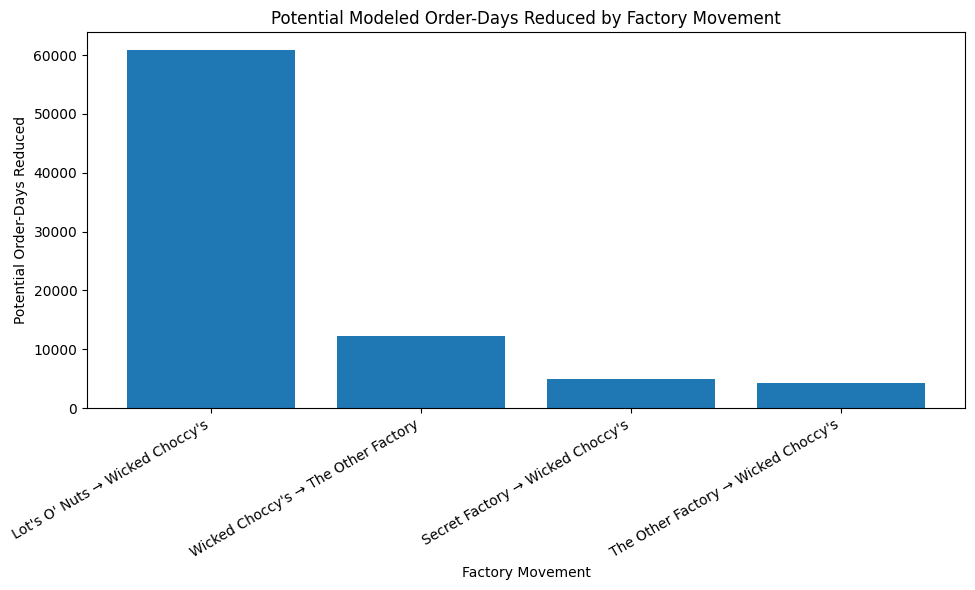

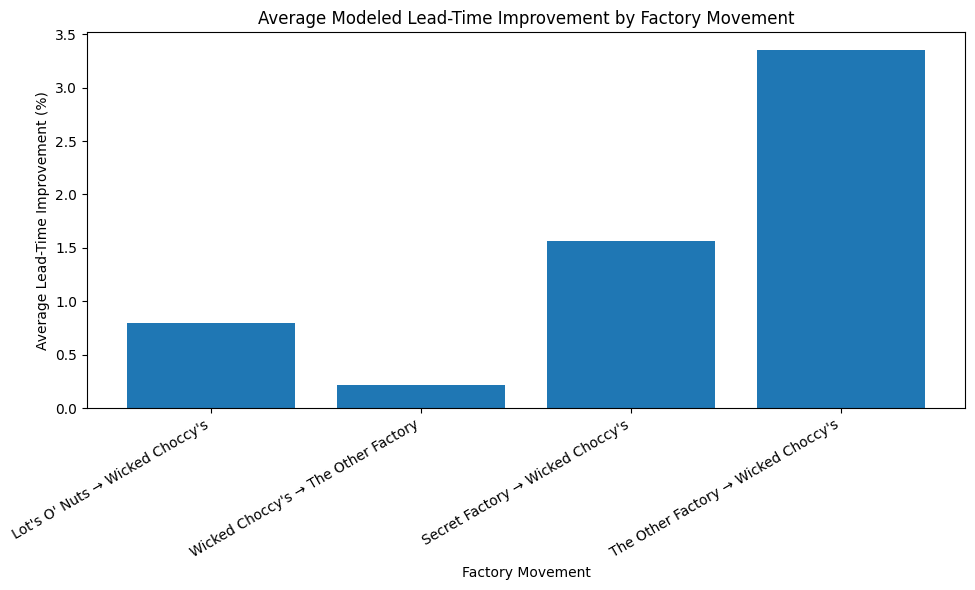

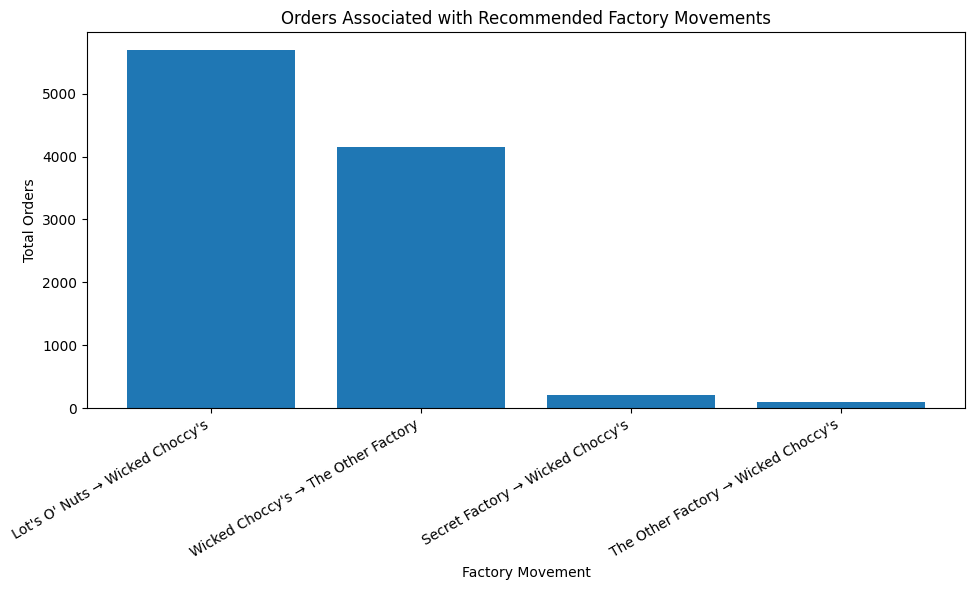

In [267]:
import matplotlib.pyplot as plt

# Make a copy so we do not accidentally modify the main dataframe
chart_df = factory_move_summary.copy()

# Create readable labels
chart_df["Movement"] = (
    chart_df["Current_Factory"]
    + " → "
    + chart_df["Alternative_Factory"]
)

# -----------------------------------------
# Chart 1: Potential Order-Days Reduced
# -----------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    chart_df["Movement"],
    chart_df["Total_Potential_Order_Days_Reduced"]
)

plt.title("Potential Modeled Order-Days Reduced by Factory Movement")
plt.xlabel("Factory Movement")
plt.ylabel("Potential Order-Days Reduced")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


# -----------------------------------------
# Chart 2: Average Lead-Time Improvement
# -----------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    chart_df["Movement"],
    chart_df["Average_Lead_Time_Improvement_Pct"]
)

plt.title("Average Modeled Lead-Time Improvement by Factory Movement")
plt.xlabel("Factory Movement")
plt.ylabel("Average Lead-Time Improvement (%)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


# -----------------------------------------
# Chart 3: Orders by Factory Movement
# -----------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    chart_df["Movement"],
    chart_df["Total_Orders"]
)

plt.title("Orders Associated with Recommended Factory Movements")
plt.xlabel("Factory Movement")
plt.ylabel("Total Orders")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

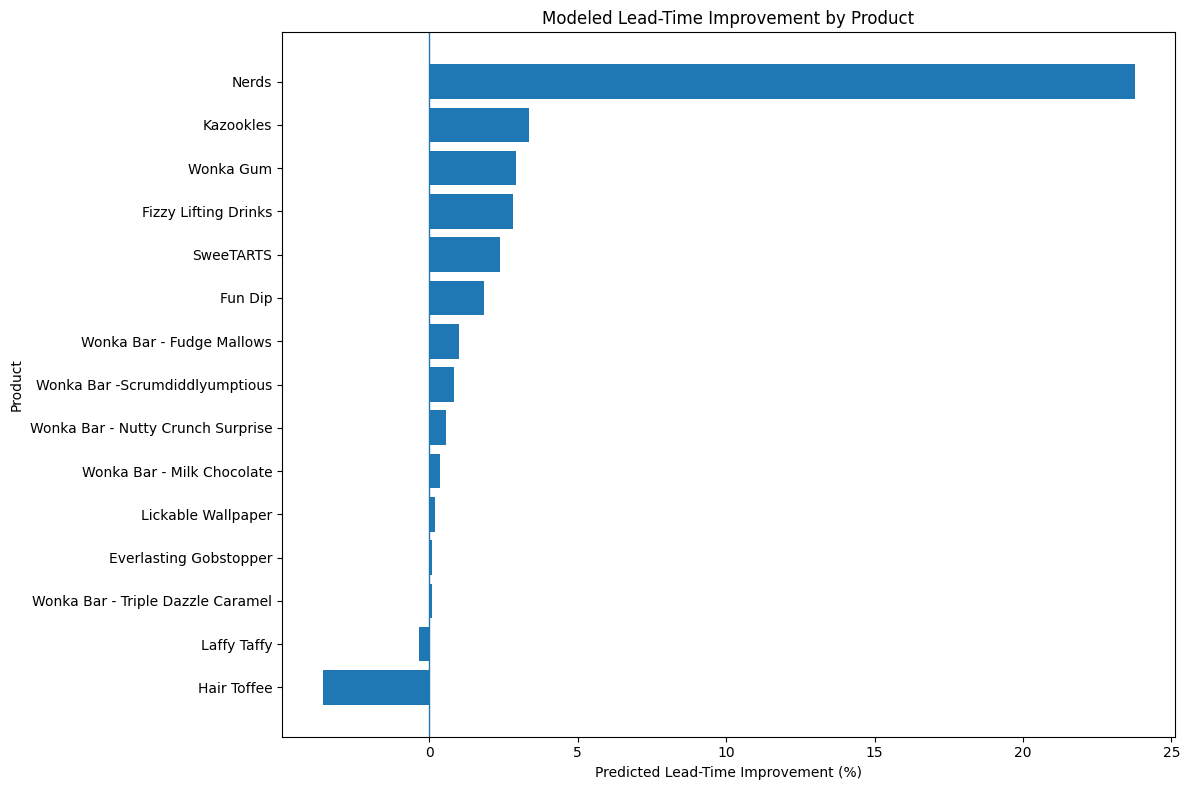

In [268]:
import matplotlib.pyplot as plt

# Make a copy for visualization
recommendation_chart = final_recommendations.copy()

# Sort by modeled lead-time improvement
recommendation_chart = recommendation_chart.sort_values(
    "Lead_Time_Improvement_Pct",
    ascending=True
)

# Create readable product labels
plt.figure(figsize=(12, 8))

plt.barh(
    recommendation_chart["Product Name"],
    recommendation_chart["Lead_Time_Improvement_Pct"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title("Modeled Lead-Time Improvement by Product")
plt.xlabel("Predicted Lead-Time Improvement (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [269]:
# Create an executive-friendly recommendation table

executive_summary = final_recommendations[
    [
        "Product Name",
        "Current_Factory",
        "Alternative_Factory",
        "Orders",
        "Average_Lead_Time_Change",
        "Lead_Time_Improvement_Pct",
        "Potential_Total_Order_Days_Reduced",
        "Total_Sales",
        "Total_Profit",
        "Evidence_Level",
        "Final_Recommendation",
        "Priority"
    ]
].copy()

# Rename columns to make them easier for business users to understand
executive_summary = executive_summary.rename(
    columns={
        "Product Name": "Product",
        "Current_Factory": "Current Factory",
        "Alternative_Factory": "Recommended Factory",
        "Orders": "Orders",
        "Average_Lead_Time_Change": "Avg Lead-Time Reduction (Days)",
        "Lead_Time_Improvement_Pct": "Lead-Time Improvement (%)",
        "Potential_Total_Order_Days_Reduced": "Potential Order-Days Reduced",
        "Total_Sales": "Sales",
        "Total_Profit": "Profit",
        "Evidence_Level": "Evidence",
        "Final_Recommendation": "Recommendation",
        "Priority": "Priority"
    }
)

# Sort by recommendation first and priority second
recommendation_order = {
    "MOVE CANDIDATE": 1,
    "VALIDATE FIRST": 2,
    "NO CHANGE": 3
}

executive_summary["Recommendation_Order"] = (
    executive_summary["Recommendation"]
    .map(recommendation_order)
)

executive_summary = executive_summary.sort_values(
    ["Recommendation_Order", "Priority"],
    ascending=[True, True]
).drop(
    columns=["Recommendation_Order"]
).reset_index(drop=True)

# Round numerical columns for readability
executive_summary["Avg Lead-Time Reduction (Days)"] = (
    executive_summary["Avg Lead-Time Reduction (Days)"].round(2)
)

executive_summary["Lead-Time Improvement (%)"] = (
    executive_summary["Lead-Time Improvement (%)"].round(2)
)

executive_summary["Potential Order-Days Reduced"] = (
    executive_summary["Potential Order-Days Reduced"].round(2)
)

executive_summary["Sales"] = (
    executive_summary["Sales"].round(2)
)

executive_summary["Profit"] = (
    executive_summary["Profit"].round(2)
)

print("Executive recommendation table:")
print("Number of products:", len(executive_summary))

display(executive_summary)

Executive recommendation table:
Number of products: 15


,Product,Current Factory,Recommended Factory,Orders,Avg Lead-Time Reduction (Days),Lead-Time Improvement (%),Potential Order-Days Reduced,Sales,Profit,Evidence,Recommendation,Priority
0,Kazookles,The Other Factory,Wicked Choccy's,96,44.86,3.35,4306.18,1205.75,92.75,MEDIUM EVIDENCE,MOVE CANDIDATE,1
1,Wonka Gum,Secret Factory,Wicked Choccy's,120,39.00,2.92,4680.59,597.50,310.70,HIGHER EVIDENCE,MOVE CANDIDATE,1
2,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,1818,13.31,1.00,24193.03,24890.40,16593.60,HIGHER EVIDENCE,MOVE CANDIDATE,1
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,2064,11.24,0.84,23197.78,27874.80,19357.50,HIGHER EVIDENCE,MOVE CANDIDATE,1
4,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,1810,7.42,0.56,13433.92,23574.95,16819.95,HIGHER EVIDENCE,MOVE CANDIDATE,1
5,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,2137,4.60,0.35,9827.23,26867.75,17443.37,HIGHER EVIDENCE,MOVE CANDIDATE,1
6,Lickable Wallpaper,Secret Factory,Wicked Choccy's,94,2.67,0.20,250.73,7860.00,3930.00,MEDIUM EVIDENCE,MOVE CANDIDATE,1
7,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,2015,1.18,0.09,2374.52,28485.00,18610.20,HIGHER EVIDENCE,MOVE CANDIDATE,1
8,Nerds,Sugar Shack,The Other Factory,4,319.98,23.76,1279.93,15.00,7.00,LOW EVIDENCE,VALIDATE FIRST,2
9,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,6,37.67,2.81,226.00,78.75,47.25,LOW EVIDENCE,VALIDATE FIRST,2


In [270]:
# Step 20: Overall Business Impact

move_candidates = executive_summary[
    executive_summary["Recommendation"] == "MOVE CANDIDATE"
].copy()

validate_first = executive_summary[
    executive_summary["Recommendation"] == "VALIDATE FIRST"
].copy()

no_change = executive_summary[
    executive_summary["Recommendation"] == "NO CHANGE"
].copy()


# Calculate overall impact
total_products = len(executive_summary)

move_product_count = len(move_candidates)
validate_product_count = len(validate_first)
no_change_product_count = len(no_change)

move_orders = move_candidates["Orders"].sum()

move_potential_days = (
    move_candidates["Potential Order-Days Reduced"].sum()
)

move_sales = move_candidates["Sales"].sum()

move_profit = move_candidates["Profit"].sum()

weighted_avg_improvement = (
    move_candidates["Potential Order-Days Reduced"].sum()
    / move_candidates["Orders"].sum()
)


# Display results
print("========== OVERALL BUSINESS IMPACT ==========")
print()

print("Total products analyzed:", total_products)
print("MOVE CANDIDATE products:", move_product_count)
print("VALIDATE FIRST products:", validate_product_count)
print("NO CHANGE products:", no_change_product_count)

print()
print("MOVE CANDIDATE orders:", int(move_orders))
print(
    "Potential modeled order-days reduced:",
    round(move_potential_days, 2)
)
print(
    "Sales associated with MOVE CANDIDATE products:",
    round(move_sales, 2)
)
print(
    "Profit associated with MOVE CANDIDATE products:",
    round(move_profit, 2)
)
print(
    "Order-weighted average lead-time reduction (days):",
    round(weighted_avg_improvement, 2)
)

========== OVERALL BUSINESS IMPACT ==========

Total products analyzed: 15
MOVE CANDIDATE products: 8
VALIDATE FIRST products: 5
NO CHANGE products: 2

MOVE CANDIDATE orders: 10154
Potential modeled order-days reduced: 82263.98
Sales associated with MOVE CANDIDATE products: 141356.15
Profit associated with MOVE CANDIDATE products: 93158.07
Order-weighted average lead-time reduction (days): 8.1


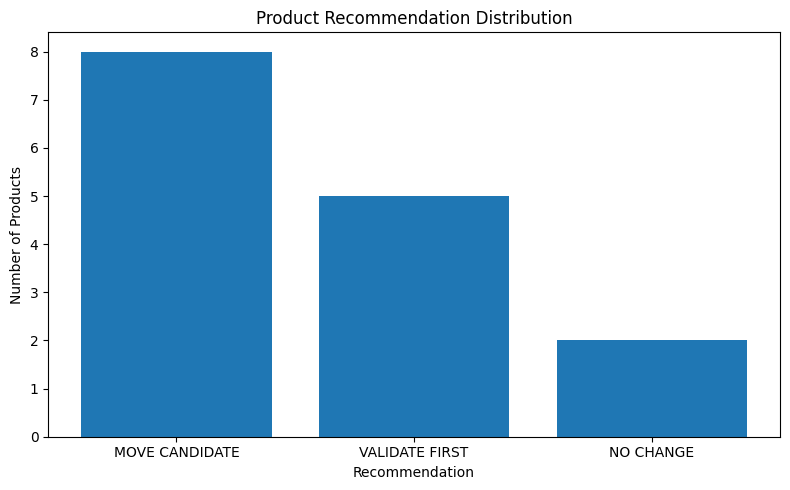

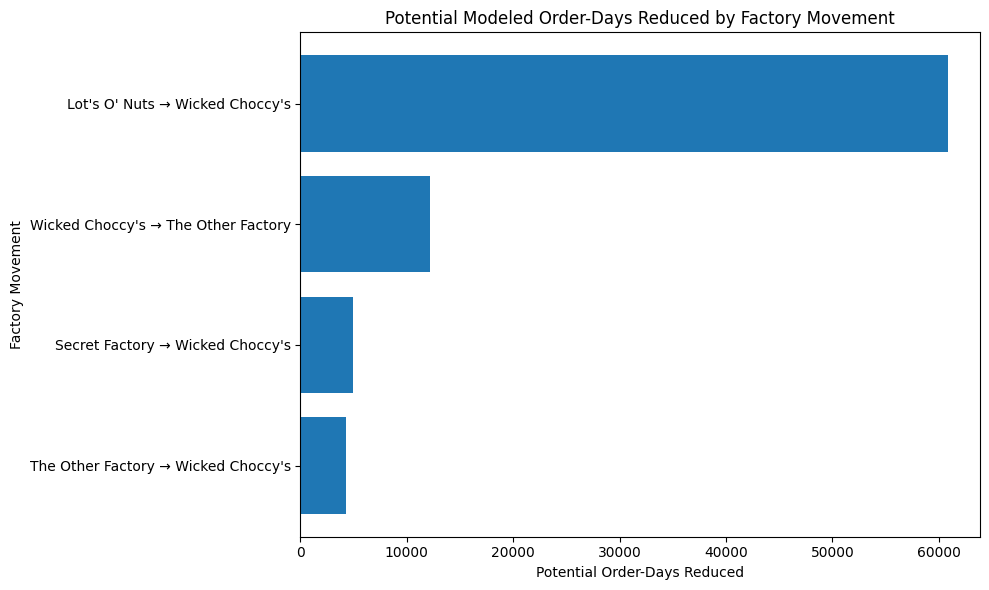

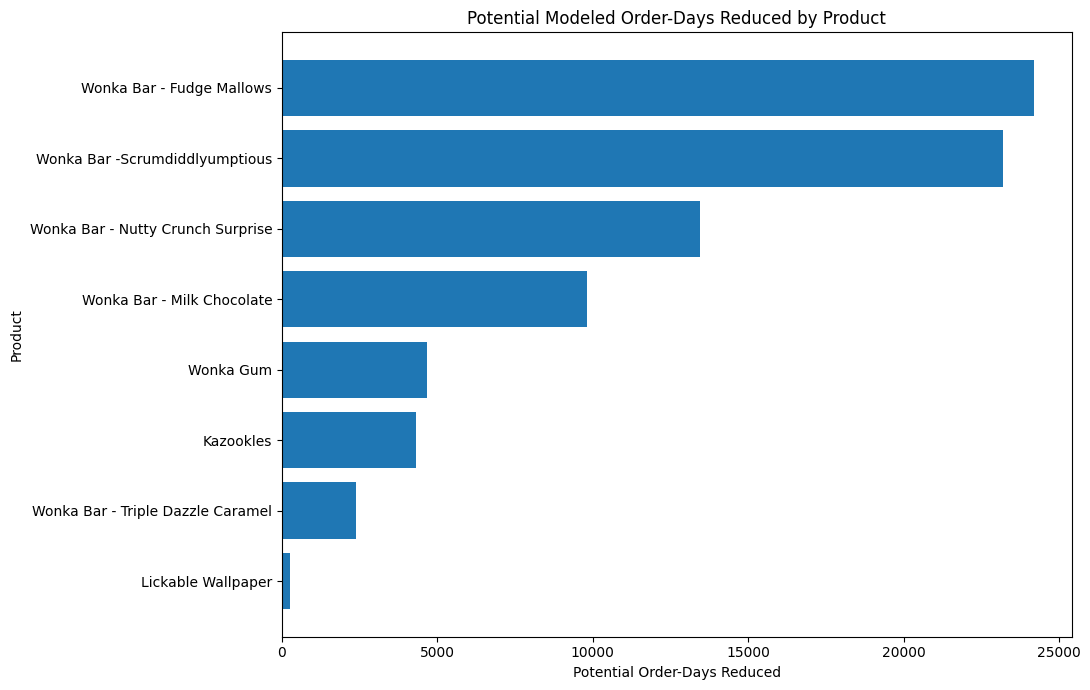

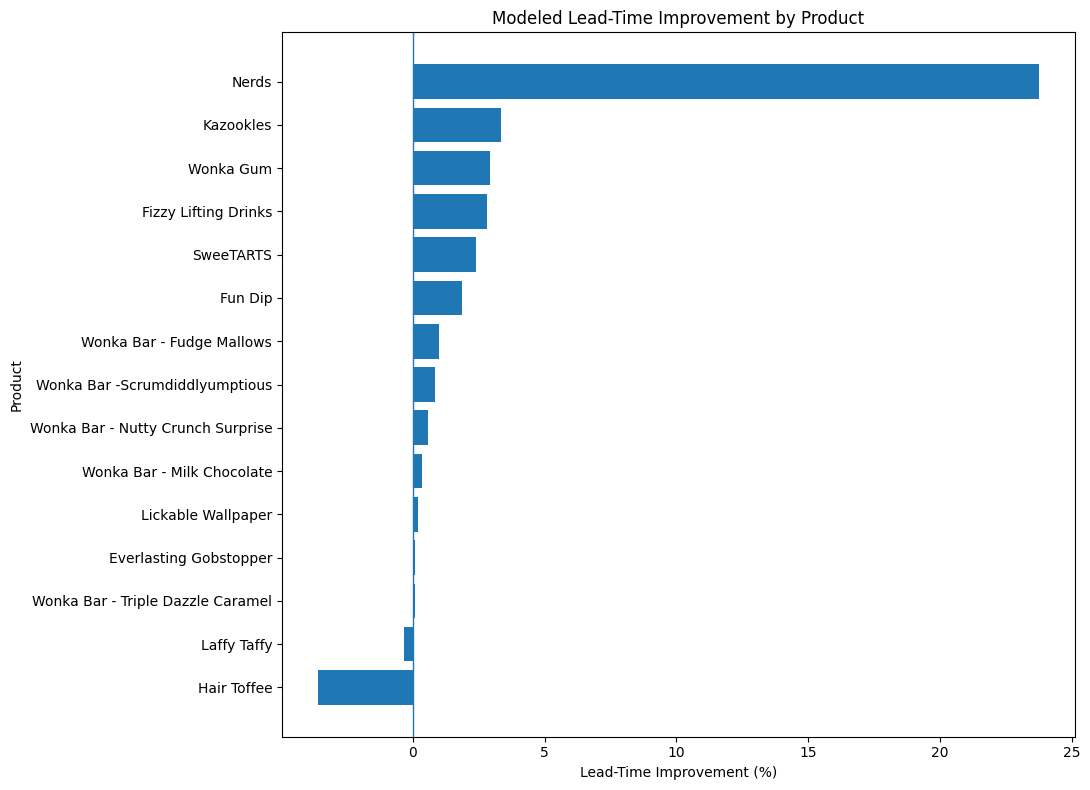

In [271]:
import matplotlib.pyplot as plt

# ============================================================
# STEP 21: EXECUTIVE DASHBOARD VISUALIZATIONS
# ============================================================

# ------------------------------------------------------------
# Chart 1: Recommendation Distribution
# ------------------------------------------------------------

recommendation_counts = (
    executive_summary["Recommendation"]
    .value_counts()
    .reindex(
        ["MOVE CANDIDATE", "VALIDATE FIRST", "NO CHANGE"],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))

plt.bar(
    recommendation_counts.index,
    recommendation_counts.values
)

plt.title("Product Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 2: Factory Movement Opportunities
# ------------------------------------------------------------

movement_chart = factory_move_summary.copy()

movement_chart["Movement"] = (
    movement_chart["Current_Factory"]
    + " → "
    + movement_chart["Alternative_Factory"]
)

movement_chart = movement_chart.sort_values(
    "Total_Potential_Order_Days_Reduced",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    movement_chart["Movement"],
    movement_chart["Total_Potential_Order_Days_Reduced"]
)

plt.title("Potential Modeled Order-Days Reduced by Factory Movement")
plt.xlabel("Potential Order-Days Reduced")
plt.ylabel("Factory Movement")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 3: Product-Level Potential Impact
# ------------------------------------------------------------

product_impact_chart = move_candidates.sort_values(
    "Potential Order-Days Reduced",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    product_impact_chart["Product"],
    product_impact_chart["Potential Order-Days Reduced"]
)

plt.title("Potential Modeled Order-Days Reduced by Product")
plt.xlabel("Potential Order-Days Reduced")
plt.ylabel("Product")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Chart 4: Lead-Time Improvement by Product
# ------------------------------------------------------------

improvement_chart = executive_summary.sort_values(
    "Lead-Time Improvement (%)",
    ascending=True
)

plt.figure(figsize=(11, 8))

plt.barh(
    improvement_chart["Product"],
    improvement_chart["Lead-Time Improvement (%)"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.title("Modeled Lead-Time Improvement by Product")
plt.xlabel("Lead-Time Improvement (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [272]:
# ============================================================
# STEP 22: FINAL KPI SUMMARY
# ============================================================

# Recommendation counts
total_products = len(executive_summary)

move_candidates = executive_summary[
    executive_summary["Recommendation"] == "MOVE CANDIDATE"
]

validate_first = executive_summary[
    executive_summary["Recommendation"] == "VALIDATE FIRST"
]

no_change = executive_summary[
    executive_summary["Recommendation"] == "NO CHANGE"
]


# Core KPIs
total_move_products = len(move_candidates)

total_validate_products = len(validate_first)

total_no_change_products = len(no_change)

total_move_orders = move_candidates["Orders"].sum()

total_potential_days = (
    move_candidates["Potential Order-Days Reduced"].sum()
)

total_move_sales = move_candidates["Sales"].sum()

total_move_profit = move_candidates["Profit"].sum()

weighted_avg_days = (
    total_potential_days / total_move_orders
)


# Factory movement KPIs
number_of_factory_movements = len(factory_move_summary)

largest_factory_opportunity = (
    factory_move_summary.iloc[0]["Current_Factory"]
    + " → "
    + factory_move_summary.iloc[0]["Alternative_Factory"]
)

largest_factory_days = (
    factory_move_summary.iloc[0]["Total_Potential_Order_Days_Reduced"]
)


# ------------------------------------------------------------
# Display KPI Summary
# ------------------------------------------------------------

print("=" * 60)
print("FINAL DECISION-INTELLIGENCE KPI SUMMARY")
print("=" * 60)

print()
print("PRODUCTS ANALYZED")
print("-----------------")
print("Total products:", total_products)
print("Move candidates:", total_move_products)
print("Validate first:", total_validate_products)
print("No change:", total_no_change_products)

print()
print("BUSINESS IMPACT")
print("----------------")
print("Orders covered by move candidates:", int(total_move_orders))
print(
    "Potential modeled order-days reduced:",
    round(total_potential_days, 2)
)
print(
    "Modeled average reduction per order:",
    round(weighted_avg_days, 2),
    "days"
)
print(
    "Associated sales:",
    round(total_move_sales, 2)
)
print(
    "Associated profit:",
    round(total_move_profit, 2)
)

print()
print("FACTORY MOVEMENT")
print("----------------")
print(
    "Recommended movement patterns:",
    number_of_factory_movements
)
print(
    "Largest modeled opportunity:",
    largest_factory_opportunity
)
print(
    "Potential order-days from largest movement:",
    round(largest_factory_days, 2)
)

print()
print("=" * 60)

FINAL DECISION-INTELLIGENCE KPI SUMMARY

PRODUCTS ANALYZED
-----------------
Total products: 15
Move candidates: 8
Validate first: 5
No change: 2

BUSINESS IMPACT
----------------
Orders covered by move candidates: 10154
Potential modeled order-days reduced: 82263.98
Modeled average reduction per order: 8.1 days
Associated sales: 141356.15
Associated profit: 93158.07

FACTORY MOVEMENT
----------------
Recommended movement patterns: 4
Largest modeled opportunity: Lot's O' Nuts → Wicked Choccy's
Potential order-days from largest movement: 60824.73



In [273]:
# ============================================================
# STEP 23: CREATE FINAL RECOMMENDATION EXPORT
# ============================================================

# Create a final business-facing dataframe
final_export = executive_summary.copy()

# Add the factory movement column
final_export["Factory Movement"] = (
    final_export["Current Factory"]
    + " → "
    + final_export["Recommended Factory"]
)

# Reorder columns for easier business interpretation
final_export = final_export[
    [
        "Priority",
        "Recommendation",
        "Evidence",
        "Product",
        "Current Factory",
        "Recommended Factory",
        "Factory Movement",
        "Orders",
        "Avg Lead-Time Reduction (Days)",
        "Lead-Time Improvement (%)",
        "Potential Order-Days Reduced",
        "Sales",
        "Profit"
    ]
]

# Save as CSV
output_file = "Nassau_Candy_Final_Recommendations.csv"

final_export.to_csv(
    output_file,
    index=False
)

print("Final recommendation file created successfully.")
print("File name:", output_file)
print("Rows:", len(final_export))
print("Columns:", len(final_export.columns))

print()
print("Preview:")
display(final_export)

Final recommendation file created successfully.
File name: Nassau_Candy_Final_Recommendations.csv
Rows: 15
Columns: 13

Preview:


,Priority,Recommendation,Evidence,Product,Current Factory,Recommended Factory,Factory Movement,Orders,Avg Lead-Time Reduction (Days),Lead-Time Improvement (%),Potential Order-Days Reduced,Sales,Profit
0,1,MOVE CANDIDATE,MEDIUM EVIDENCE,Kazookles,The Other Factory,Wicked Choccy's,The Other Factory → Wicked Choccy's,96,44.86,3.35,4306.18,1205.75,92.75
1,1,MOVE CANDIDATE,HIGHER EVIDENCE,Wonka Gum,Secret Factory,Wicked Choccy's,Secret Factory → Wicked Choccy's,120,39.00,2.92,4680.59,597.50,310.70
2,1,MOVE CANDIDATE,HIGHER EVIDENCE,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Wicked Choccy's,Lot's O' Nuts → Wicked Choccy's,1818,13.31,1.00,24193.03,24890.40,16593.60
3,1,MOVE CANDIDATE,HIGHER EVIDENCE,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,Lot's O' Nuts → Wicked Choccy's,2064,11.24,0.84,23197.78,27874.80,19357.50
4,1,MOVE CANDIDATE,HIGHER EVIDENCE,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Wicked Choccy's,Lot's O' Nuts → Wicked Choccy's,1810,7.42,0.56,13433.92,23574.95,16819.95
5,1,MOVE CANDIDATE,HIGHER EVIDENCE,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,Wicked Choccy's → The Other Factory,2137,4.60,0.35,9827.23,26867.75,17443.37
6,1,MOVE CANDIDATE,MEDIUM EVIDENCE,Lickable Wallpaper,Secret Factory,Wicked Choccy's,Secret Factory → Wicked Choccy's,94,2.67,0.20,250.73,7860.00,3930.00
7,1,MOVE CANDIDATE,HIGHER EVIDENCE,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,The Other Factory,Wicked Choccy's → The Other Factory,2015,1.18,0.09,2374.52,28485.00,18610.20
8,2,VALIDATE FIRST,LOW EVIDENCE,Nerds,Sugar Shack,The Other Factory,Sugar Shack → The Other Factory,4,319.98,23.76,1279.93,15.00,7.00
9,2,VALIDATE FIRST,LOW EVIDENCE,Fizzy Lifting Drinks,Sugar Shack,Wicked Choccy's,Sugar Shack → Wicked Choccy's,6,37.67,2.81,226.00,78.75,47.25


In [274]:
# ============================================================
# STEP 24: FINAL PROJECT SUMMARY
# ============================================================

print("=" * 80)
print("NASSAU CANDY DISTRIBUTOR")
print("FACTORY REALLOCATION & SHIPPING OPTIMIZATION")
print("FINAL PROJECT SUMMARY")
print("=" * 80)

print()

print("1. BUSINESS OBJECTIVE")
print("---------------------")
print(
    "The objective of this project was to introduce decision intelligence "
    "to the Nassau Candy Distributor analysis by evaluating alternative "
    "factory assignments and identifying potential opportunities to improve "
    "shipping performance while considering profitability and factory distance."
)

print()

print("2. ANALYTICAL APPROACH")
print("-----------------------")
print(
    "The analysis prepared the historical order data, calculated observed "
    "order-to-ship lead times, developed machine-learning models to predict "
    "lead-time outcomes, simulated alternative factory assignments, and "
    "aggregated the scenario results at product and factory-movement levels."
)

print()

print("3. MODELING APPROACH")
print("--------------------")
print(
    "Gradient Boosting was selected as the scenario model because it provided "
    "the strongest R² among the tested models. However, its R² was approximately "
    "0.042, meaning the model explains only a small portion of the observed "
    "variation in lead time."
)

print()

print("4. KEY FINDINGS")
print("---------------")
print(f"Products analyzed: {total_products}")
print(f"Move candidates: {total_move_products}")
print(f"Validate first: {total_validate_products}")
print(f"No change: {total_no_change_products}")
print(f"Orders covered by move candidates: {int(total_move_orders)}")
print(
    f"Potential modeled order-days reduced: "
    f"{total_potential_days:,.2f}"
)
print(
    f"Modeled average reduction per order: "
    f"{weighted_avg_days:.2f} days"
)
print(
    f"Sales associated with move candidates: "
    f"{total_move_sales:,.2f}"
)
print(
    f"Profit associated with move candidates: "
    f"{total_move_profit:,.2f}"
)

print()

print("5. FACTORY MOVEMENT FINDINGS")
print("----------------------------")
print(
    f"The analysis identified {number_of_factory_movements} "
    f"factory-to-factory movement patterns among the MOVE CANDIDATE products."
)

print(
    f"The largest modeled opportunity was "
    f"{largest_factory_opportunity}, "
    f"with approximately {largest_factory_days:,.2f} "
    f"potential modeled order-days reduced."
)

print()

print("6. DECISION FRAMEWORK")
print("---------------------")
print(
    "Recommendations were classified using modeled lead-time improvement "
    "and an evidence safeguard based on the number of observed orders. "
    "Products with positive modeled improvement but limited order evidence "
    "were classified as VALIDATE FIRST rather than immediate MOVE CANDIDATES."
)

print()

print("7. BUSINESS INTERPRETATION")
print("--------------------------")
print(
    "The analysis identifies specific product and factory combinations "
    "that can be investigated as potential reassignment opportunities. "
    "The results provide a structured way for leadership to prioritize "
    "which scenarios should receive further operational investigation."
)

print()

print("8. IMPORTANT MODEL LIMITATION")
print("-----------------------------")
print(
    "The scenario results should be treated as model-generated screening "
    "opportunities rather than guaranteed operational outcomes. The relatively "
    "low predictive R² indicates that additional operational variables or "
    "better historical data may be needed before using the model for automated "
    "factory-allocation decisions."
)

print()

print("9. FINAL RECOMMENDATION")
print("-----------------------")
print(
    "Use the identified MOVE CANDIDATES as a shortlist for operational "
    "validation. Investigate VALIDATE FIRST products separately because "
    "their observed order volumes are limited. Products classified as "
    "NO CHANGE should not be prioritized for reassignment under the current "
    "scenario assumptions."
)

print()

print("=" * 80)
print("END OF PROJECT SUMMARY")
print("=" * 80)

NASSAU CANDY DISTRIBUTOR
FACTORY REALLOCATION & SHIPPING OPTIMIZATION
FINAL PROJECT SUMMARY

1. BUSINESS OBJECTIVE
---------------------
The objective of this project was to introduce decision intelligence to the Nassau Candy Distributor analysis by evaluating alternative factory assignments and identifying potential opportunities to improve shipping performance while considering profitability and factory distance.

2. ANALYTICAL APPROACH
-----------------------
The analysis prepared the historical order data, calculated observed order-to-ship lead times, developed machine-learning models to predict lead-time outcomes, simulated alternative factory assignments, and aggregated the scenario results at product and factory-movement levels.

3. MODELING APPROACH
--------------------
Gradient Boosting was selected as the scenario model because it provided the strongest R² among the tested models. However, its R² was approximately 0.042, meaning the model explains only a small portion of the 

In [275]:
# ============================================================
# STEP 25: FINAL PROJECT README / METHODOLOGY SUMMARY
# ============================================================

readme_text = f"""
# Factory Reallocation & Shipping Optimization Recommendation System
## Nassau Candy Distributor

---

## 1. Project Overview

This project develops a decision-intelligence framework for the Nassau Candy
Distributor dataset.

The central business question is:

> What should we change to improve performance?

The system evaluates alternative factory assignments and identifies products
that may represent opportunities for factory reassignment based on modeled
lead-time improvement, profitability, factory distance, and available order
evidence.

---

## 2. Business Objectives

The project was designed to:

- Predict shipping outcomes under different factory configurations.
- Identify products that could potentially benefit from reassignment to
  alternative factories.
- Compare current and alternative factory scenarios.
- Balance shipping efficiency with profitability and factory distance.
- Provide a structured recommendation framework for management decision-making.

---

## 3. Dataset

The analysis used the Nassau Candy Distributor historical order dataset.

The dataset contained:

- 10,194 order-line records
- 18 original variables
- 15 unique products
- 5 factories defined in the project scenario framework

Important fields included:

- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Region
- Division
- Product ID
- Product Name
- Sales
- Units
- Gross Profit
- Cost

---

## 4. Data Preparation

The following preparation steps were performed:

1. Loaded the Nassau Candy Distributor CSV dataset.
2. Examined the dataset structure and data types.
3. Parsed Order Date and Ship Date using the observed day-month-year format.
4. Calculated observed order-to-ship elapsed time.
5. Created month, quarter, and day-of-week features.
6. Added factory information from the project scenario framework.
7. Created factory-to-factory distance information using the provided
   factory locations and Haversine distance calculations.

The observed order-to-ship elapsed times were unusually long. Therefore,
the metric was retained and described as observed order-to-ship lead time
rather than conventional transportation transit time.

---

## 5. Machine Learning

Three regression approaches were evaluated:

- Linear Regression
- Random Forest
- Gradient Boosting

Gradient Boosting was selected for scenario simulation because it produced
the strongest predictive performance among the tested models.

The Gradient Boosting model produced approximately:

- MAE: 214.61 days
- RMSE: 260.27 days
- R²: 0.042

The relatively low R² is an important limitation.

The model explains only a small portion of the observed variation in
lead time. Therefore, the scenario results should be interpreted as
screening opportunities rather than guaranteed operational outcomes.

---

## 6. Scenario Simulation

For every observed dataset row, alternative factory assignments were
simulated.

The scenario framework excluded the current factory from the alternatives.

This resulted in:

10,194 original rows × 4 alternative factories
= 40,776 scenario rows.

For each scenario, the model predicted:

- Current-factory lead time
- Alternative-factory lead time
- Predicted lead-time change
- Predicted improvement percentage

The scenario comparison was calculated as:

Predicted Lead-Time Change =
Predicted Current Lead Time -
Predicted Alternative Lead Time

A positive value therefore represents a modeled reduction in lead time.

---

## 7. Product-Level Analysis

Scenario results were aggregated by:

- Product
- Current Factory
- Alternative Factory

The analysis calculated:

- Number of observed orders
- Average current predicted lead time
- Average alternative predicted lead time
- Average lead-time change
- Lead-time improvement percentage
- Total sales
- Total profit
- Factory distance

The product-level analysis generated 60 observed
product/current-factory/alternative-factory scenario combinations.

---

## 8. Decision Scoring

A business-oriented optimization score was created using:

- 50% Lead-Time Score
- 30% Profit Score
- 20% Distance Score

The score was designed to organize the scenario opportunities while
considering both operational efficiency and business factors.

These weights are business assumptions and should be revisited with
actual stakeholder input before operational deployment.

---

## 9. Evidence Safeguard

To avoid treating small samples as strong operational evidence, the
recommendation framework included an order-volume safeguard.

Products were classified using:

- 100+ orders: HIGHER EVIDENCE
- 30–99 orders: MEDIUM EVIDENCE
- Below 30 orders: LOW EVIDENCE

Positive scenarios with fewer than 30 observed orders were classified as
VALIDATE FIRST rather than immediate MOVE CANDIDATES.

The 30-order threshold is a pragmatic project safeguard, not a statistically
validated cutoff.

---

## 10. Final Recommendations

The final framework analyzed 15 products:

- 8 MOVE CANDIDATE
- 5 VALIDATE FIRST
- 2 NO CHANGE

The MOVE CANDIDATE products covered:

- 10,154 orders
- 82,263.98 potential modeled order-days reduced
- 141,356.15 associated sales
- 93,158.07 associated profit

The order-weighted modeled reduction was approximately:

8.10 days per order.

These values represent model-generated scenario estimates and should not
be interpreted as guaranteed operational savings.

---

## 11. Factory Movement Findings

The analysis identified 4 factory-to-factory movement patterns among the
MOVE CANDIDATE products.

The largest modeled opportunity was:

Lot's O' Nuts → Wicked Choccy's

This movement involved 3 products and represented approximately:

60,824.73 potential modeled order-days reduced.

Other identified movement patterns included:

- Wicked Choccy's → The Other Factory
- Secret Factory → Wicked Choccy's
- The Other Factory → Wicked Choccy's

---

## 12. Recommendation Categories

### MOVE CANDIDATE

Products with positive modeled lead-time improvement and sufficient
observed order evidence under the project's decision rules.

These should be considered for operational validation and further analysis.

### VALIDATE FIRST

Products with positive modeled improvement but limited observed order
evidence.

These should be investigated and validated before operational
reassignment.

### NO CHANGE

Products for which the selected alternative did not produce a positive
modeled lead-time improvement.

---

## 13. Key Business Insight

The analysis demonstrates how historical operational data can be converted
into a decision-support framework.

Instead of asking only:

> What happened?

the system addresses:

> What could happen if we change the factory assignment?

The scenario framework therefore moves the analysis from descriptive
reporting toward decision intelligence.

---

## 14. Important Limitations

Several limitations should be considered before operational deployment:

1. The Gradient Boosting model has relatively low predictive power
   (R² approximately 0.042).

2. Factory reassignment scenarios are model-based counterfactuals and
   should not be interpreted as causal estimates.

3. The observed order-to-ship lead times are unusually long and should
   not automatically be interpreted as standard transportation transit
   times.

4. Factory distance is used as a scenario/business feature and does not
   establish that distance causes the observed lead-time differences.

5. The optimization weights are assumptions created for this project.

6. The 30-order evidence threshold is a practical safeguard rather than
   a statistically validated threshold.

7. Potential order-days reduced are not equivalent to guaranteed savings,
   cost reductions, or realized operational improvements.

---

## 15. Recommended Next Steps

Before using the framework for real operational decisions, the following
improvements are recommended:

- Add additional operational variables that influence shipping performance.
- Include actual factory capacity and production constraints.
- Include inventory availability.
- Include transportation cost.
- Include shipping carrier information.
- Include actual transportation distance and route information where available.
- Validate predicted scenarios against historical operational outcomes.
- Test recommendations through controlled operational pilots.
- Recalibrate the model as new operational data becomes available.
- Review the scoring weights with business stakeholders.

---

## 16. Final Project Outcome

The project produced a complete decision-intelligence workflow:

Raw Data
    ↓
Data Preparation
    ↓
Lead-Time Analysis
    ↓
Machine Learning
    ↓
Alternative Factory Scenario Simulation
    ↓
Product-Level Evaluation
    ↓
Business Scoring
    ↓
Evidence Safeguards
    ↓
Factory Movement Recommendations
    ↓
Business Impact Analysis
    ↓
Executive Recommendation Export

The final output is a structured recommendation system that helps identify
which factory reassignment scenarios deserve further operational attention.

---

## 17. Final Deliverable

The final business-facing recommendation dataset was exported as:

Nassau_Candy_Final_Recommendations.csv

This file contains the product-level recommendation results, factory
movements, order volumes, modeled lead-time improvements, potential
order-day impact, sales, profit, evidence level, recommendation category,
and priority.

---

## 18. Executive Summary

The decision-intelligence framework analyzed 15 products and identified
8 MOVE CANDIDATES, 5 products requiring VALIDATE FIRST review, and
2 products with NO CHANGE.

The MOVE CANDIDATE group covers 10,154 orders and represents
82,263.98 potential modeled order-days of reduction, with approximately
8.10 modeled days of reduction per order.

Four factory movement patterns were identified, with the largest modeled
opportunity being:

Lot's O' Nuts → Wicked Choccy's

The results should be used as a prioritization and screening framework,
followed by operational validation before implementation.
"""

print(readme_text)


# Factory Reallocation & Shipping Optimization Recommendation System
## Nassau Candy Distributor

---

## 1. Project Overview

This project develops a decision-intelligence framework for the Nassau Candy
Distributor dataset.

The central business question is:

> What should we change to improve performance?

The system evaluates alternative factory assignments and identifies products
that may represent opportunities for factory reassignment based on modeled
lead-time improvement, profitability, factory distance, and available order
evidence.

---

## 2. Business Objectives

The project was designed to:

- Predict shipping outcomes under different factory configurations.
- Identify products that could potentially benefit from reassignment to
  alternative factories.
- Compare current and alternative factory scenarios.
- Balance shipping efficiency with profitability and factory distance.
- Provide a structured recommendation framework for management decision-making.

---

## 3. Dataset